# Base Agrícola EVA-UPRA — Pipeline v5 *shock-aware*

**Qué es este notebook.** Reescritura auditada de `explore_base_agricola_v3`. Mantiene el alcance (Valle del Cauca, 2019-2025)
pero corrige los problemas metodológicos hallados en la auditoría (ver `outputs/reports/`), trata 2020-2021 como
**hipótesis de shock a validar** (no como hecho causal) y valida todo con backtesting temporal estricto.

**Cómo ejecutarlo.** Solo cambie `XLSX_PATH` (o la variable de entorno `AGRI_XLSX`) y, si lo desea, los parámetros de `Config`.
`Kernel > Restart & Run All` reproduce todo, incluidas las pruebas (módulo 16).

**Principios no negociables**
1. Los datos observados no se modifican, no se eliminan años y no se imputan. Toda exclusión queda en `outputs/data_quality/`.
2. Para pronosticar el año *T* solo se usan datos con año ≤ *T − h*. Hay una prueba de invarianza que lo verifica.
3. 2020-2021 se modela como *intervención* (pesos/dummies), nunca se borra.
4. No se afirma causalidad: el dataset solo permite describir un cambio coincidente con 2020-2021.

| # | Módulo | # | Módulo |
|---|---|---|---|
| 1 | Configuración | 9 | Backtesting |
| 2 | Ingesta | 10 | Modelos |
| 3 | Auditoría | 11 | Comparación |
| 4 | Normalización | 12 | Escenarios |
| 5 | Estructura temporal | 13 | Forecast |
| 6 | Diagnóstico del shock | 14 | Sensibilidad |
| 7 | Feature engineering | 15 | Exportación |
| 8 | Baselines | 16 | QA final + Test suite |

In [1]:
!pip install reportlab

In [2]:
# Módulo 1 — Configuración
from __future__ import annotations

import hashlib
import json
import logging
import math
import os
import platform
import re
import sys
import time
import unicodedata
import warnings
from dataclasses import asdict, dataclass, field, replace
from pathlib import Path
from typing import Callable, Optional, Sequence

import numpy as np
import pandas as pd
import matplotlib

if "ipykernel" not in sys.modules:          # fuera de Jupyter no hay backend interactivo
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

XLSX_PATH = r"C:\Users\Usuario\Downloads\20260526_BaseAgricola20192025 (1).xlsx"     # <-- ÚNICO valor a cambiar (o defina AGRI_XLSX). Vacío = búsqueda automática.
XLSX_CANDIDATES = [
    r"C:\Users\Usuario\Downloads\20260526_BaseAgricola20192025 (1).xlsx",
    r"C:\Users\Usuario\Downloads\20260526_BaseAgricola20192025.xlsx",
    "20260526_BaseAgricola20192025.xlsx",
    "../20260526_BaseAgricola20192025.xlsx",
    "/mnt/user-data/uploads/20260526_BaseAgricola20192025.xlsx",
]


@dataclass(frozen=True)
class Config:
    """Parámetros centralizados. Nada más en el notebook está 'hard-coded'."""
    # --- entrada / alcance ---
    xlsx_path: str = XLSX_PATH
    sheet_name: str = "BasePagina"          # nivel Desagregación (clave natural única); BaseSIPRA = mismo dato agregado a Cultivo
    cross_check_sheet: str = "BaseSIPRA"
    department: Optional[str] = "Valle del Cauca"   # None => todo el país
    output_dir: str = "outputs_v5"
    # --- régimen temporal (hipótesis, no hechos) ---
    shock_years: tuple = (2020, 2021)       # hipótesis de shock a validar
    recovery_years: tuple = (2022, 2023)    # fase de recuperación (por convención; ver diagnóstico)
    definition_break_year: int = 2022       # nota de la fuente: transitorios pasan de 'siembras' a 'cosechas efectivas'
    provisional_years: tuple = (2024, 2025) # nota de la fuente: "susceptibles de modificación"
    # --- validación temporal ---
    horizons: tuple = (1, 2)
    min_train_obs: int = 2                  # obs mínimas para emitir pronóstico
    min_obs_trend: int = 3                  # obs mínimas para modelos de tendencia / MASE
    holdout_year: Optional[int] = None      # None => último año observado (fold final reservado)
    selection_margin: float = 0.01          # parsimonia: un modelo complejo debe ganar >1% relativo a naive
    # --- modelos pooled ---
    min_stratum_series: int = 30
    winsor_q: float = 0.05
    ridge_alpha: float = 0.1                        # penalización POR OBSERVACIÓN sobre variables estandarizadas (fija a priori, no ajustada)
    phase_weights_full: tuple = (1.0, 1.0, 1.0)     # (shock, recuperación, post)  -> Modelo A
    phase_weights_interv: tuple = (0.0, 1.0, 1.0)   # Modelo B: shock modelado como intervención (pierde peso en el baseline)
    phase_weights_post: tuple = (0.0, 0.5, 1.0)     # Modelo C: prioridad post-shock
    exclude_definition_break: bool = True           # transitorios 2021->2022 fuera de las estimaciones de crecimiento
    # --- escenarios ---
    stress_mode: str = "worse_of"           # 'replay' | 'quantile' | 'worse_of'
    stress_scale: float = 1.0
    stress_quantile: float = 0.10
    stress_duration: int = 2                # el shock hipotético 2020-21 duró 2 años
    # --- pronóstico central (PARCHE v5.1) ---
    central_model: str = "pool_A_full"      # "auto" = campeón del backtest (hoy: naive = persistencia). Cualquier otro nombre = decisión EXPLÍCITA del usuario; se rotula en tablas y gráficos
    interval_exclude_shock: bool = True     # bandas: excluir del banco de residuos las filas cuyo ORIGEN u OBJETIVO cae en la ventana de shock (2020-21)
    # --- incertidumbre ---
    pi_levels: tuple = (0.80, 0.95)
    n_boot: int = 500
    seed: int = 20260923
    # --- calidad de datos ---
    max_quarantine_share: float = 0.01      # si más del 1% de las filas es inválido, el pipeline se detiene
    frozen_run_min: int = 3                 # >=3 años consecutivos idénticos => 'valor congelado'
    intensity_tol: float = 0.10             # |log-cambio| <= 10% se considera "sin efecto" al clasificar patrones de shock

    def resolved_xlsx(self) -> Path:
        cands = [self.xlsx_path] if self.xlsx_path else XLSX_CANDIDATES
        for c in cands:
            if c and Path(c).exists():
                return Path(c)
        raise FileNotFoundError(f"No se encontró el Excel. Probado: {cands}. Defina XLSX_PATH o AGRI_XLSX.")


CFG = Config()
OUT_SUBDIRS = ["data_quality", "diagnostics", "temporal", "forecasting", "scenarios", "models", "reports", "logs"]


def make_output_dirs(cfg: Config) -> dict[str, Path]:
    root = Path(cfg.output_dir)
    dirs = {"root": root}
    for s in OUT_SUBDIRS:
        dirs[s] = root / s
        dirs[s].mkdir(parents=True, exist_ok=True)
    return dirs


OUT = make_output_dirs(CFG)


def get_logger(cfg: Config, name: str = "agri_v5") -> logging.Logger:
    lg = logging.getLogger(name)
    lg.handlers.clear()
    lg.setLevel(logging.INFO)
    fmt = logging.Formatter("%(asctime)s | %(levelname)-7s | %(message)s", "%H:%M:%S")
    fh = logging.FileHandler(Path(cfg.output_dir) / "logs" / "pipeline.log", mode="w", encoding="utf-8")
    sh = logging.StreamHandler(sys.stdout)
    for h in (fh, sh):
        h.setFormatter(fmt)
        lg.addHandler(h)
    lg.propagate = False
    return lg


LOG = get_logger(CFG)
RNG_SEED = CFG.seed
LOG.info("Config cargada | dpto=%s | shock=%s | horizontes=%s", CFG.department, CFG.shock_years, CFG.horizons)


class DataValidationError(ValueError):
    """Fallo controlado y explicable de validación (lleva un código estable)."""
    def __init__(self, code: str, message: str):
        super().__init__(f"[{code}] {message}")
        self.code = code


def save_table(df: pd.DataFrame, subdir: str, name: str, index: bool = False) -> Path:
    p = OUT[subdir] / name
    df.to_csv(p, index=index, encoding="utf-8-sig")
    return p

17:31:03 | INFO    | Config cargada | dpto=Valle del Cauca | shock=(2020, 2021) | horizontes=(1, 2)


In [3]:
# Módulo 2 — Ingesta
def normalize_text(s) -> str:
    """'Producción (t)' -> 'produccion (t)'. Minúsculas, sin tildes, espacios colapsados."""
    s = unicodedata.normalize("NFD", str(s))
    s = "".join(c for c in s if unicodedata.category(c) != "Mn").lower()
    return re.sub(r"\s+", " ", s).strip()


# nombre canónico -> nombres normalizados aceptados (COINCIDENCIA EXACTA, sin respaldo por subcadena: v3 priorizaba lo exacto pero caía a subcadena en silencio, lo que puede elegir otra columna sin avisar)
CANON_COLUMNS: dict[str, tuple] = {
    "dept_code": ("codigo dane departamento", "codigodepartamento"),
    "dept": ("departamento",),
    "muni_code": ("codigo dane municipio", "codigomunicipio"),
    "muni": ("municipio",),
    "crop_disagg": ("desagregacion cultivo",),
    "crop": ("cultivo",),
    "cycle": ("ciclo del cultivo", "nombre_tipo_ciclo"),
    "group": ("grupo cultivo", "grupo_especie"),
    "subgroup": ("subgrupo", "subgrupo_especie"),
    "year": ("ano", "anho"),
    "period": ("periodo",),
    "area_sown": ("area sembrada (ha)", "areasembrada"),
    "area_harv": ("area cosechada (ha)", "areacosechada"),
    "prod": ("produccion (t)", "produccio"),
    "yield": ("rendimiento (t/ha)", "rendimiento"),
    "sci_name": ("nombre cientifico del cultivo", "nombre_cientifico"),
    "crop_code": ("codigo del cultivo", "cod_cultiv"),
    "phys_state": ("estado fisico del cultivo", "estadofisicoproduccio"),
}
REQUIRED_COLS = ["dept", "muni_code", "muni", "crop_disagg", "crop", "cycle", "group", "year", "period", "area_harv", "prod"]
NUMERIC_COLS = ["year", "area_sown", "area_harv", "prod", "yield"]


def resolve_columns(columns: Sequence) -> dict[str, str]:
    """Mapea nombres canónicos -> nombre real. Falla con lista clara si falta una columna requerida o hay ambigüedad."""
    norm = {c: normalize_text(c) for c in columns}
    out: dict[str, str] = {}
    for canon, aliases in CANON_COLUMNS.items():
        hits = [c for c, n in norm.items() if n in aliases]
        if len(hits) > 1:
            raise DataValidationError("AMBIGUOUS_COLUMN", f"'{canon}' coincide con varias columnas: {hits}")
        if hits:
            out[canon] = hits[0]
    missing = [c for c in REQUIRED_COLS if c not in out]
    if missing:
        raise DataValidationError("MISSING_COLUMNS", f"Faltan columnas requeridas {missing}. Disponibles: {list(columns)}")
    return out


def find_header_row(raw: pd.DataFrame, max_scan: int = 40) -> int:
    """Localiza la fila de encabezado buscando la que contiene 'Departamento' y 'Municipio' (no asume la fila 8)."""
    for i in range(min(max_scan, len(raw))):
        vals = {normalize_text(v) for v in raw.iloc[i].tolist() if pd.notna(v)}
        if {"departamento", "municipio"} <= vals:
            return i
    raise DataValidationError("NO_HEADER", f"No se halló fila de encabezado en las primeras {max_scan} filas.")


def file_sha256(path: Path, chunk: int = 1 << 20) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while blk := f.read(chunk):
            h.update(blk)
    return h.hexdigest()


def load_sheet_raw(xf: pd.ExcelFile, sheet: str) -> tuple[pd.DataFrame, list[str], int]:
    """Lee una hoja SIN asumir encabezado. Devuelve (tabla con encabezado real, notas de la fuente, fila de encabezado)."""
    raw = xf.parse(sheet, header=None, dtype=object)
    hdr = find_header_row(raw)
    notes = [str(v).strip() for v in raw.iloc[:hdr].to_numpy().ravel() if pd.notna(v) and str(v).strip()]
    df = raw.iloc[hdr + 1:].copy()
    df.columns = [str(c).strip() for c in raw.iloc[hdr].tolist()]
    df = df.dropna(axis=1, how="all").reset_index(drop=True)
    return df, notes, hdr


def standardize(df_raw: pd.DataFrame) -> tuple[pd.DataFrame, dict, dict]:
    """Renombra a nombres canónicos y tipa. Devuelve (df, colmap, coerced): coerced = celdas que NO pudieron convertirse a número."""
    cmap = resolve_columns(df_raw.columns)
    df = df_raw[[cmap[k] for k in cmap]].copy()
    df.columns = list(cmap.keys())
    coerced = {}
    for c in [c for c in NUMERIC_COLS if c in df.columns]:
        before = df[c].notna().sum()
        df[c] = pd.to_numeric(df[c], errors="coerce")
        coerced[c] = int(before - df[c].notna().sum())
    for c in [c for c in df.columns if c not in NUMERIC_COLS]:
        df[c] = df[c].astype("string").str.strip()
    # códigos DANE como texto con ceros a la izquierda (v3 los leía como enteros: '05001' -> 5001)
    if "muni_code" in df:
        df["muni_code"] = df["muni_code"].str.replace(r"\.0$", "", regex=True).str.zfill(5)
    if "dept_code" in df:
        df["dept_code"] = df["dept_code"].str.replace(r"\.0$", "", regex=True).str.zfill(2)
    return df, cmap, coerced


def filter_scope(df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    if cfg.department is None:
        return df.copy()
    m = df["dept"].map(normalize_text) == normalize_text(cfg.department)
    if not m.any():
        raise DataValidationError("EMPTY_SCOPE", f"Departamento '{cfg.department}' no existe. Hay: {sorted(df['dept'].dropna().unique())[:40]}")
    return df[m].copy()


T0 = time.time()
XLSX = CFG.resolved_xlsx()
SRC_SHA256 = file_sha256(XLSX)
XF = pd.ExcelFile(XLSX)
SHEET_NAMES = XF.sheet_names
RAW_ALL_NATIVE, SOURCE_NOTES, HEADER_ROW = load_sheet_raw(XF, CFG.sheet_name)
RAW_ALL, COLMAP, COERCED = standardize(RAW_ALL_NATIVE)
RAW = filter_scope(RAW_ALL, CFG).reset_index(drop=True)      # 'RAW' NUNCA se modifica más adelante
RAW_FROZEN = RAW.copy(deep=True)                              # copia de control para la prueba de preservación
LOG.info("Excel: %s | sha256=%s…", XLSX.name, SRC_SHA256[:12])
LOG.info("Hoja %s: fila de encabezado=%d | filas país=%d | filas alcance=%d | %.1fs", CFG.sheet_name, HEADER_ROW, len(RAW_ALL), len(RAW), time.time() - T0)
LOG.info("Notas de la fuente detectadas: %d", len(SOURCE_NOTES))
(OUT["data_quality"] / "source_notes.txt").write_text("\n".join(SOURCE_NOTES), encoding="utf-8")

17:31:50 | INFO    | Excel: 20260526_BaseAgricola20192025 (1).xlsx | sha256=355e70a7a5b8…
17:31:50 | INFO    | Hoja BasePagina: fila de encabezado=8 | filas país=166733 | filas alcance=10589 | 46.7s
17:31:50 | INFO    | Notas de la fuente detectadas: 7


1035

## Módulo 3 — Auditoría de datos (Fase 0/1)
Inventario de hojas, perfil de columnas y batería de chequeos. **Ningún chequeo modifica los datos**: solo mide y clasifica
(`severidad` y `acción`). Lo inválido (negativos, periodos imposibles, claves faltantes) se pone en *cuarentena* explícita en el módulo 4.

In [4]:
# Módulo 3 — Auditoría
PERIOD_RE = re.compile(r"^(\d{4})([AB])?$")


def parse_period(p) -> tuple[Optional[int], Optional[str]]:
    """'2021B' -> (2021, 'B'); '2021' -> (2021, None); inválido -> (None, 'INVALID')."""
    m = PERIOD_RE.match(str(p).strip()) if pd.notna(p) else None
    return (int(m.group(1)), m.group(2)) if m else (None, "INVALID")


def sheet_inventory(xf: pd.ExcelFile, cfg: Config) -> pd.DataFrame:
    rows = []
    for sh in xf.sheet_names:
        raw = xf.parse(sh, header=None, dtype=object)
        try:
            h = find_header_row(raw)
        except DataValidationError:
            h = 0        # BaseSIPRA trae el encabezado en la fila 0
        rows.append({"hoja": sh, "filas_totales": len(raw), "columnas": raw.shape[1], "fila_encabezado": h,
                     "filas_de_datos": len(raw) - h - 1, "columnas_encabezado": " | ".join(map(str, raw.iloc[h].dropna().tolist()))})
    return pd.DataFrame(rows)


def cross_check_sheets(xf: pd.ExcelFile, raw_scope: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    """BaseSIPRA vs BasePagina: la primera debería ser la segunda agregada a nivel Cultivo. Se verifica, no se asume."""
    if cfg.cross_check_sheet not in xf.sheet_names:
        return pd.DataFrame([{"chequeo": "hoja_cruce", "resultado": "hoja ausente"}])
    b = xf.parse(cfg.cross_check_sheet, header=0)
    ren = {"departamento": "dept", "codigoMunicipio": "muni_code", "especie": "crop", "Periodo": "period",
           "produccio": "prod", "AreaCosechada": "area_harv"}
    b = b.rename(columns=ren)
    b["muni_code"] = b["muni_code"].astype(str).str.zfill(5)
    b["period"] = b["period"].astype(str)
    if cfg.department is not None:
        b = b[b["dept"].astype(str).map(normalize_text) == normalize_text(cfg.department)]
    a = raw_scope.groupby(["muni_code", "crop", "period"], as_index=False)[["prod", "area_harv"]].sum()
    b = b.groupby(["muni_code", "crop", "period"], as_index=False)[["prod", "area_harv"]].sum()
    j = a.merge(b, on=["muni_code", "crop", "period"], how="outer", suffixes=("_pagina", "_sipra"), indicator=True)
    both = j[j["_merge"] == "both"]
    return pd.DataFrame([
        {"chequeo": "combinaciones (muni,cultivo,periodo) BasePagina agregada", "resultado": len(a)},
        {"chequeo": "combinaciones (muni,cultivo,periodo) BaseSIPRA", "resultado": len(b)},
        {"chequeo": "combinaciones solo en una hoja", "resultado": int((j["_merge"] != "both").sum())},
        {"chequeo": "discrepancias de producción (|Δ|>1e-6)", "resultado": int((both["prod_pagina"] - both["prod_sipra"]).abs().gt(1e-6).sum())},
        {"chequeo": "discrepancias de área cosechada (|Δ|>1e-6)", "resultado": int((both["area_harv_pagina"] - both["area_harv_sipra"]).abs().gt(1e-6).sum())},
        {"chequeo": "conclusión", "resultado": "BaseSIPRA == BasePagina agregada a nivel Cultivo" if (j["_merge"] == "both").all()
         and (both["prod_pagina"] - both["prod_sipra"]).abs().le(1e-6).all() else "hojas NO equivalentes: revisar"},
    ])


def column_profile(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for c in df.columns:
        s = df[c]
        r = {"columna": c, "dtype": str(s.dtype), "nulos": int(s.isna().sum()), "unicos": int(s.nunique(dropna=True))}
        if pd.api.types.is_numeric_dtype(s):
            r.update(min=float(s.min()), p50=float(s.median()), p99=float(s.quantile(.99)), max=float(s.max()))
        rows.append(r)
    return pd.DataFrame(rows)


def run_quality_checks(df: pd.DataFrame, coerced: dict, cfg: Config) -> pd.DataFrame:
    """Batería de chequeos. Devuelve tabla con conteo, severidad y acción tomada (sin alterar `df`)."""
    n = len(df)
    yr_p = df["period"].map(lambda p: parse_period(p)[0])
    sfx = df["period"].map(lambda p: parse_period(p)[1])
    key = ["muni_code", "crop_disagg", "period"]
    has_yield = df["area_harv"] > 0
    rc = (df["prod"] / df["area_harv"]).where(has_yield)
    dev = ((rc - df["yield"]).abs() / df["yield"].replace(0, np.nan)).where(has_yield)
    ym = df.assign(fmt=np.where(sfx.isna(), "anual", "sem")).groupby(["muni_code", "crop_disagg", "year"])["fmt"].nunique()
    checks = [
        ("C01", "Periodo con formato inválido", (sfx == "INVALID").sum(), "CRÍTICA", "cuarentena"),
        ("C02", "Año ≠ año embebido en Periodo", ((yr_p != df["year"]) & yr_p.notna()).sum(), "CRÍTICA", "cuarentena"),
        ("C03", "Municipio faltante/vacío", (df["muni"].isna() | (df["muni"].fillna("") == "")).sum(), "CRÍTICA", "cuarentena"),
        ("C04", "Cultivo/desagregación faltante/vacío", (df["crop"].isna() | (df["crop"].fillna("") == "") | df["crop_disagg"].isna()).sum(), "CRÍTICA", "cuarentena"),
        ("C05", "Producción negativa", (df["prod"] < 0).sum(), "CRÍTICA", "cuarentena"),
        ("C06", "Área cosechada negativa", (df["area_harv"] < 0).sum(), "CRÍTICA", "cuarentena"),
        ("C07", "Producción > 0 con área cosechada = 0 (imposible)", ((df["prod"] > 0) & (df["area_harv"] == 0)).sum(), "CRÍTICA", "cuarentena"),
        ("C08", "Celdas numéricas no convertibles", sum(coerced.values()), "ALTA", "coerción a NaN + conteo"),
        ("C09", "Nulos en producción/área cosechada", (df["prod"].isna() | df["area_harv"].isna()).sum(), "ALTA", "cuarentena"),
        ("C10", "Duplicados de clave natural (muni, desagregación, periodo)", df.duplicated(key, keep=False).sum(), "ALTA", "informativo (0 esperado)"),
        ("C11", "Duplicados de clave v3 (muni, CULTIVO, periodo) — la clave que usaba el notebook original", df.duplicated(["muni_code", "crop", "period"], keep=False).sum(), "ALTA", "v5 usa desagregación como clave de serie"),
        ("C12", "Combinaciones (muni,desagregación,año) con formato anual Y semestral a la vez", int((ym > 1).sum()), "MEDIA", "se conserva el semestral; el anual se registra en exclusiones"),
        ("C13", "Área cosechada > área sembrada", (df["area_harv"] > df["area_sown"] + 1e-9).sum(), "BAJA", "informativo (normal en permanentes)"),
        ("C14", "Área cosechada = 0 (siembra sin cosecha)", (df["area_harv"] == 0).sum(), "MEDIA", "ceros estructurales: se conservan; log-modelos los tratan aparte"),
        ("C15", "Rendimiento reportado difiere >5% de Producción/Área", (dev > 0.05).sum(), "MEDIA", "se recalcula rendimiento = P/AC en el panel"),
        ("C16", "Rendimiento reportado con valor entero (baja precisión)", (df["yield"].dropna() % 1 == 0).sum(), "BAJA", "informativo"),
        ("C17", "Texto con espacios sobrantes/mojibake", sum(int((df[c].dropna() != df[c].dropna().str.strip()).sum() + df[c].dropna().str.contains("Ã|�", regex=True).sum())
                                                            for c in ["muni", "crop", "crop_disagg", "group"]), "BAJA", "strip() aplicado"),
        ("C18", "Códigos de municipio con >1 nombre (o viceversa)", int((df.groupby("muni_code")["muni"].nunique() > 1).sum() + (df.groupby("muni")["muni_code"].nunique() > 1).sum()), "ALTA", "informativo (0 esperado)"),
        ("C19", "Desagregaciones asignadas a >1 cultivo", int((df.groupby("crop_disagg")["crop"].nunique() > 1).sum()), "ALTA", "informativo (0 esperado)"),
    ]
    out = pd.DataFrame(checks, columns=["id", "chequeo", "filas_afectadas", "severidad", "accion"])
    out["filas_afectadas"] = out["filas_afectadas"].astype(int)
    out["pct_filas"] = out["filas_afectadas"] / max(n, 1) * 100
    return out


INVENTORY = sheet_inventory(XF, CFG)
CROSS = cross_check_sheets(XF, RAW, CFG)
PROFILE = column_profile(RAW)
QUALITY = run_quality_checks(RAW, COERCED, CFG)
for nm, t in [("sheet_inventory.csv", INVENTORY), ("sheet_crosscheck.csv", CROSS), ("column_profile.csv", PROFILE), ("quality_checks.csv", QUALITY)]:
    save_table(t, "data_quality", nm)
display(INVENTORY) if "display" in globals() else print(INVENTORY)
display(CROSS) if "display" in globals() else print(CROSS)
display(QUALITY) if "display" in globals() else print(QUALITY)

# La nota de la fuente sobre la definición de los transitorios es un hecho del *dato*, no una hipótesis: se verifica que siga presente
NOTE_DEF_BREAK = any("cosechas efectivas" in normalize_text(n) for n in SOURCE_NOTES)
NOTE_PROVISIONAL = any("susceptibles de modificacion" in normalize_text(n) for n in SOURCE_NOTES)
LOG.info("Nota de cambio de definición 2022 (transitorios) presente en la fuente: %s | nota de cifras provisionales: %s", NOTE_DEF_BREAK, NOTE_PROVISIONAL)

         hoja  filas_totales  columnas  fila_encabezado  filas_de_datos                                columnas_encabezado
0  BasePagina         166742        18                8          166733  Código Dane departamento | Departamento | Códi...
1   BaseSIPRA         151313        18                0          151312  codigoDepartamento | departamento | codigoMuni...
                                             chequeo                                         resultado
0  combinaciones (muni,cultivo,periodo) BasePagin...                                              9427
1     combinaciones (muni,cultivo,periodo) BaseSIPRA                                              9427
2                     combinaciones solo en una hoja                                                 0
3             discrepancias de producción (|Δ|>1e-6)                                                 0
4         discrepancias de área cosechada (|Δ|>1e-6)                                                 0
5            

## Módulo 4 — Normalización
* Se tipifican periodos (`2021`, `2021A`, `2021B`), se valida cada fila y lo inválido va a **cuarentena** (`data_quality/quarantine.csv`), nunca se borra en silencio.
* Si una serie-año trae a la vez fila anual y filas semestrales (2 casos en Valle), se conserva el semestral y el anual queda en `exclusions.csv` (regla configurable, reversible).
* La clave de serie es **(municipio, desagregación de cultivo)**: es la clave natural (0 duplicados). v3 agregaba a *Cultivo*, mezclando p. ej. caña de azúcar con caña panelera.
* **No se imputa nada.** Un año sin dato es `NaN`, no `0`.

In [5]:
# Módulo 4 — Normalización
def normalize_records(df: pd.DataFrame, cfg: Config) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Valida y tipifica. Devuelve (tidy, quarantine, exclusions). Lanza DataValidationError si el % inválido supera el umbral."""
    d = df.copy()
    pp = d["period"].map(parse_period)
    d["period_year"] = pp.map(lambda t: t[0])
    d["half"] = pp.map(lambda t: t[1] if t[1] in ("A", "B") else None)
    reasons = pd.Series("", index=d.index, dtype="object")

    def flag(mask, code):
        nonlocal reasons
        reasons = reasons.where(~mask.fillna(False), reasons + code + ";")

    flag(pp.map(lambda t: t[1] == "INVALID"), "PERIODO_INVALIDO")
    flag(d["year"].isna(), "ANIO_NULO")
    flag(d["period_year"].notna() & (d["period_year"] != d["year"]), "ANIO_DISTINTO_PERIODO")
    flag(d["muni"].isna() | (d["muni"].fillna("") == "") | d["muni_code"].isna(), "MUNICIPIO_FALTANTE")
    flag(d["crop"].isna() | (d["crop"].fillna("") == "") | d["crop_disagg"].isna() | (d["crop_disagg"].fillna("") == ""), "CULTIVO_FALTANTE")
    flag(d["prod"].isna() | d["area_harv"].isna(), "VALOR_NULO")
    flag(d["prod"] < 0, "PRODUCCION_NEGATIVA")
    flag(d["area_harv"] < 0, "AREA_NEGATIVA")
    flag((d["prod"] > 0) & (d["area_harv"] == 0), "PROD_POSITIVA_AREA_CERO")
    flag(~np.isfinite(d[["prod", "area_harv"]].astype(float)).all(axis=1), "NO_FINITO")
    bad = reasons != ""
    quarantine = d[bad].assign(motivo=reasons[bad])
    share = bad.mean() if len(d) else 0.0
    if share > cfg.max_quarantine_share:
        raise DataValidationError("QUARANTINE_LIMIT", f"{share:.2%} de filas inválidas (> {cfg.max_quarantine_share:.2%}). Revise data_quality/quarantine.csv")
    d = d[~bad].copy()
    d["year"] = d["year"].astype(int)
    d["period_type"] = np.where(d["half"].isna(), "annual", "semester")

    # formato mixto -> preferir semestral
    g = d.groupby(["muni_code", "crop_disagg", "year"])["period_type"].transform("nunique")
    drop_annual = (g > 1) & (d["period_type"] == "annual")
    exclusions = d[drop_annual].assign(motivo="FORMATO_MIXTO_SE_PREFIERE_SEMESTRAL")
    d = d[~drop_annual].copy()
    d["series_id"] = d["muni_code"] + "|" + d["crop_disagg"]
    return d.reset_index(drop=True), quarantine, exclusions


TIDY, QUARANTINE, EXCLUSIONS = normalize_records(RAW, CFG)
save_table(QUARANTINE, "data_quality", "quarantine.csv")
save_table(EXCLUSIONS, "data_quality", "exclusions.csv")
LOG.info("Normalización: %d filas -> %d tidy | cuarentena=%d | exclusiones(formato mixto)=%d", len(RAW), len(TIDY), len(QUARANTINE), len(EXCLUSIONS))

17:33:56 | INFO    | Normalización: 10589 filas -> 10587 tidy | cuarentena=0 | exclusiones(formato mixto)=2


## Módulo 5 — Estructura temporal
Se construye el **panel anual** (producción, área cosechada, área sembrada) y una **grilla completa serie × año** donde
lo ausente es `NaN`. Se marcan huecos, ingresos/salidas de series, valores congelados (mismo valor ≥3 años seguidos) y años parciales
(transitorios que reportan solo una de las dos temporadas).

17:33:57 | INFO    | Panel anual: 1412 series × 7 años (2019–2025) | celdas observadas=7848 de 9884
Longitud de series (años con dato): {1: 77, 2: 163, 3: 29, 4: 25, 5: 214, 6: 140, 7: 764}
Series con hueco temporal: 34 | con ceros: 79 | todo ceros: 15
Entradas por año: {2019: 982, 2020: 149, 2021: 221, 2022: 22, 2023: 16, 2024: 15, 2025: 7}
Salidas por año: {2019: 33, 2020: 152, 2021: 13, 2022: 24, 2023: 18, 2024: 27, 2025: 1145}
Transiciones con producción EXACTAMENTE igual al año previo (valor congelado), por año: {2020: 18.9, 2021: 11.9, 2022: 14.2, 2023: 27.7, 2024: 31.6, 2025: 34.1}
Series con racha ≥3 años idénticos: 292 de 1412


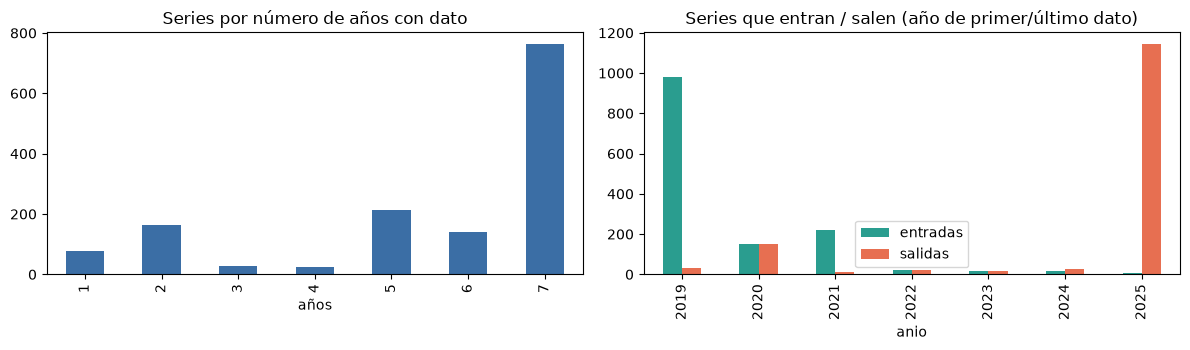

In [6]:
# Módulo 5 — Estructura temporal
def build_annual_panel(tidy: pd.DataFrame) -> pd.DataFrame:
    g = tidy.groupby(["series_id", "year"])
    panel = g.agg(P=("prod", "sum"), AC=("area_harv", "sum"), AS=("area_sown", "sum"), n_rows=("prod", "size"),
                  n_halves=("half", lambda s: s.notna().sum())).reset_index()
    panel["is_semester_reporter"] = panel["n_halves"] > 0
    panel["partial_year"] = panel["is_semester_reporter"] & (panel["n_halves"] < 2)
    return panel


def build_meta(tidy: pd.DataFrame) -> pd.DataFrame:
    cols = ["muni_code", "muni", "crop_disagg", "crop", "cycle", "group", "subgroup"]
    cols = [c for c in cols if c in tidy.columns]
    return tidy.drop_duplicates("series_id").set_index("series_id")[cols].sort_index()


def to_grid(panel: pd.DataFrame, value: str, years: Sequence[int]) -> pd.DataFrame:
    """Grilla serie × año. Los años sin registro son NaN (NO cero)."""
    w = panel.pivot(index="series_id", columns="year", values=value)
    return w.reindex(columns=list(years)).sort_index()


def phase_of_year(y: int, cfg: Config) -> str:
    if y < min(cfg.shock_years):
        return "PRE"
    if y in cfg.shock_years:
        return "SHOCK"
    if y in cfg.recovery_years:
        return "RECOVERY"
    return "POST"


PANEL = build_annual_panel(TIDY)
YEARS = list(range(int(PANEL["year"].min()), int(PANEL["year"].max()) + 1))
META = build_meta(TIDY)
GP = to_grid(PANEL, "P", YEARS)          # producción (t)
GA = to_grid(PANEL, "AC", YEARS)         # área cosechada (ha)
GS = to_grid(PANEL, "AS", YEARS)         # área sembrada (ha)
GPART = to_grid(PANEL.assign(partial_year=PANEL["partial_year"].astype(float)), "partial_year", YEARS)
GY = GP / GA.where(GA > 0)               # rendimiento recalculado = P/AC (NaN si AC=0)
assert GP.index.equals(META.index)
LAST_YEAR = YEARS[-1]
HOLDOUT = CFG.holdout_year or LAST_YEAR
LOG.info("Panel anual: %d series × %d años (%d–%d) | celdas observadas=%d de %d", GP.shape[0], GP.shape[1], YEARS[0], YEARS[-1], int(GP.notna().sum().sum()), GP.size)


def series_status(gp: pd.DataFrame, meta: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    yrs = np.array(gp.columns)
    obs = gp.notna().to_numpy()
    v = gp.to_numpy()
    rows = []
    for i, sid in enumerate(gp.index):
        oy = yrs[obs[i]]
        run_max, run = 0, 0                      # racha máxima de años consecutivos con el MISMO valor > 0 (valores congelados)
        for j in range(1, len(yrs)):
            if obs[i, j] and obs[i, j - 1] and v[i, j] == v[i, j - 1] and v[i, j] > 0:
                run += 1
                run_max = max(run_max, run)
            else:
                run = 0
        rows.append({"series_id": sid, "n_obs": len(oy), "first_year": oy.min() if len(oy) else np.nan, "last_year": oy.max() if len(oy) else np.nan,
                     "has_gap": bool(len(oy) > 1 and (np.diff(oy) > 1).any()), "n_zero": int((v[i][obs[i]] == 0).sum()),
                     "all_zero": bool(len(oy) > 0 and (v[i][obs[i]] == 0).all()), "frozen_run_max_years": run_max + 1 if run_max else 0})
    st = pd.DataFrame(rows).set_index("series_id").join(meta[["cycle", "group", "crop", "muni"]])
    st["entry_after_start"] = st["first_year"] > yrs[0]
    st["exit_before_end"] = st["last_year"] < yrs[-1]
    st["has_frozen_run"] = st["frozen_run_max_years"] >= cfg.frozen_run_min
    def tier(r):
        if r["exit_before_end"]:
            return "sin_pronostico_salio"
        if r["n_obs"] == 1:
            return "T1_un_dato"
        if r["n_obs"] == 2:
            return "T2_dos_datos"
        return "T3_tendencia_ok"
    st["tier"] = st.apply(tier, axis=1)
    return st


STATUS = series_status(GP, META, CFG)
save_table(STATUS.reset_index(), "temporal", "series_status.csv")
len_dist = STATUS["n_obs"].value_counts().sort_index().rename("n_series").reset_index()
save_table(len_dist, "temporal", "series_length_distribution.csv")
entry_exit = pd.DataFrame({"entradas": STATUS["first_year"].value_counts().sort_index(), "salidas": STATUS["last_year"].value_counts().sort_index()}).fillna(0).astype(int)
entry_exit.index.name = "anio"
save_table(entry_exit.reset_index(), "temporal", "entry_exit_by_year.csv")
save_table(pd.DataFrame({"n_series_activas": GP.notna().sum(), "n_parciales": GPART.fillna(0).sum()}).rename_axis("anio").reset_index(), "temporal", "series_active_by_year.csv")
print("Longitud de series (años con dato):", len_dist.set_index("n_obs")["n_series"].to_dict())
print("Series con hueco temporal:", int(STATUS["has_gap"].sum()), "| con ceros:", int((STATUS["n_zero"] > 0).sum()), "| todo ceros:", int(STATUS["all_zero"].sum()))
print("Entradas por año:", entry_exit["entradas"].to_dict())
print("Salidas por año:", entry_exit["salidas"].to_dict())
_tr = pd.DataFrame({y: (GP[y] == GP[y - 1]).where(GP[y].notna() & GP[y - 1].notna()) for y in YEARS[1:]})
print("Transiciones con producción EXACTAMENTE igual al año previo (valor congelado), por año:", (_tr.mean() * 100).round(1).to_dict())
print("Series con racha ≥3 años idénticos:", int(STATUS["has_frozen_run"].sum()), "de", len(STATUS))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
len_dist.plot.bar(x="n_obs", y="n_series", ax=ax[0], legend=False, color="#3b6ea5"); ax[0].set_title("Series por número de años con dato"); ax[0].set_xlabel("años")
entry_exit.plot.bar(ax=ax[1], color=["#2a9d8f", "#e76f51"]); ax[1].set_title("Series que entran / salen (año de primer/último dato)")
plt.tight_layout(); plt.savefig(OUT["temporal"] / "series_structure.png", dpi=130); plt.show()

## Módulo 6 — Diagnóstico del shock 2020-2021 (hipótesis a validar)

**Pregunta.** ¿Existe en los datos un cambio coincidente con 2020-2021? ¿Es global o específico de ciclo / grupo / municipio?
¿Viene del área, del rendimiento o de ambos? ¿Es distinguible de otros cambios (reclasificaciones, cambio de definición 2022, cifras provisionales)?

**Diseño (sin tocar los datos):**
1. *Pares emparejados*: solo se comparan series observadas y positivas en *t* y *t−1* (el agregado sobre un panel desbalanceado mezcla shock con entradas/salidas de series).
2. Medidas robustas: **índice de caída neta** = %series que bajan − %series que suben (inmune a la masa de ceros por valores congelados y a valores extremos) y **media winsorizada** del log-cambio. La *mediana* no sirve aquí: ~20-30 % de las transiciones son exactamente 0.
3. Inferencia: **bootstrap por conglomerados (municipio)** — las series de un municipio no son independientes.
4. Contrastes por fase **PRE / SHOCK / RECUPERACIÓN / POST**, *placebos* con otras ventanas de 2 años y diferencia-en-diferencias transitorio vs. permanente.
5. Con un solo año pre-shock (2019) **no puede estimarse una tendencia previa**: el shock solo se identifica contra años posteriores. Es una limitación estructural del dataset, no del método.

Pares (serie,año): 8,472 | con Δlog(P) válido: 6,324 | marcados quiebre de definición: 625
estrato     ALL  Permanente  Transitorio
year                                    
2020    -0.1138     -0.0888      -0.1489
2021     0.0230      0.0600      -0.0383
2022     0.0771      0.0771          NaN
2023     0.0406     -0.0078       0.1124
2024     0.0147      0.0516      -0.0405
2025     0.0253      0.0178       0.0364

Contrastes por fase (Δlog producción winsorizado; signo negativo = más débil que POST):
    estrato metrica        contraste  media_A  media_B  diferencia  ic95_lo  ic95_hi  excluye_cero
        ALL    w_dP     SHOCK − POST  -0.0461   0.0200     -0.0661  -0.0985  -0.0287          True
        ALL    w_dP  RECOVERY − POST   0.0541   0.0200      0.0341   0.0114   0.0576          True
        ALL    w_dP SHOCK − RECOVERY  -0.0461   0.0541     -0.1002  -0.1383  -0.0549          True
        ALL  net_dP     SHOCK − POST   0.0358  -0.1214      0.1572   0.0725   0.2381          Tr

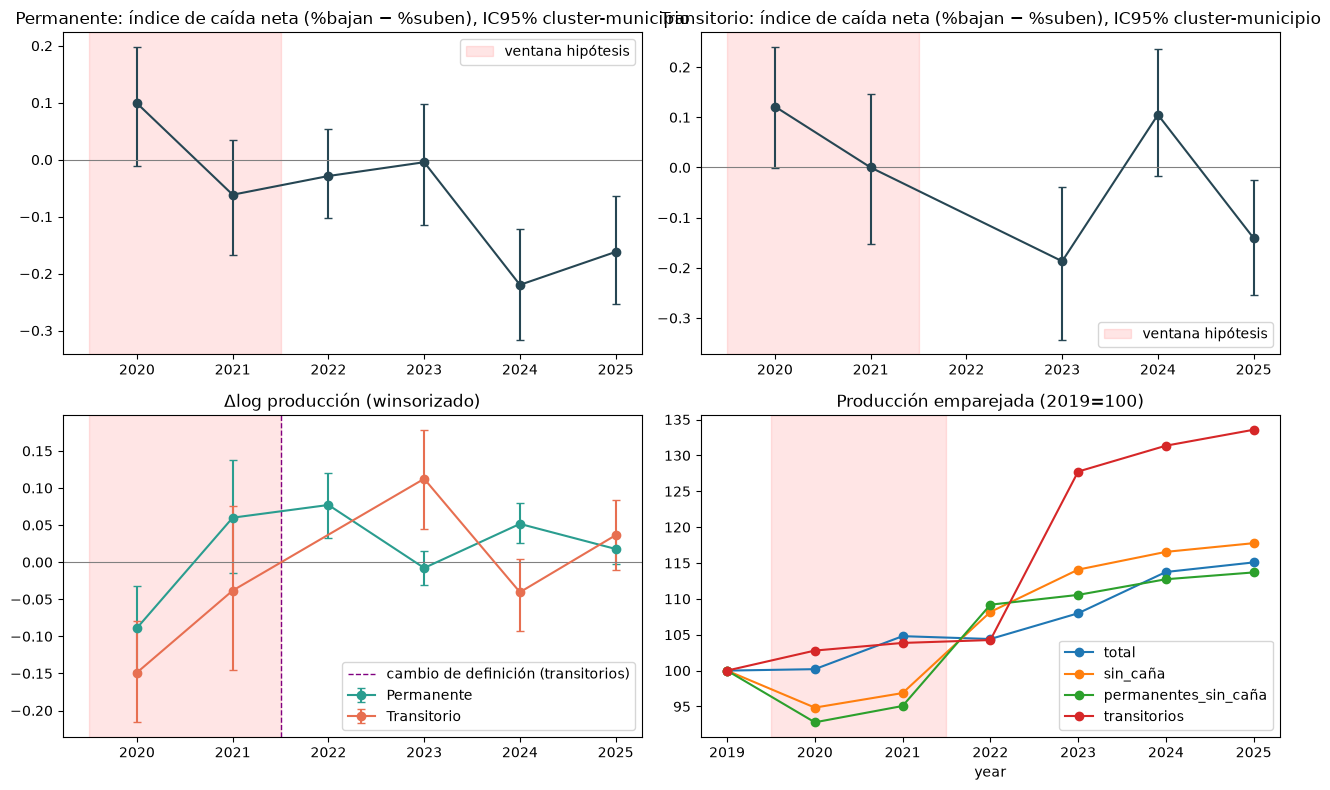

In [7]:
# Módulo 6 — Diagnóstico del shock
def winsorize_by(df: pd.DataFrame, col: str, by: list[str], q: float) -> pd.Series:
    lo = df.groupby(by)[col].transform(lambda s: s.quantile(q))
    hi = df.groupby(by)[col].transform(lambda s: s.quantile(1 - q))
    return df[col].clip(lo, hi)


def build_pairs(gp: pd.DataFrame, ga: pd.DataFrame, gy: pd.DataFrame, gpart: pd.DataFrame, meta: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    """Transiciones (serie, año s) con Δlog de P, A(cosechada) y Y(rendimiento). NaN si alguno de los dos años no es observado y positivo."""
    frames = []
    for s in list(gp.columns)[1:]:
        p0, p1, a0, a1, y0, y1 = gp[s - 1], gp[s], ga[s - 1], ga[s], gy[s - 1], gy[s]
        f = pd.DataFrame({"series_id": gp.index, "year": s,
                          "P0": p0.values, "P1": p1.values,
                          "dP": np.log(p1.where(p1 > 0) / p0.where(p0 > 0)).values,
                          "dA": np.log(a1.where(a1 > 0) / a0.where(a0 > 0)).values,
                          "dY": np.log(y1.where(y1 > 0) / y0.where(y0 > 0)).values,
                          "partial": ((gpart[s - 1].fillna(0) + gpart[s].fillna(0)) > 0).values,
                          "obs0": p0.notna().values, "obs1": p1.notna().values})
        frames.append(f)
    pr = pd.concat(frames, ignore_index=True).join(meta[["muni_code", "crop", "cycle", "group"]], on="series_id")
    pr["phase"] = pr["year"].map(lambda y: phase_of_year(y, cfg))
    pr["is_break"] = (pr["cycle"] == "Transitorio") & (pr["year"] == cfg.definition_break_year)
    for c in ("dP", "dA", "dY"):
        pr["w_" + c] = winsorize_by(pr.dropna(subset=[c]).assign(_k=1), c, ["year", "cycle"], cfg.winsor_q).reindex(pr.index)
    pr["net_dP"] = np.sign(pr["dP"])          # +1 sube, 0 igual, −1 baja  (media = %suben − %bajan)
    pr["net_dP"] = -pr["net_dP"]              # índice de CAÍDA neta: positivo = más series bajan que suben
    return pr


PAIRS = build_pairs(GP, GA, GY, GPART, META, CFG)
PAIRS_MAIN = PAIRS[~(PAIRS["is_break"] & CFG.exclude_definition_break)]      # variante principal (sin quiebre de definición)
print(f"Pares (serie,año): {len(PAIRS):,} | con Δlog(P) válido: {PAIRS['dP'].notna().sum():,} | marcados quiebre de definición: {int(PAIRS['is_break'].sum())}")


# --- bootstrap por conglomerados (municipio), vectorizado ---
def cell_matrices(df: pd.DataFrame, cell_cols: list[str], val: str, cluster: str = "muni_code"):
    d = df.dropna(subset=[val])
    g = d.groupby([cluster] + cell_cols)[val].agg(["sum", "count"])
    S = g["sum"].astype(float).unstack(cell_cols).fillna(0.0)
    N = g["count"].astype(float).unstack(cell_cols).fillna(0.0)
    return S.index.to_numpy(), S.columns, S.to_numpy(), N.reindex(columns=S.columns).fillna(0.0).to_numpy()


def boot_cell_means(S: np.ndarray, N: np.ndarray, B: int, seed: int) -> tuple[np.ndarray, np.ndarray]:
    """Devuelve (estimación puntual [K], réplicas [B×K]) de la media de cada celda remuestreando conglomerados."""
    rng = np.random.default_rng(seed)
    C = S.shape[0]
    W = rng.multinomial(C, np.full(C, 1.0 / C), size=B).astype(float)
    num, den = W @ S, W @ N
    reps = np.where(den > 0, num / np.maximum(den, 1e-12), np.nan)
    point = np.where(N.sum(0) > 0, S.sum(0) / np.maximum(N.sum(0), 1e-12), np.nan)
    return point, reps


def ci(reps: np.ndarray, lvl: float = 0.95):
    a = (1 - lvl) / 2
    return np.nanquantile(reps, a, axis=0), np.nanquantile(reps, 1 - a, axis=0)


STRATA = {"ALL": lambda d: d, "Permanente": lambda d: d[d["cycle"] == "Permanente"], "Transitorio": lambda d: d[d["cycle"] == "Transitorio"]}
METRICS = {"w_dP": "Δlog producción (winsor.)", "net_dP": "índice de caída neta", "w_dA": "Δlog área cosechada (winsor.)", "w_dY": "Δlog rendimiento (winsor.)"}


def year_effects(pairs: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    rows = []
    for sname, fn in STRATA.items():
        d = fn(pairs)
        for m in METRICS:
            _, cols, S, N = cell_matrices(d, ["year"], m)
            pt, reps = boot_cell_means(S, N, cfg.n_boot, cfg.seed)
            lo, hi = ci(reps)
            for k, y in enumerate(cols):
                rows.append({"estrato": sname, "metrica": m, "year": int(y), "fase": phase_of_year(int(y), cfg), "n_pares": int(N[:, k].sum()),
                             "media": pt[k], "ic95_lo": lo[k], "ic95_hi": hi[k]})
    ye = pd.DataFrame(rows)
    # composición direccional (%baja/%igual/%sube) sobre Δlog(P) válido
    dv = pairs.dropna(subset=["dP"])
    comp = dv.assign(dir=np.select([dv["dP"] < 0, dv["dP"] > 0], ["baja", "sube"], "igual")).groupby(["cycle", "year"])["dir"].value_counts(normalize=True).unstack(fill_value=0).reset_index()
    comp_all = dv.assign(dir=np.select([dv["dP"] < 0, dv["dP"] > 0], ["baja", "sube"], "igual")).groupby("year")["dir"].value_counts(normalize=True).unstack(fill_value=0).reset_index().assign(cycle="ALL")
    return ye, pd.concat([comp, comp_all], ignore_index=True)


YEAR_EFFECTS, DIRECTION = year_effects(PAIRS_MAIN, CFG)
save_table(YEAR_EFFECTS, "diagnostics", "year_effects.csv")
save_table(DIRECTION, "diagnostics", "direction_shares_by_year.csv")
print(YEAR_EFFECTS[(YEAR_EFFECTS.metrica == "w_dP")].pivot_table(index="year", columns="estrato", values="media").round(4))


# --- contrastes por fase ---
def phase_contrasts(pairs: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    rows = []
    for sname, fn in STRATA.items():
        d = fn(pairs)
        d = d[d["phase"].isin(["SHOCK", "RECOVERY", "POST"])]
        for m in METRICS:
            _, cols, S, N = cell_matrices(d, ["phase"], m)
            pt, reps = boot_cell_means(S, N, cfg.n_boot, cfg.seed)
            idx = {c: i for i, c in enumerate(cols)}
            for a, b in [("SHOCK", "POST"), ("RECOVERY", "POST"), ("SHOCK", "RECOVERY")]:
                if a in idx and b in idx:
                    est = pt[idx[a]] - pt[idx[b]]
                    r = reps[:, idx[a]] - reps[:, idx[b]]
                    lo, hi = ci(r[:, None])
                    rows.append({"estrato": sname, "metrica": m, "contraste": f"{a} − {b}", "media_A": pt[idx[a]], "media_B": pt[idx[b]], "diferencia": est,
                                 "ic95_lo": float(lo[0]), "ic95_hi": float(hi[0]), "excluye_cero": bool(lo[0] > 0 or hi[0] < 0)})
    return pd.DataFrame(rows)


PHASE_CONTRASTS = phase_contrasts(PAIRS_MAIN, CFG)
save_table(PHASE_CONTRASTS, "diagnostics", "phase_contrasts.csv")
print("\nContrastes por fase (Δlog producción winsorizado; signo negativo = más débil que POST):")
print(PHASE_CONTRASTS[PHASE_CONTRASTS.metrica.isin(["w_dP", "net_dP"])][["estrato", "metrica", "contraste", "media_A", "media_B", "diferencia", "ic95_lo", "ic95_hi", "excluye_cero"]].round(4).to_string(index=False))

# --- placebos: ¿es 2020-21 una ventana inusual frente a otras ventanas de 2 años? ---
def placebo_windows(pairs: pd.DataFrame) -> pd.DataFrame:
    yrs = sorted(pairs["year"].unique())
    rows = []
    for sname, fn in STRATA.items():
        d = fn(pairs).dropna(subset=["w_dP"])
        for a in yrs[:-1]:
            win = [a, a + 1]
            inw = d[d["year"].isin(win)]
            out = d[~d["year"].isin(win)]
            if len(inw) and len(out):
                rows.append({"estrato": sname, "ventana": f"{a}-{a+1}", "es_ventana_hipotesis": win == list(CFG.shock_years),
                             "media_ventana": inw["w_dP"].mean(), "media_resto": out["w_dP"].mean(), "contraste": inw["w_dP"].mean() - out["w_dP"].mean(),
                             "caida_neta_ventana": inw["net_dP"].mean(), "caida_neta_resto": out["net_dP"].mean()})
    t = pd.DataFrame(rows)
    t["rango_contraste(1=más negativo)"] = t.groupby("estrato")["contraste"].rank(method="min")
    return t


PLACEBO = placebo_windows(PAIRS_MAIN)
save_table(PLACEBO, "diagnostics", "placebo_windows.csv")
print("\nPlacebos (contraste = media ventana − media resto; 5 ventanas solapadas → descriptivo, no un test formal):")
print(PLACEBO.round(4).to_string(index=False))

# --- diferencia-en-diferencias: transitorio vs permanente (control) ---
def did_table(pairs: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    rows = []
    d0 = pairs[pairs["cycle"].isin(["Permanente", "Transitorio"])].copy()
    specs = {
        f"shock {cfg.shock_years[0]}-{cfg.shock_years[-1]}": (d0["year"].isin(cfg.shock_years), ~d0["year"].isin(cfg.shock_years) & (d0["year"] > max(cfg.shock_years))),
        f"quiebre definición {cfg.definition_break_year} (incluye el año)": (d0["year"] == cfg.definition_break_year, d0["year"] > cfg.definition_break_year),
    }
    for nm, (tmask, omask) in specs.items():
        d = d0[tmask | omask].assign(tgt=np.where(tmask[tmask | omask], "T", "O"))
        for m in ["w_dP", "net_dP", "w_dA", "w_dY"]:
            _, cols, S, N = cell_matrices(d, ["cycle", "tgt"], m)
            pt, reps = boot_cell_means(S, N, cfg.n_boot, cfg.seed)
            ix = {c: i for i, c in enumerate(cols)}
            try:
                f = lambda z: (z[..., ix[("Transitorio", "T")]] - z[..., ix[("Transitorio", "O")]]) - (z[..., ix[("Permanente", "T")]] - z[..., ix[("Permanente", "O")]])
            except KeyError:
                continue
            est, r = f(pt), f(reps)
            lo, hi = ci(r[:, None])
            rows.append({"evento": nm, "metrica": m, "did (trans−perm)": est, "ic95_lo": float(lo[0]), "ic95_hi": float(hi[0]), "excluye_cero": bool(lo[0] > 0 or hi[0] < 0)})
    return pd.DataFrame(rows)


DID = did_table(PAIRS, CFG)      # aquí SÍ se incluye el año de quiebre (es lo que se mide)
save_table(DID, "diagnostics", "did_transitorio_vs_permanente.csv")
print("\nDiferencia-en-diferencias (transitorio − permanente; permanente = control):")
print(DID.round(4).to_string(index=False))

# --- extensivo: entradas/salidas y ceros ---
def extensive_margin(pairs: pd.DataFrame) -> pd.DataFrame:
    p = pairs.copy()
    p["exit"] = p["obs0"] & ~p["obs1"]
    p["entry"] = ~p["obs0"] & p["obs1"]
    p["to_zero"] = p["obs0"] & p["obs1"] & (p["P0"] > 0) & (p["P1"] == 0)
    p["from_zero"] = p["obs0"] & p["obs1"] & (p["P0"] == 0) & (p["P1"] > 0)
    g = p.groupby(["cycle", "year"]).agg(salidas=("exit", "sum"), entradas=("entry", "sum"), pasan_a_cero=("to_zero", "sum"), salen_de_cero=("from_zero", "sum"),
                                         prod_t_salidas=("P0", lambda s: s[p.loc[s.index, "exit"]].sum()), prod_t_entradas=("P1", lambda s: s[p.loc[s.index, "entry"]].sum()))
    return g.reset_index()


EXTENSIVE = extensive_margin(PAIRS)
save_table(EXTENSIVE, "diagnostics", "extensive_margin.csv")
print("\nMargen extensivo (series que salen/entran o pasan a cero):")
print(EXTENSIVE.pivot_table(index="year", columns="cycle", values=["salidas", "entradas", "pasan_a_cero"], aggfunc="sum").fillna(0).astype(int).to_string())

# --- efecto composición: agregado desbalanceado vs. emparejado ---
def composition_effect(gp: pd.DataFrame, meta: pd.DataFrame) -> pd.DataFrame:
    bal = gp.dropna().index
    cane = meta["crop"].eq("Caña")
    rows = []
    for y in gp.columns:
        rows.append({"year": y, "total_desbalanceado_t": gp[y].sum(), "total_emparejado_t": gp.loc[bal, y].sum(), "n_series_desbalanceado": int(gp[y].notna().sum()), "n_series_emparejado": len(bal),
                     "sin_cana_desbalanceado_t": gp.loc[~cane.reindex(gp.index).fillna(False), y].sum(), "sin_cana_emparejado_t": gp.loc[bal.intersection(cane[~cane].index), y].sum(),
                     "cana_t": gp.loc[cane.reindex(gp.index).fillna(False), y].sum()})
    t = pd.DataFrame(rows)
    t["participacion_cana_%"] = t["cana_t"] / t["total_desbalanceado_t"] * 100
    return t


COMPOSITION = composition_effect(GP, META)
save_table(COMPOSITION, "diagnostics", "composition_effect.csv")
print("\nEfecto composición (t):")
print(COMPOSITION.round(1).to_string(index=False))

_ex = STATUS[STATUS["exit_before_end"] & (STATUS["last_year"] <= max(CFG.shock_years))].groupby("crop").agg(n_series_salen=("n_obs", "size")).join(
    STATUS[STATUS["entry_after_start"] & (STATUS["first_year"].isin(CFG.shock_years))].groupby("crop").agg(n_series_entran=("n_obs", "size")), how="outer").fillna(0).astype(int)
_ex["neto"] = _ex["n_series_entran"] - _ex["n_series_salen"]
RECLASS = _ex.sort_values("neto", key=lambda s: s.abs(), ascending=False)
save_table(RECLASS.reset_index(), "diagnostics", "entry_exit_by_crop_shock_window.csv")
print("\nCultivos con mayor rotación de series durante la ventana del shock (posible reclasificación taxonómica):")
print(RECLASS.head(10).to_string())

# --- heterogeneidad: ¿el cambio es municipal, de cultivo o de grupo? (R² ajustado por nº de niveles) ---
def adj_r2(d: pd.DataFrame, y: str, f: str) -> float:
    d = d.dropna(subset=[y, f])
    n, k = len(d), d[f].nunique()
    if n <= k + 1 or k < 2:
        return np.nan
    ss_t = ((d[y] - d[y].mean()) ** 2).sum()
    ss_w = ((d[y] - d.groupby(f)[y].transform("mean")) ** 2).sum()
    return 1 - (ss_w / (n - k)) / (ss_t / (n - 1))


HET = pd.DataFrame([{"year": int(s), "fase": phase_of_year(int(s), CFG), "n": int(g["w_dP"].notna().sum()),
                     **{f"R2adj_{f}": adj_r2(g, "w_dP", f) for f in ["muni_code", "crop", "group", "cycle"]}}
                    for s, g in PAIRS_MAIN.groupby("year")])
save_table(HET, "diagnostics", "heterogeneity_r2adj.csv")
print("\n¿Qué factor explica el cambio anual? (R² ajustado de Δlog P; alto en 2020-21 respecto de POST => shock sistemático):")
print(HET.round(3).to_string(index=False))

# --- intensidad y patrón por serie (ventana de la hipótesis) ---
def series_intensity(gp: pd.DataFrame, meta: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    pre_y = min(cfg.shock_years) - 1
    post_y = [y for y in gp.columns if phase_of_year(y, cfg) == "POST"]
    sh = gp[list(cfg.shock_years)].where(gp[list(cfg.shock_years)] > 0).mean(axis=1)
    pre = gp[pre_y].where(gp[pre_y] > 0) if pre_y in gp.columns else pd.Series(np.nan, index=gp.index)
    post = gp[post_y].where(gp[post_y] > 0).mean(axis=1)
    out = pd.DataFrame({"P_pre": pre, "P_shock_mean": sh, "P_post_mean": post})
    out["intensidad_log"] = np.log(out["P_shock_mean"] / out["P_pre"])          # <0: caída vs. 2019
    out["rebote_log"] = np.log(out["P_post_mean"] / out["P_shock_mean"])        # >0: recupera después
    tol = cfg.intensity_tol
    out["patron"] = np.select(
        [out["intensidad_log"].isna() | out["rebote_log"].isna(), (out["intensidad_log"] < -tol) & (out["rebote_log"] > tol), out["intensidad_log"] < -tol,
         out["intensidad_log"] > tol],
        ["no_evaluable", "V (caída y rebote)", "caída sostenida", "alza durante la ventana"], "sin efecto (±tol)")
    return out.join(meta[["muni", "crop", "cycle", "group"]])


INTENSITY = series_intensity(GP, META, CFG)
save_table(INTENSITY.reset_index(), "diagnostics", "shock_intensity_by_series.csv")
pat = INTENSITY.groupby(["cycle", "patron"]).size().unstack(fill_value=0)
print("\nPatrón por serie (nº de series):")
print(pat.to_string())
print("\nIntensidad mediana de la ventana vs. 2019 (log; <0 = caída) por grupo de cultivo — solo grupos con ≥15 series evaluables:")
_gi = INTENSITY.dropna(subset=["intensidad_log"]).groupby("group").agg(n=("intensidad_log", "size"), mediana=("intensidad_log", "median"), p25=("intensidad_log", lambda s: s.quantile(.25)), p75=("intensidad_log", lambda s: s.quantile(.75)))
print(_gi[_gi.n >= 15].round(3).to_string())
save_table(_gi.reset_index(), "diagnostics", "shock_intensity_by_group.csv")

# --- índice de producción emparejado (2019=100) para el gráfico y el informe ---
def matched_index(gp: pd.DataFrame, meta: pd.DataFrame) -> pd.DataFrame:
    bal = gp.dropna().index
    bal = bal[(gp.loc[bal] > 0).all(axis=1)]
    cane = meta.loc[bal, "crop"].eq("Caña")
    base = {"total": gp.loc[bal], "sin_caña": gp.loc[bal[~cane.values]],
            "permanentes_sin_caña": gp.loc[[s for s in bal[~cane.values] if meta.loc[s, "cycle"] == "Permanente"]],
            "transitorios": gp.loc[[s for s in bal if meta.loc[s, "cycle"] == "Transitorio"]]}
    return pd.DataFrame({k: v.sum() / v.sum().iloc[0] * 100 for k, v in base.items()}), len(bal)


MIDX, N_BAL = matched_index(GP, META)
save_table(MIDX.rename_axis("year").reset_index(), "diagnostics", "matched_production_index.csv")
print(f"\nÍndice de producción, panel emparejado (n={N_BAL} series presentes y >0 los 7 años; 2019=100):")
print(MIDX.round(1).to_string())

# --- gráficos ---
fig, ax = plt.subplots(2, 2, figsize=(13, 8))
for j, sname in enumerate(["Permanente", "Transitorio"]):
    t = YEAR_EFFECTS[(YEAR_EFFECTS.estrato == sname) & (YEAR_EFFECTS.metrica == "net_dP")]
    ax[0, j].errorbar(t.year, t.media, yerr=[t.media - t.ic95_lo, t.ic95_hi - t.media], fmt="o-", capsize=3, color="#264653")
    ax[0, j].axvspan(min(CFG.shock_years) - .5, max(CFG.shock_years) + .5, color="red", alpha=.10, label="ventana hipótesis")
    ax[0, j].axhline(0, color="grey", lw=.8); ax[0, j].set_title(f"{sname}: índice de caída neta (%bajan − %suben), IC95% cluster-municipio"); ax[0, j].legend()
for sname, c in [("Permanente", "#2a9d8f"), ("Transitorio", "#e76f51")]:
    t = YEAR_EFFECTS[(YEAR_EFFECTS.estrato == sname) & (YEAR_EFFECTS.metrica == "w_dP")]
    ax[1, 0].errorbar(t.year, t.media, yerr=[t.media - t.ic95_lo, t.ic95_hi - t.media], fmt="o-", capsize=3, color=c, label=sname)
ax[1, 0].axvspan(min(CFG.shock_years) - .5, max(CFG.shock_years) + .5, color="red", alpha=.10); ax[1, 0].axhline(0, color="grey", lw=.8)
ax[1, 0].axvline(CFG.definition_break_year - .5, color="purple", ls="--", lw=1, label="cambio de definición (transitorios)"); ax[1, 0].set_title("Δlog producción (winsorizado)"); ax[1, 0].legend()
MIDX.plot(ax=ax[1, 1], marker="o"); ax[1, 1].axvspan(min(CFG.shock_years) - .5, max(CFG.shock_years) + .5, color="red", alpha=.10); ax[1, 1].set_title("Producción emparejada (2019=100)")
plt.tight_layout(); plt.savefig(OUT["diagnostics"] / "shock_diagnostic.png", dpi=130); plt.show()

## Módulo 7 — Feature engineering
* **Rezagos calendario**: `grid.shift(1, axis=1)` sobre la grilla completa serie × año ⇒ el rezago es *el año anterior real* (si falta, `NaN`; nunca se «cierra» un hueco como hacía v3).
* **Producción = Área × Rendimiento** ⇒ en logs `Δlog P = Δlog A + Δlog Y` es una *identidad exacta*. Incluir a la vez `P_lag`, `A_lag` y `Y_lag` (spec de v3) es colinealidad casi perfecta.
  v5 usa **`Δlog A`** y **`Δlog Y`** rezagados (no colineales entre sí) + reversión a la media del rendimiento, y **nunca** `Δlog P` rezagado junto a ambos.
* **Indicadores de régimen** (de calendario, conocidos ex-ante): fase, `shock`, `recuperación`, `quiebre de definición` (transitorios, año 2022), `provisional`, `año parcial`.
* Todo modelo recibe un `Ctx` construido **solo con columnas ≤ origen** (módulo 8): estructuralmente no puede ver el futuro.

In [8]:
# Módulo 7 — Feature engineering
def lag_grid(g: pd.DataFrame, k: int = 1) -> pd.DataFrame:
    """Rezago calendario de k años (gap-safe): el valor en la columna t es el observado en t−k, o NaN."""
    return g.shift(k, axis=1)


def dlog_grid(g: pd.DataFrame) -> pd.DataFrame:
    """Δlog entre años consecutivos; NaN si algún extremo falta o no es positivo."""
    pos = g.where(g > 0)
    return np.log(pos / pos.shift(1, axis=1))


def regime_table(years: Sequence[int], cfg: Config) -> pd.DataFrame:
    t = pd.DataFrame({"year": list(years)})
    t["phase"] = t["year"].map(lambda y: phase_of_year(y, cfg))
    t["is_shock"] = t["year"].isin(cfg.shock_years)
    t["is_recovery"] = t["year"].isin(cfg.recovery_years)
    t["is_definition_break_year"] = t["year"] == cfg.definition_break_year
    t["is_provisional"] = t["year"].isin(cfg.provisional_years)
    return t


REGIME = regime_table(YEARS, CFG)
save_table(REGIME, "temporal", "regime_calendar.csv")
DPG, DAG, DYG = dlog_grid(GP), dlog_grid(GA), dlog_grid(GY)
print(REGIME.to_string(index=False))


def vif_table(X: pd.DataFrame) -> pd.DataFrame:
    """VIF_j = 1/(1−R²_j) con regresión auxiliar por MCO; + número de condición de la matriz estandarizada."""
    Z = (X - X.mean()) / X.std(ddof=0)
    rows = []
    for c in Z.columns:
        others = Z.drop(columns=c).to_numpy()
        yv = Z[c].to_numpy()
        b, *_ = np.linalg.lstsq(np.column_stack([np.ones(len(Z)), others]), yv, rcond=None)
        r2 = 1 - ((yv - np.column_stack([np.ones(len(Z)), others]) @ b) ** 2).sum() / ((yv - yv.mean()) ** 2).sum()
        rows.append({"variable": c, "VIF": 1 / max(1 - r2, 1e-12)})
    out = pd.DataFrame(rows)
    out["cond_number"] = np.linalg.cond(Z.to_numpy())
    return out


# Evidencia de colinealidad: especificación v3 (niveles) vs. v5 (Δlog A, Δlog Y, reversión)
_lv = pd.DataFrame({"prod_lag1": lag_grid(GP).stack(), "rend_lag1": lag_grid(GY).stack(), "area_lag1": lag_grid(GA).stack()}).dropna()
_lv = _lv[(_lv > 0).all(axis=1)]
_v5 = pd.DataFrame({"dlogA_lag1": lag_grid(DAG).stack(), "dlogY_lag1": lag_grid(DYG).stack(),
                    "logY_dev": (np.log(lag_grid(GY).where(lag_grid(GY) > 0)) - np.log(GY.where(GY > 0)).T.expanding(min_periods=1).mean().T.shift(1, axis=1)).stack()}).dropna()
VIF_V3 = vif_table(_lv).assign(especificacion="v3: niveles (prod_lag1, rend_lag1, area_lag1)")
VIF_V5 = vif_table(_v5).assign(especificacion="v5: Δlog A, Δlog Y, reversión rend.")
_ident = np.corrcoef(np.log(_lv["prod_lag1"]), np.log(_lv["rend_lag1"]) + np.log(_lv["area_lag1"]))[0, 1]
VIF_ALL = pd.concat([VIF_V3, VIF_V5], ignore_index=True)
save_table(VIF_ALL, "models", "collinearity_evidence.csv")
print(VIF_ALL.round(2).to_string(index=False))
print(f"corr(log P_lag, log A_lag + log Y_lag) = {_ident:.6f}  (identidad producción = área × rendimiento)")

 year    phase  is_shock  is_recovery  is_definition_break_year  is_provisional
 2019      PRE     False        False                     False           False
 2020    SHOCK      True        False                     False           False
 2021    SHOCK      True        False                     False           False
 2022 RECOVERY     False         True                      True           False
 2023 RECOVERY     False         True                     False           False
 2024     POST     False        False                     False            True
 2025     POST     False        False                     False            True
  variable     VIF  cond_number                                especificacion
 prod_lag1 15.9300       8.4600 v3: niveles (prod_lag1, rend_lag1, area_lag1)
 rend_lag1  1.3500       8.4600 v3: niveles (prod_lag1, rend_lag1, area_lag1)
 area_lag1 15.4100       8.4600 v3: niveles (prod_lag1, rend_lag1, area_lag1)
dlogA_lag1  1.0000       2.6400           v5: Δl

## Módulo 8 — Baselines y contexto sin fuga
`Ctx` contiene únicamente datos con año ≤ `origin`. Los modelos son funciones puras `f(ctx, h) -> (predicción, bandera_fallback)`.
* **naive**: último valor. **mean**: media de la historia observada. **drift**: extrapolación lineal primer→último punto *usando los años reales* (no la posición).
* **ols_trend / theil_sen**: tendencia lineal (MCO) y tendencia robusta (mediana de pendientes por pares, resistente a un año extremo como 2020). Necesitan ≥3 observaciones; si no, caen a *drift/naive* y se **marca el fallback** (nunca se oculta).
* **seasonal naive**: con datos anuales el período estacional es 1 ⇒ coincide con naive (no aplica); se evalúa en la rama semestral (módulo 10b).

In [9]:
# Módulo 8 — Baselines
@dataclass
class Ctx:
    """Vista de los datos disponibles en el año `origin` (columnas ≤ origin)."""
    origin: int
    years: np.ndarray
    P: np.ndarray
    A: np.ndarray
    Y: np.ndarray
    part: np.ndarray
    cycle: np.ndarray
    group: np.ndarray
    index: pd.Index
    cfg: Config

    @property
    def last(self) -> np.ndarray:
        return self.P[:, -1]

    @property
    def n_obs(self) -> np.ndarray:
        return (~np.isnan(self.P)).sum(axis=1)


def make_ctx(origin: int, gp: pd.DataFrame, ga: pd.DataFrame, gy: pd.DataFrame, gpart: pd.DataFrame, meta: pd.DataFrame, cfg: Config) -> Ctx:
    cols = [c for c in gp.columns if c <= origin]
    if not cols or cols[-1] != origin:
        raise DataValidationError("BAD_ORIGIN", f"origen {origin} fuera de la grilla {list(gp.columns)}")
    return Ctx(origin, np.array(cols), gp[cols].to_numpy(float), ga[cols].to_numpy(float), gy[cols].to_numpy(float), gpart[cols].fillna(0).to_numpy(float),
               meta["cycle"].to_numpy(dtype=object), meta["group"].to_numpy(dtype=object), gp.index, cfg)


def _first_obs(P: np.ndarray):
    obs = ~np.isnan(P)
    fi = np.where(obs.any(1), obs.argmax(1), 0)
    return obs, fi


def m_naive(c: Ctx, h: int):
    return c.last.copy(), np.zeros(len(c.last), bool)


def m_mean(c: Ctx, h: int):
    with np.errstate(all="ignore"):
        m = np.nanmean(c.P, axis=1)
    return np.where(np.isnan(c.last), np.nan, m), np.zeros(len(m), bool)


def m_drift(c: Ctx, h: int):
    obs, fi = _first_obs(c.P)
    n = obs.sum(1)
    yr_first = c.years[fi]
    y_first = c.P[np.arange(len(fi)), fi]
    span = c.years[-1] - yr_first
    ok = (n >= 2) & (span > 0) & ~np.isnan(c.last)
    slope = np.where(ok, (c.last - y_first) / np.where(span > 0, span, 1), 0.0)
    pred = np.where(np.isnan(c.last), np.nan, np.maximum(c.last + h * slope, 0.0))
    return pred, (~ok) & ~np.isnan(c.last)


def m_ols_trend(c: Ctx, h: int):
    obs = ~np.isnan(c.P)
    n = obs.sum(1)
    x = np.broadcast_to(c.years.astype(float), c.P.shape)
    xm = np.where(obs, x, 0).sum(1) / np.maximum(n, 1)
    Pm = np.where(obs, c.P, 0)
    ym = Pm.sum(1) / np.maximum(n, 1)
    sxx = (np.where(obs, (x - xm[:, None]) ** 2, 0)).sum(1)
    sxy = (np.where(obs, (x - xm[:, None]) * (Pm - ym[:, None]), 0)).sum(1)
    ok = (n >= c.cfg.min_obs_trend) & (sxx > 0) & ~np.isnan(c.last)
    slope = np.where(ok, sxy / np.where(sxx > 0, sxx, 1), 0.0)
    pred = np.where(ok, np.maximum(ym + slope * (c.origin + h - xm), 0.0), np.nan)
    fb_pred, _ = m_drift(c, h)
    fb = ~ok & ~np.isnan(c.last)
    return np.where(ok, pred, fb_pred), fb


def m_theil_sen(c: Ctx, h: int):
    pred = np.full(len(c.last), np.nan)
    fb = np.zeros(len(c.last), bool)
    dpred, _ = m_drift(c, h)
    for i in range(len(c.last)):
        if np.isnan(c.last[i]):
            continue
        o = ~np.isnan(c.P[i])
        if o.sum() < c.cfg.min_obs_trend:
            pred[i], fb[i] = dpred[i], True
            continue
        x, y = c.years[o].astype(float), c.P[i, o]
        ii, jj = np.triu_indices(len(x), 1)
        slopes = (y[jj] - y[ii]) / (x[jj] - x[ii])
        s = np.median(slopes)
        b = np.median(y - s * x)
        pred[i] = max(b + s * (c.origin + h), 0.0)
    return pred, fb


BASELINE_MODELS: dict[str, Callable] = {"naive": m_naive, "mean": m_mean, "drift": m_drift, "ols_trend": m_ols_trend, "theil_sen": m_theil_sen}
MODEL_FAMILY = {"naive": "baseline", "mean": "baseline", "drift": "baseline", "ols_trend": "tendencia", "theil_sen": "tendencia robusta"}
MODEL_H_SUPPORT: dict[str, Callable[[int], bool]] = {}      # por defecto todos los horizontes


def ctx_for(origin: int, cfg: Config = CFG, gp=None, ga=None, gy=None, gpart=None, meta=None) -> Ctx:
    return make_ctx(origin, GP if gp is None else gp, GA if ga is None else ga, GY if gy is None else gy, GPART if gpart is None else gpart, META if meta is None else meta, cfg)

## Módulo 9 — Backtesting temporal
**Diseño.** Ventana *expanding* con origen `o` y objetivo `o + h` (h = 1, 2). Entrenamiento = columnas ≤ `o`. Un objetivo `T` solo se pronostica con datos ≤ `T − h`.
* Serie elegible en un fold: observada en `o` y en `T` (no hay «años imaginarios»), con ≥ `min_train_obs` observaciones.
* **Fold final reservado**: el objetivo `HOLDOUT` (último año) jamás participa en selección de modelo (módulo 11).
* **Métricas** (cada una con su denominador validado):
  `MAE`, `RMSE` (t; solo por estrato/agregado, *no* se promedian entre series de escala distinta), `sMAPE` (0/0 ≡ 0, acotado a [0,200]),
  `MALE` = |log1p(ŷ) − log1p(y)| (error relativo simétrico, definido con ceros; métrica de selección), `RMSLE`,
  `MASE` solo si hay ≥2 diferencias en el entrenamiento y la escala > 0 (**sin** sustitución por escala global), `RelMAE` = media geométrica de MAE_modelo/MAE_naive por serie,
  `WAPE` = Σ|e|/Σ|y| (sesgado hacia la caña: se reporta también sin caña).
* Los objetivos de **Transitorios en 2022** (quiebre de definición) se reportan aparte y **no** entran a selección ni a métricas titulares.

In [10]:
# Módulo 9 — Backtesting
def mase_scale(P: np.ndarray, years: np.ndarray) -> np.ndarray:
    """Escala MASE por serie: media de |Δ| entre años CONSECUTIVOS observados en el entrenamiento. NaN si <2 diferencias o escala = 0."""
    d = np.abs(np.diff(P, axis=1))                                   # NaN si alguno falta => no se «cierran» huecos
    cnt = (~np.isnan(d)).sum(1)
    with np.errstate(all="ignore"):
        sc = np.nanmean(np.where(np.isnan(d), np.nan, d), axis=1)
    return np.where((cnt >= 2) & (sc > 0), sc, np.nan)


def valid_origins(h: int, cfg: Config) -> list[int]:
    first = YEARS[0] + cfg.min_train_obs - 1
    return [o for o in YEARS if first <= o and o + h <= YEARS[-1]]


def run_backtest(models: dict[str, Callable], cfg: Config = CFG, horizons: Optional[Sequence[int]] = None, support: Optional[dict] = None,
                 gp=None, ga=None, gy=None, gpart=None, meta=None) -> pd.DataFrame:
    """Backtest expanding-window. Devuelve tabla larga (modelo, h, origen, objetivo, serie, y_true, y_pred, fallback, ...)."""
    gp_ = GP if gp is None else gp
    meta_ = META if meta is None else meta
    rows = []
    for h in (horizons or cfg.horizons):
        for o in valid_origins(h, cfg):
            tgt = o + h
            if tgt not in gp_.columns:
                continue
            ctx = ctx_for(o, cfg, gp, ga, gy, gpart, meta)
            y_true = gp_[tgt].to_numpy(float)
            elig = (~np.isnan(ctx.last)) & (~np.isnan(y_true)) & (ctx.n_obs >= cfg.min_train_obs)
            if not elig.any():
                continue
            sc = mase_scale(ctx.P, ctx.years)
            for name, fn in models.items():
                if support and name in support and not support[name](h):
                    continue
                pred, fb = fn(ctx, h)
                rows.append(pd.DataFrame({"model": name, "h": h, "origin": o, "target": tgt, "series_id": ctx.index[elig], "y_true": y_true[elig], "y_pred": pred[elig],
                                          "fallback": fb[elig], "n_obs": ctx.n_obs[elig], "mase_scale": sc[elig], "y_last": ctx.last[elig]}))
    bt = pd.concat(rows, ignore_index=True)
    meta_c = meta_[["muni_code", "crop", "cycle", "group"]]
    bt = bt.join(meta_c, on="series_id")
    bt["target_phase"] = bt["target"].map(lambda y: phase_of_year(y, cfg))
    bt["is_break_target"] = (bt["cycle"] == "Transitorio") & (bt["target"] == cfg.definition_break_year)
    bt["is_provisional_target"] = bt["target"].isin(cfg.provisional_years)
    return bt


def score_rows(bt: pd.DataFrame) -> pd.DataFrame:
    d = bt.copy()
    d["e"] = d["y_true"] - d["y_pred"]
    d["ae"] = d["e"].abs()
    den = d["y_true"].abs() + d["y_pred"].abs()
    d["smape"] = np.where(den == 0, 0.0, 200 * d["ae"] / np.where(den == 0, 1, den))
    d["le"] = (np.log1p(d["y_pred"].clip(lower=0)) - np.log1p(d["y_true"].clip(lower=0))).abs()
    d["mase"] = d["ae"] / d["mase_scale"]           # NaN si la escala no es válida
    return d


def agg_metrics(sc: pd.DataFrame, by: list[str]) -> pd.DataFrame:
    """Agrega métricas por grupo. Cada métrica reporta su n válido. RelMAE vs naive se calcula con las mismas filas."""
    naive = sc[sc["model"] == "naive"].set_index(["h", "origin", "series_id"])["ae"]
    d = sc.join(naive.rename("ae_naive"), on=["h", "origin", "series_id"])
    def one(g: pd.DataFrame) -> pd.Series:
        sser = g.groupby("series_id").agg(mae=("ae", "mean"), mae_n=("ae_naive", "mean"))
        ok = sser["mae_n"] > 0
        rel = np.exp(np.log(sser.loc[ok, "mae"].clip(lower=1e-9) / sser.loc[ok, "mae_n"]).mean()) if ok.any() else np.nan
        sy = g["y_true"].abs().sum()
        return pd.Series({"n": len(g), "n_series": g["series_id"].nunique(), "MAE_t": g["ae"].mean(), "RMSE_t": np.sqrt((g["e"] ** 2).mean()),
                          "sMAPE_%": g["smape"].mean(), "MALE": g["le"].mean(), "RMSLE": np.sqrt((g["le"] ** 2).mean()),
                          "MASE_mediana": g["mase"].median(), "MASE_n_validos": int(g["mase"].notna().sum()),
                          "RelMAE_vs_naive": rel, "RelMAE_n_series": int(ok.sum()), "WAPE_%": 100 * g["ae"].sum() / sy if sy > 0 else np.nan,
                          "sesgo_pct_mediano": 100 * np.median(np.where(g["y_true"] > 0, g["e"] / np.where(g["y_true"] > 0, g["y_true"], 1), np.nan)[g["y_true"] > 0]) if (g["y_true"] > 0).any() else np.nan,
                          "pct_fallback": 100 * g["fallback"].mean()})
    return d.groupby(by).apply(one, include_groups=False).reset_index()


def paired_boot_vs(sc: pd.DataFrame, model: str, base: str = "naive", metric: str = "le", B: int = 500, seed: int = 0) -> dict:
    """Diferencia pareada (modelo − base) de `metric` con IC95% bootstrap por conglomerados (municipio). <0 = el modelo mejora."""
    a = sc[sc["model"] == model].set_index(["h", "origin", "series_id"])
    b = sc[sc["model"] == base].set_index(["h", "origin", "series_id"])
    j = a[[metric, "muni_code"]].join(b[[metric]], rsuffix="_b", how="inner")
    j["d"] = j[metric] - j[metric + "_b"]
    if len(j) < 20:
        return {"n": len(j), "delta": np.nan, "lo": np.nan, "hi": np.nan, "p_mejora": np.nan}
    _, _, S, N = cell_matrices(j.assign(cell="all"), ["cell"], "d")
    pt, reps = boot_cell_means(S, N, B, seed)
    lo, hi = ci(reps)
    return {"n": len(j), "delta": float(pt[0]), "lo": float(lo[0]), "hi": float(hi[0]), "p_mejora": float((reps[:, 0] < 0).mean())}


BT_BASE = run_backtest(BASELINE_MODELS, CFG)
print(f"Backtest baselines: {len(BT_BASE):,} filas | folds h=1 origenes {valid_origins(1, CFG)} | h=2 origenes {valid_origins(2, CFG)}")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_26004\3789450820.py:7: RuntimeWarning: Mean of empty slice
  sc = np.nanmean(np.where(np.isnan(d), np.nan, d), axis=1)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_26004\2556242653.py:45: RuntimeWarning: Mean of empty slice
  m = np.nanmean(c.P, axis=1)


Backtest baselines: 45,000 filas | folds h=1 origenes [2020, 2021, 2022, 2023, 2024] | h=2 origenes [2020, 2021, 2022, 2023]


## Módulo 10 — Modelos pooled / panel con tratamiento explícito del shock
Con ≈7 observaciones anuales por serie no se justifican modelos individuales complejos: se estima **información transversal** (pooled) y solo se
permite variación de la serie mediante *contracción* hacia el estrato. Todos operan sobre el **log-crecimiento** `g = Δlog P` (escala relativa, no dominada por la caña)
y proyectan `ŷ = y_último · exp(h·ĝ)`.

| Modelo | Qué asume sobre 2020-2021 | Idea |
|---|---|---|
| `pool_A_full` | nada: historia completa, peso 1 a todos los años | baseline pooled («A») |
| `pool_B_interv` | **intervención**: los años de shock se modelan con su propio efecto y salen del crecimiento «normal» | «B» |
| `pool_C_post` | **prioridad post-shock**: pesos 0 / 0,5 / 1 para shock / recuperación / post | «C» |
| `pool_D_eb` | robusto/regularizado: como B + **contracción empírica-Bayes** del crecimiento de cada serie hacia su estrato, con winsorización | «D» |
| `ridge_lag` | regresión ridge pooled: `Δlog P_t ~ Δlog A_{t−1}, Δlog Y_{t−1}, desvío del rendimiento, ciclo, dummy shock` | rezagos agronómicos sin colinealidad |
| `ens_mean` | promedio en log1p de {naive, pool_B, pool_D, ridge_lag, theil_sen} (componentes fijados a priori) | ensemble (se adopta solo si el backtest lo respalda) |

Los pesos por fase están en `Config` y **no se ajustaron sobre el backtest**. El quiebre de definición 2022 de transitorios queda fuera de las *estimaciones* de crecimiento (no de los datos).

In [11]:
# Módulo 10 — Modelos
PHASE_IDX = {"SHOCK": 0, "RECOVERY": 1, "POST": 2, "PRE": 2}


def _year_weights(years_t: np.ndarray, weights: Sequence[float], cfg: Config) -> np.ndarray:
    return np.array([weights[PHASE_IDX[phase_of_year(int(y), cfg)]] for y in years_t], dtype=float)


def _dlog(M: np.ndarray) -> np.ndarray:
    pos = np.where(M > 0, M, np.nan)
    with np.errstate(all="ignore"):
        return np.log(pos[:, 1:] / pos[:, :-1])


def _winsorize_cols(G: np.ndarray, years_t: np.ndarray, cycle: np.ndarray, q: float) -> np.ndarray:
    """Winsoriza cada (año, ciclo) en [q, 1−q] usando solo esa celda (dato del entrenamiento)."""
    out = G.copy()
    for j in range(G.shape[1]):
        for cy in np.unique(cycle):
            m = (cycle == cy) & ~np.isnan(G[:, j])
            if m.sum() >= 10:
                lo, hi = np.quantile(G[m, j], [q, 1 - q])
                out[m, j] = np.clip(G[m, j], lo, hi)
    return out


def growth_matrix(c: Ctx, which: str = "P") -> tuple[np.ndarray, np.ndarray]:
    """Log-crecimientos winsorizados (n × k−1) con el quiebre de definición (transitorios) enmascarado si así lo indica la config."""
    G = _dlog({"P": c.P, "A": c.A, "Y": c.Y}[which])
    yrs_t = c.years[1:]
    G = _winsorize_cols(G, yrs_t, c.cycle, c.cfg.winsor_q)
    if c.cfg.exclude_definition_break and c.cfg.definition_break_year in yrs_t:
        j = int(np.where(yrs_t == c.cfg.definition_break_year)[0][0])
        G[c.cycle == "Transitorio", j] = np.nan
    return G, yrs_t


def strata_labels(c: Ctx, G: np.ndarray) -> np.ndarray:
    """Estrato = ciclo|grupo si el grupo tiene ≥ min_stratum_series series con crecimiento observable en el ENTRENAMIENTO; si no, solo ciclo."""
    has = ~np.isnan(G).all(axis=1)
    key = np.array([f"{a}|{b}" for a, b in zip(c.cycle, c.group)], dtype=object)
    cnt = pd.Series(key[has]).value_counts()
    big = set(cnt[cnt >= c.cfg.min_stratum_series].index)
    return np.array([k if k in big else cy for k, cy in zip(key, c.cycle)], dtype=object)


def _weighted_stratum_mu(G: np.ndarray, strat: np.ndarray, w_year: np.ndarray, min_cell: int = 3) -> dict:
    """μ_k = Σ_s w_s·m_{k,s} / Σ_s w_s, con m_{k,s} = media (winsorizada) del estrato k en el año s; celdas con <min_cell datos no cuentan."""
    mu = {}
    for k in np.unique(strat):
        rows = strat == k
        num = den = 0.0
        for j in range(G.shape[1]):
            v = G[rows, j]
            v = v[~np.isnan(v)]
            if len(v) >= min_cell and w_year[j] > 0:
                num += w_year[j] * v.mean()
                den += w_year[j]
        mu[k] = num / den if den > 0 else np.nan
    return mu


def pooled_core(c: Ctx, weights: Sequence[float], full_weights: Sequence[float]) -> tuple[np.ndarray, np.ndarray, dict]:
    """Devuelve (μ por serie [n], fallback [n], info). Escalera de respaldo: pesos pedidos -> pesos 'full' -> media del ciclo -> 0."""
    cfg = c.cfg
    G, yrs_t = growth_matrix(c, "P")
    n = len(c.last)
    if G.shape[1] == 0:
        return np.zeros(n), np.ones(n, bool), {"n_transition_years": 0}
    strat = strata_labels(c, G)
    w = _year_weights(yrs_t, weights, cfg)
    wf = _year_weights(yrs_t, full_weights, cfg)
    mu_req = _weighted_stratum_mu(G, strat, w)
    mu_full = _weighted_stratum_mu(G, strat, wf)
    cyc_req = _weighted_stratum_mu(G, c.cycle, w)
    cyc_full = _weighted_stratum_mu(G, c.cycle, wf)
    mu = np.zeros(n)
    fb = np.zeros(n, bool)
    for i in range(n):
        v = mu_req.get(strat[i], np.nan)
        if np.isnan(v):
            v = cyc_req.get(c.cycle[i], np.nan)
        if np.isnan(v):
            fb[i] = True
            v = mu_full.get(strat[i], np.nan)
            if np.isnan(v):
                v = cyc_full.get(c.cycle[i], np.nan)
            if np.isnan(v):
                v = 0.0
        mu[i] = v
    return mu, fb, {"strat": strat, "G": G, "years_t": yrs_t, "w": w, "mu_strat": mu_req}


def _growth_predict(c: Ctx, h: int, g_i: np.ndarray, fb: np.ndarray):
    last = c.last
    pred = np.where(np.isnan(last), np.nan, np.where(last > 0, last * np.exp(h * g_i), 0.0))
    return pred, fb & ~np.isnan(last)


def m_pool_A(c: Ctx, h: int):
    mu, fb, _ = pooled_core(c, c.cfg.phase_weights_full, c.cfg.phase_weights_full)
    return _growth_predict(c, h, mu, fb)


def m_pool_B(c: Ctx, h: int):
    mu, fb, _ = pooled_core(c, c.cfg.phase_weights_interv, c.cfg.phase_weights_full)
    return _growth_predict(c, h, mu, fb)


def m_pool_C(c: Ctx, h: int):
    mu, fb, _ = pooled_core(c, c.cfg.phase_weights_post, c.cfg.phase_weights_full)
    return _growth_predict(c, h, mu, fb)


def eb_shrunk_growth(c: Ctx, weights: Sequence[float], full_weights: Sequence[float]) -> tuple[np.ndarray, np.ndarray, dict]:
    """Contracción empírica-Bayes: ĝ_i = μ_k + ω_i (ḡ_i − μ_k), ω_i = n_i/(n_i+κ), κ = σ²_within/τ²_between (momentos robustos, sin hiperparámetros libres)."""
    mu, fb, info = pooled_core(c, weights, full_weights)
    if not info.get("n_transition_years"):
        pass
    if "G" not in info:
        return mu, fb, {"kappa": np.nan}
    G, w = info["G"], info["w"]
    valid = ~np.isnan(G) & (w[None, :] > 0)
    n_i = valid.sum(1)
    Wm = np.where(valid, w[None, :], 0.0)
    gbar = np.where(n_i > 0, (np.where(valid, G, 0.0) * Wm).sum(1) / np.maximum(Wm.sum(1), 1e-12), 0.0)
    s2 = np.array([np.var(G[i, valid[i]], ddof=1) if n_i[i] >= 2 else np.nan for i in range(len(mu))])
    sigma2 = float(np.nanmedian(s2)) if np.isfinite(s2).any() else 0.0
    dev = (gbar - mu)[n_i > 0]
    mad = np.median(np.abs(dev - np.median(dev))) * 1.4826 if len(dev) else 0.0
    inv_n = float(np.mean(1.0 / n_i[n_i > 0])) if (n_i > 0).any() else 0.0
    tau2 = max(mad ** 2 - sigma2 * inv_n, 0.0)
    kappa = sigma2 / tau2 if tau2 > 0 else np.inf
    # ω_i = n_i/(n_i+κ) solo si la serie tiene crecimientos con peso > 0; si no (n_i = 0) no hay información propia y se usa el estrato (ω=0).
    # (Corrección: antes 0/(0+κ) con κ=0 daba NaN y ~900 predicciones de pool_D_eb salían vacías en silencio; la detectó la suite de QA.)
    with np.errstate(all="ignore"):
        omega = np.where((n_i > 0) & np.isfinite(kappa), n_i / (n_i + kappa), 0.0)
    return mu + omega * (gbar - mu), fb, {"kappa": kappa, "sigma2": sigma2, "tau2": tau2, "omega_mean": float(omega.mean())}


def m_pool_D(c: Ctx, h: int):
    g, fb, _ = eb_shrunk_growth(c, c.cfg.phase_weights_interv, c.cfg.phase_weights_full)
    return _growth_predict(c, h, g, fb)


# --- ridge pooled con rezagos agronómicos (h=1) ---
RIDGE_FEATURES = ["dlogA_lag1", "dlogY_lag1", "logY_dev_lag1", "is_transitorio", "d_shock"]


def _ridge_design(c: Ctx):
    """Filas de entrenamiento (serie, año s) con características medidas en s−1 y objetivo Δlog P_s. Solo usa columnas ≤ origen."""
    G, yrs_t = growth_matrix(c, "P")
    dA = _dlog(c.A)
    dY = _dlog(c.Y)
    with np.errstate(all="ignore"):
        lY = np.log(np.where(c.Y > 0, c.Y, np.nan))
        cnt = np.cumsum(~np.isnan(lY), axis=1)
        cm = np.cumsum(np.where(np.isnan(lY), 0.0, lY), axis=1) / np.where(cnt > 0, cnt, np.nan)
    dev = lY - cm                                  # desvío del log-rendimiento respecto de su media histórica (hasta ese año)
    rows_X, rows_y = [], []
    trans = (c.cycle == "Transitorio").astype(float)
    for j in range(1, G.shape[1]):                 # j: columna de transición (año yrs_t[j]); rasgos en la transición j−1 y nivel del año yrs_t[j]−1
        s = yrs_t[j]
        f_dA, f_dY, f_dev = dA[:, j - 1], dY[:, j - 1], dev[:, j]     # dev[:, j] = año s−1 (col j en 'years')
        X = np.column_stack([f_dA, f_dY, f_dev, trans, np.full(len(trans), float(s in c.cfg.shock_years))])
        y = G[:, j]
        ok = np.isfinite(X).all(1) & np.isfinite(y)
        rows_X.append(X[ok]); rows_y.append(y[ok])
    if not rows_X:
        return np.empty((0, len(RIDGE_FEATURES))), np.empty(0)
    return np.vstack(rows_X), np.concatenate(rows_y)


def ridge_fit(X: np.ndarray, y: np.ndarray, lam_per_obs: float, clip_q: float):
    lo, hi = np.quantile(X, clip_q, axis=0), np.quantile(X, 1 - clip_q, axis=0)
    Xc = np.clip(X, lo, hi)
    mx, sx = Xc.mean(0), Xc.std(0)
    keep = sx > 1e-12
    Z = np.where(keep, (Xc - mx) / np.where(keep, sx, 1), 0.0)
    ym = y.mean()
    n = len(y)
    beta = np.linalg.solve(Z.T @ Z + lam_per_obs * n * np.eye(Z.shape[1]), Z.T @ (y - ym))
    return {"beta": beta, "mx": mx, "sx": sx, "keep": keep, "ym": ym, "lo": lo, "hi": hi, "n": n}


def ridge_predict(model: dict, X: np.ndarray) -> np.ndarray:
    Xc = np.clip(X, model["lo"], model["hi"])
    Z = np.where(model["keep"], (Xc - model["mx"]) / np.where(model["keep"], model["sx"], 1), 0.0)
    return model["ym"] + Z @ model["beta"]


def m_ridge(c: Ctx, h: int):
    n = len(c.last)
    X, y = _ridge_design(c)
    if len(y) < 50 or c.P.shape[1] < 3:
        return np.where(np.isnan(c.last), np.nan, c.last), ~np.isnan(c.last)
    model = ridge_fit(X, y, c.cfg.ridge_alpha, c.cfg.winsor_q)
    dA, dY = _dlog(c.A)[:, -1], _dlog(c.Y)[:, -1]
    with np.errstate(all="ignore"):
        lY = np.log(np.where(c.Y > 0, c.Y, np.nan))
        dev = lY[:, -1] - np.nanmean(lY, axis=1)
    Xp = np.column_stack([dA, dY, dev, (c.cycle == "Transitorio").astype(float), np.zeros(n)])      # dummy shock = 0: no se supone shock en el objetivo
    ok = np.isfinite(Xp).all(1) & (c.last > 0)
    g = np.where(ok, ridge_predict(model, np.where(np.isfinite(Xp), Xp, 0.0)), 0.0)
    pred = np.where(np.isnan(c.last), np.nan, np.where(c.last > 0, c.last * np.exp(g), 0.0))
    fb = ~ok & ~np.isnan(c.last) & (c.last > 0)
    return pred, fb


POOLED_MODELS = {"pool_A_full": m_pool_A, "pool_B_interv": m_pool_B, "pool_C_post": m_pool_C, "pool_D_eb": m_pool_D, "ridge_lag": m_ridge}
MODEL_FAMILY.update({"pool_A_full": "pooled (historia completa)", "pool_B_interv": "pooled + intervención", "pool_C_post": "pooled prioridad post-shock",
                     "pool_D_eb": "pooled robusto/regularizado", "ridge_lag": "panel ridge con rezagos", "ens_mean": "ensemble", "ens_top2": "ensemble anidado"})
MODEL_H_SUPPORT["ridge_lag"] = lambda h: h == 1
ALL_MODELS = {**BASELINE_MODELS, **POOLED_MODELS}
ENS_COMPONENTS = ["naive", "pool_B_interv", "pool_D_eb", "ridge_lag", "theil_sen"]

# --- backtest completo + ensemble fijo ---
def add_log_mean_ensemble(bt: pd.DataFrame, name: str, components: Sequence[str]) -> pd.DataFrame:
    keys = ["h", "origin", "series_id"]
    comp = bt[bt["model"].isin(components)]
    have = comp.groupby(keys)["model"].nunique()
    m = comp.assign(l=np.log1p(comp["y_pred"].clip(lower=0))).groupby(keys)["l"].mean()
    base = bt[bt["model"] == "naive"].set_index(keys).copy()
    base = base.loc[m.index.intersection(base.index)]
    base["model"] = name
    base["y_pred"] = np.expm1(m.reindex(base.index)).clip(lower=0)
    base["fallback"] = have.reindex(base.index) < len(components)
    return pd.concat([bt, base.reset_index()], ignore_index=True)


BT_POOL = run_backtest(POOLED_MODELS, CFG, support=MODEL_H_SUPPORT)
BT = pd.concat([BT_BASE, BT_POOL], ignore_index=True)
BT = add_log_mean_ensemble(BT, "ens_mean", ENS_COMPONENTS)
SC = score_rows(BT)
SC.to_csv(OUT["forecasting"] / "backtest_rows.csv.gz", index=False, compression="gzip")
LOG.info("Backtest completo: %d filas | modelos=%s", len(BT), sorted(BT["model"].unique()))

C:\Users\Usuario\AppData\Local\Temp\ipykernel_26004\3789450820.py:7: RuntimeWarning: Mean of empty slice
  sc = np.nanmean(np.where(np.isnan(d), np.nan, d), axis=1)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_26004\3789450820.py:7: RuntimeWarning: Mean of empty slice
  sc = np.nanmean(np.where(np.isnan(d), np.nan, d), axis=1)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_26004\3066973794.py:201: RuntimeWarning: Mean of empty slice
  dev = lY[:, -1] - np.nanmean(lY, axis=1)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_26004\3789450820.py:7: RuntimeWarning: Mean of empty slice
  sc = np.nanmean(np.where(np.isnan(d), np.nan, d), axis=1)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_26004\3066973794.py:201: RuntimeWarning: Mean of empty slice
  dev = lY[:, -1] - np.nanmean(lY, axis=1)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_26004\3789450820.py:7: RuntimeWarning: Mean of empty slice
  sc = np.nanmean(np.where(np.isnan(d), np.nan, d), axis=1)
C:\Users\Usuario\AppData\Local\Temp\ipyk

17:34:09 | INFO    | Backtest completo: 95077 filas | modelos=['drift', 'ens_mean', 'mean', 'naive', 'ols_trend', 'pool_A_full', 'pool_B_interv', 'pool_C_post', 'pool_D_eb', 'ridge_lag', 'theil_sen']


## Módulo 11 — Comparación de modelos y selección sin sesgo
Se responde a una pregunta: **¿supera realmente al baseline?** Para eso:
1. Métricas por *vista*: **A** historia completa (objetivos 2021-2025) · **B** post-shock (objetivos ≥ 2022) · **B′** solo POST (2024-25) · objetivo-shock (2021).
2. Todas con el **mismo conjunto de filas** para cada modelo (los fallbacks van marcados) y sin los objetivos afectados por el quiebre de definición.
3. Significancia: diferencia pareada de `MALE` frente a *naive* con **IC95 % bootstrap por municipio**. «Supera» ⇔ el IC completo queda por debajo de 0.
4. **Selección anidada por ciclo**: para cada año objetivo *T* el modelo se elige con folds de objetivo `< T` y se evalúa en `T`. El fold final (`HOLDOUT`) nunca participa en la elección que se evalúa sobre él.
5. Selección **shock-aware**: variante «post-shock» excluye los objetivos de la ventana de shock al elegir, para que un modelo no gane solo por «predecir bien el shock histórico».

In [12]:
# Módulo 11 — Comparación
HEADLINE = SC[~SC["is_break_target"]].copy()
VIEWS = {
    "A_historia_completa (objetivos 2021-2025)": lambda d: d,
    "B_post_shock (objetivos >= 2022)": lambda d: d[d["target_phase"].isin(["RECOVERY", "POST"])],
    "B2_solo_POST (2024-2025)": lambda d: d[d["target_phase"] == "POST"],
    "S_objetivo_en_shock (2021)": lambda d: d[d["target_phase"] == "SHOCK"],
}


def metrics_by_view(sc: pd.DataFrame, extra_by: Sequence[str] = ()) -> pd.DataFrame:
    out = []
    for vn, fn in VIEWS.items():
        d = fn(sc)
        if len(d):
            out.append(agg_metrics(d, ["h", "model", *extra_by]).assign(vista=vn))
    return pd.concat(out, ignore_index=True)


MET_VIEW = metrics_by_view(HEADLINE)
MET_VIEW["familia"] = MET_VIEW["model"].map(MODEL_FAMILY)
save_table(MET_VIEW, "forecasting", "metrics_by_view.csv")
MET_VIEW_CYC = metrics_by_view(HEADLINE, ["cycle"])
save_table(MET_VIEW_CYC, "forecasting", "metrics_by_view_and_cycle.csv")
MET_TARGET = agg_metrics(HEADLINE, ["h", "target", "model"])
save_table(MET_TARGET, "forecasting", "metrics_by_target_year.csv")
SC_NOCANE = HEADLINE[HEADLINE["crop"] != "Caña"]
MET_NOCANE = metrics_by_view(SC_NOCANE)
save_table(MET_NOCANE, "forecasting", "metrics_by_view_excluding_cane.csv")
MET_BREAK = agg_metrics(SC[SC["is_break_target"]], ["h", "model"])
save_table(MET_BREAK, "forecasting", "metrics_break_targets_transitorios_2022.csv")

show_cols = ["model", "n", "MALE", "RelMAE_vs_naive", "MASE_mediana", "sMAPE_%", "WAPE_%", "pct_fallback"]
for vn in VIEWS:
    t = MET_VIEW[(MET_VIEW["vista"] == vn) & (MET_VIEW["h"] == 1)].sort_values("MALE")
    print(f"\n=== Vista {vn} | h=1 (ordenado por MALE; menor es mejor) ===")
    print(t[show_cols].round(4).to_string(index=False))

# --- significancia frente a naive ---
def significance_table(sc: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    rows = []
    for vn, fn in VIEWS.items():
        d = fn(sc)
        for h in sorted(d["h"].unique()):
            dh = d[d["h"] == h]
            for m in sorted(dh["model"].unique()):
                if m == "naive":
                    continue
                r = paired_boot_vs(dh, m, "naive", "le", cfg.n_boot, cfg.seed)
                rows.append({"vista": vn, "h": h, "modelo": m, **r, "supera_a_naive": bool(r["hi"] < 0), "peor_que_naive": bool(r["lo"] > 0)})
    return pd.DataFrame(rows)


SIGNIF = significance_table(HEADLINE, CFG)
save_table(SIGNIF, "forecasting", "significance_vs_naive.csv")
print("\n=== ¿Supera realmente a naive? (Δ MALE pareado, IC95% por municipio; h=1) ===")
print(SIGNIF[SIGNIF["h"] == 1][["vista", "modelo", "n", "delta", "lo", "hi", "p_mejora", "supera_a_naive", "peor_que_naive"]].round(4).to_string(index=False))


=== Vista A_historia_completa (objetivos 2021-2025) | h=1 (ordenado por MALE; menor es mejor) ===
        model          n   MALE  RelMAE_vs_naive  MASE_mediana  sMAPE_%  WAPE_%  pct_fallback
        naive 4,734.0000 0.3168           1.0000        0.3329  28.3058  5.9794        0.0000
  pool_A_full 4,734.0000 0.3287           1.0762        0.4109  29.5475  7.0999        0.0000
    ridge_lag 4,734.0000 0.3347           1.1501        0.5179  30.1925  7.7610       17.8496
pool_B_interv 4,734.0000 0.3405           1.1752        0.5159  30.7044  7.7615       38.6988
  pool_C_post 4,734.0000 0.3405           1.1767        0.5217  30.7126  7.9245       38.6988
    pool_D_eb 4,734.0000 0.3790           1.3001        0.6538  34.3665  8.9891       38.6988
     ens_mean 4,734.0000 0.3838           1.1785        0.5065  34.3476  7.0866        0.0000
         mean 4,734.0000 0.4672           1.5988        1.1577  42.4979  9.8727        0.0000
        drift 4,734.0000 0.6915           1.4734       

### Selección anidada por ciclo (h = 1), con parsimonia
Regla fijada a priori: se elige el modelo de menor `MALE` en los folds internos; si no es *naive*, debe mejorarlo en más de `selection_margin` (1 %) relativo, o se queda *naive*.


Campeones anidados por ciclo y objetivo:
  variante       ciclo  objetivo_T campeon              top2  n_folds_internos
     todos  Permanente        2023   naive naive+pool_A_full                 2
     todos  Permanente        2024   naive naive+pool_A_full                 3
     todos  Permanente        2025   naive naive+pool_A_full                 4
     todos Transitorio        2023   naive   naive+ridge_lag                 1
     todos Transitorio        2024   naive   naive+ridge_lag                 2
     todos Transitorio        2025   naive   naive+ridge_lag                 3
post_shock  Permanente        2023   naive naive+pool_A_full                 1
post_shock  Permanente        2024   naive naive+pool_A_full                 2
post_shock  Permanente        2025   naive naive+pool_A_full                 3
post_shock Transitorio        2023   naive             naive                 0
post_shock Transitorio        2024   naive   naive+ridge_lag                 1
post_shock

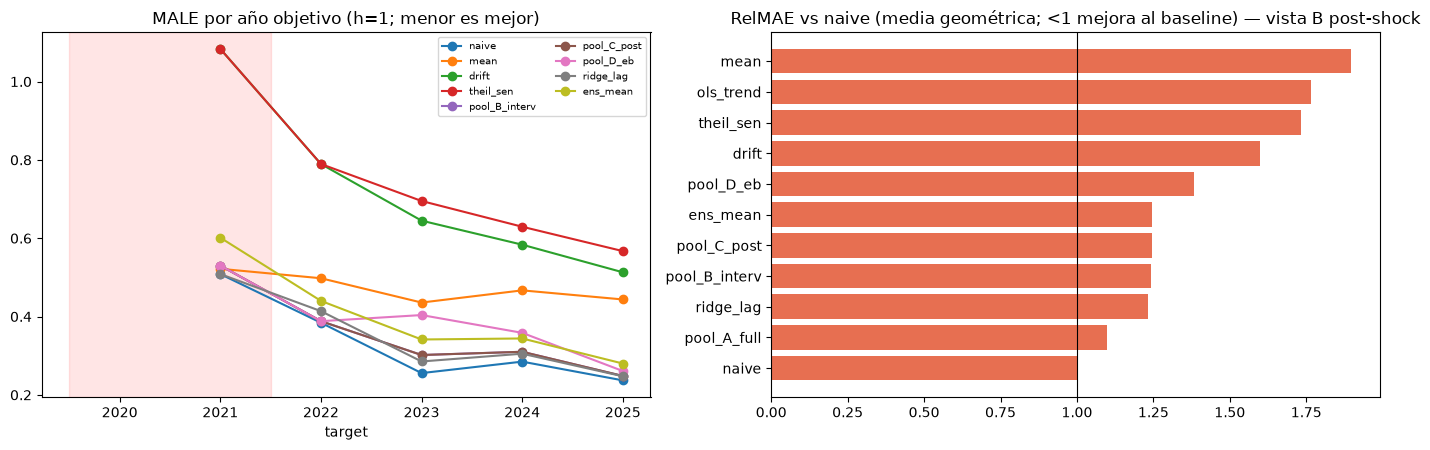

In [13]:
# Módulo 11b — Selección anidada
def choose_champion(inner: pd.DataFrame, cfg: Config) -> tuple[str, str, pd.Series]:
    if inner.empty:
        return "naive", "sin evidencia interna → baseline", pd.Series(dtype=float)
    male = inner.groupby("model")["le"].mean()
    champ = male.idxmin()
    if champ != "naive" and male[champ] > male["naive"] * (1 - cfg.selection_margin):
        return "naive", f"{champ} no mejora >{cfg.selection_margin:.0%} a naive → parsimonia", male
    return champ, "menor MALE interno", male


def nested_selection(sc: pd.DataFrame, cfg: Config, variant: str, h: int = 1, outer_targets: Optional[Sequence[int]] = None):
    outer_targets = outer_targets or [t for t in YEARS if t >= min(cfg.recovery_years) + 1]     # 2023, 2024, 2025
    base = sc[(sc["h"] == h) & ~sc["is_break_target"]]
    choices, outer = [], []
    for cyc in sorted(base["cycle"].dropna().unique()):
        for T in outer_targets:
            inner = base[(base["cycle"] == cyc) & (base["target"] < T)]
            if variant == "post_shock":
                inner = inner[inner["target_phase"] != "SHOCK"]
            champ, why, male = choose_champion(inner, cfg)
            top2 = list(male.nsmallest(2).index) if len(male) >= 2 else ["naive"]
            choices.append({"variante": variant, "ciclo": cyc, "objetivo_T": T, "campeon": champ, "motivo": why, "top2": "+".join(top2),
                            "n_folds_internos": inner["target"].nunique(), **{f"MALE_{k}": v for k, v in male.items()}})
            cur = base[(base["cycle"] == cyc) & (base["target"] == T)]
            sel = cur[cur["model"] == champ].assign(model=f"selected[{variant}]")
            outer.append(sel)
            comp = cur[cur["model"].isin(top2)]
            if len(comp):
                m = comp.assign(l=np.log1p(comp["y_pred"].clip(lower=0))).groupby("series_id")["l"].mean()
                e = cur[cur["model"] == "naive"].set_index("series_id").loc[m.index].copy()
                e["y_pred"] = np.expm1(m).clip(lower=0)
                e["model"] = f"ens_top2[{variant}]"
                outer.append(e.reset_index())
    out = pd.concat(outer, ignore_index=True)
    ref = base[base["target"].isin(outer_targets) & base["model"].isin(["naive", "theil_sen", "pool_B_interv", "pool_D_eb", "ens_mean"])]
    return pd.DataFrame(choices), score_rows(pd.concat([out.drop(columns=[c for c in out.columns if c in ("e", "ae", "smape", "le", "mase")], errors="ignore"), ref.drop(columns=[c for c in ref.columns if c in ("e", "ae", "smape", "le", "mase")], errors="ignore")], ignore_index=True))


NESTED_CHOICES, NESTED_OUT = [], []
for var in ["todos_los_objetivos", "post_shock"]:
    ch, ou = nested_selection(SC, CFG, "post_shock" if var == "post_shock" else "todos")
    NESTED_CHOICES.append(ch)
    NESTED_OUT.append(ou.assign(variante_sel=var))
NESTED_CHOICES = pd.concat(NESTED_CHOICES, ignore_index=True)
NESTED_OUT = pd.concat(NESTED_OUT, ignore_index=True)
save_table(NESTED_CHOICES, "models", "nested_selection_choices.csv")
NESTED_EVAL = pd.concat([agg_metrics(NESTED_OUT[NESTED_OUT["variante_sel"] == v], ["h", "model"]).assign(variante_sel=v) for v in NESTED_OUT["variante_sel"].unique()], ignore_index=True)
save_table(NESTED_EVAL, "models", "nested_outer_evaluation.csv")
NESTED_BYT = agg_metrics(NESTED_OUT[NESTED_OUT["model"].str.startswith("selected")], ["variante_sel", "target", "model"])
save_table(NESTED_BYT, "models", "nested_outer_by_target.csv")
print("\nCampeones anidados por ciclo y objetivo:")
print(NESTED_CHOICES[["variante", "ciclo", "objetivo_T", "campeon", "top2", "n_folds_internos"]].to_string(index=False))
print("\nEvaluación EXTERNA (objetivos 2023-2025, h=1) — selección anidada vs. modelos fijos:")
print(NESTED_EVAL[["variante_sel", "model", "n", "MALE", "RelMAE_vs_naive", "WAPE_%", "MASE_mediana"]].round(4).to_string(index=False))

# --- fold final reservado (HOLDOUT): evaluación con la elección hecha SOLO con objetivos < HOLDOUT ---
FINAL_HOLD = NESTED_OUT[(NESTED_OUT["target"] == HOLDOUT)]
FINAL_HOLD_EVAL = pd.concat([agg_metrics(FINAL_HOLD[FINAL_HOLD["variante_sel"] == v], ["h", "model"]).assign(variante_sel=v) for v in FINAL_HOLD["variante_sel"].unique()], ignore_index=True)
save_table(FINAL_HOLD_EVAL, "models", "final_holdout_evaluation.csv")
print(f"\nFOLD FINAL RESERVADO (objetivo {HOLDOUT}; el modelo elegido nunca vio ese objetivo al seleccionarse):")
print(FINAL_HOLD_EVAL[["variante_sel", "model", "n", "MALE", "RelMAE_vs_naive", "WAPE_%"]].round(4).to_string(index=False))

# --- significancia de la elección anidada vs naive (pool de objetivos externos) ---
NESTED_SIG = []
for v in NESTED_OUT["variante_sel"].unique():
    d = NESTED_OUT[NESTED_OUT["variante_sel"] == v]
    for m in [x for x in d["model"].unique() if x != "naive"]:
        NESTED_SIG.append({"variante_sel": v, "modelo": m, **paired_boot_vs(d, m, "naive", "le", CFG.n_boot, CFG.seed)})
NESTED_SIG = pd.DataFrame(NESTED_SIG)
save_table(NESTED_SIG, "models", "nested_significance_vs_naive.csv")
print("\nSignificancia de lo elegido vs naive (Δ MALE, IC95% por municipio):")
print(NESTED_SIG.round(4).to_string(index=False))

# --- gráficos ---
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
t1 = MET_TARGET[MET_TARGET["h"] == 1].pivot(index="target", columns="model", values="MALE")
t1[[c for c in ["naive", "mean", "drift", "theil_sen", "pool_B_interv", "pool_C_post", "pool_D_eb", "ridge_lag", "ens_mean"] if c in t1]].plot(ax=ax[0], marker="o")
ax[0].axvspan(min(CFG.shock_years) - .5, max(CFG.shock_years) + .5, color="red", alpha=.10); ax[0].set_title("MALE por año objetivo (h=1; menor es mejor)"); ax[0].legend(fontsize=7, ncol=2)
v = MET_VIEW[(MET_VIEW["vista"].str.startswith("B_post")) & (MET_VIEW["h"] == 1)].sort_values("RelMAE_vs_naive")
ax[1].barh(v["model"], v["RelMAE_vs_naive"], color=["#2a9d8f" if x < 1 else "#e76f51" for x in v["RelMAE_vs_naive"]]); ax[1].axvline(1, color="k", lw=.8)
ax[1].set_title("RelMAE vs naive (media geométrica; <1 mejora al baseline) — vista B post-shock")
plt.tight_layout(); plt.savefig(OUT["forecasting"] / "backtest_comparison.png", dpi=130); plt.show()

### Módulo 11c — Robustez: ¿la ventaja de *naive* es agronómica o un artefacto de valores congelados?
La fuente repite el mismo valor año tras año en muchas series (292 de 1 412 tienen ≥3 años idénticos; la proporción de transiciones sin cambio crece de 18.9 % a 34.1 % entre 2020 y 2025).
*Naive* acierta esas series **exactamente**. Para no sobre-atribuir mérito a *naive* se reevalúa separando, **con información conocida en el origen** (sin fuga), las series cuya *última* transición observada fue idéntica («congeladas ex-ante») del resto.
Es un diagnóstico de interpretación, **no** un criterio de selección.

In [14]:
# Módulo 11c — Congelados ex-ante
_gp = GP.to_numpy()
_r = GP.index.get_indexer(HEADLINE["series_id"])
_c = GP.columns.get_indexer(HEADLINE["origin"])
_prev = np.where(_c > 0, _gp[_r, np.maximum(_c - 1, 0)], np.nan)
_cur = _gp[_r, _c]
FROZEN_EXANTE = (_cur == _prev) & (_cur > 0)
H1F = HEADLINE[HEADLINE["h"] == 1].assign(congelada_ex_ante=FROZEN_EXANTE[HEADLINE["h"].to_numpy() == 1])
H1F["congelada_ex_ante"] = np.where(H1F["congelada_ex_ante"], "última transición idéntica", "última transición con cambio")
MET_FROZEN = agg_metrics(H1F, ["congelada_ex_ante", "model"])
save_table(MET_FROZEN, "forecasting", "metrics_by_frozen_status.csv")
SHARE_FROZEN = H1F[H1F["model"] == "naive"]["congelada_ex_ante"].value_counts(normalize=True)
print("Proporción de filas (h=1) por estado ex-ante:", SHARE_FROZEN.round(3).to_dict())
print(MET_FROZEN[["congelada_ex_ante", "model", "n", "MALE", "RelMAE_vs_naive", "WAPE_%"]].round(4).sort_values(["congelada_ex_ante", "MALE"]).to_string(index=False))
FROZEN_SIG = []
for st in H1F["congelada_ex_ante"].unique():
    d = H1F[H1F["congelada_ex_ante"] == st]
    for m in ["pool_A_full", "pool_B_interv", "pool_C_post", "pool_D_eb", "ridge_lag", "ens_mean"]:
        FROZEN_SIG.append({"estado": st, "modelo": m, **paired_boot_vs(d, m, "naive", "le", CFG.n_boot, CFG.seed)})
FROZEN_SIG = pd.DataFrame(FROZEN_SIG)
FROZEN_SIG["supera_a_naive"] = FROZEN_SIG["hi"] < 0
save_table(FROZEN_SIG, "forecasting", "significance_by_frozen_status.csv")
print("\nΔ MALE pareado vs naive por estado ex-ante (IC95 % por municipio; <0 = mejora):")
print(FROZEN_SIG.round(4).to_string(index=False))

Proporción de filas (h=1) por estado ex-ante: {'última transición con cambio': 0.776, 'última transición idéntica': 0.224}
           congelada_ex_ante         model          n   MALE  RelMAE_vs_naive  WAPE_%
última transición con cambio         naive 3,675.0000 0.3473           1.0000  7.9632
última transición con cambio   pool_A_full 3,675.0000 0.3590           1.0664  9.0238
última transición con cambio     ridge_lag 3,675.0000 0.3643           1.1342  9.6311
última transición con cambio pool_B_interv 3,675.0000 0.3700           1.1532  9.7606
última transición con cambio   pool_C_post 3,675.0000 0.3701           1.1568  9.8192
última transición con cambio     pool_D_eb 3,675.0000 0.4187           1.3219 11.7106
última transición con cambio      ens_mean 3,675.0000 0.4198           1.1817  9.1155
última transición con cambio          mean 3,675.0000 0.4966           1.6017 12.3348
última transición con cambio         drift 3,675.0000 0.7568           1.5055 11.0006
última transición

## Módulos 12-13 — Escenarios y Forecast (con bandas de incertidumbre)
**Principios.**
1. El **pronóstico central** usa el modelo que la selección anidada (módulo 11) respalda con evidencia por ciclo. Si ningún modelo supera a *naive* con margen, el central **es naive** (parsimonia); no se «adorna» con un modelo que el backtest no justifica.
2. Los **escenarios** (Normal / Histórico / Estrés) **no** son pronósticos competidores: son *supuestos condicionales* sobre el régimen de crecimiento, y se rotulan como tales. Su función es acotar la sensibilidad, no predecir.
3. La **incertidumbre** del central se cuantifica con residuos **fuera de muestra** del backtest (cuantiles empíricos por horizonte y ciclo, en escala log1p) y se valida con cobertura en el fold final reservado usando SOLO residuos previos a ese fold.
4. Marcadores: 2024-2025 son cifras provisionales (nota de la fuente) y 2022 es un quiebre de definición en transitorios; el pronóstico parte de 2025 y lo declara.
* **Escenario NORMAL** — régimen estructural post-shock: crecimiento por estrato con prioridad a años POST (Modelo C).
* **Escenario HISTÓRICO** — dinámica completa 2019-2025 sin intervención (Modelo A): «qué pasa si el pasado, shock incluido, se repite en promedio».
* **Escenario ESTRÉS** — el shock hipotético 2020-21 se repite (`stress_duration` años) con magnitud anclada en dos evidencias del propio dato: (i) *replay* del crecimiento medio observado por estrato en los años SHOCK y (ii) el cuantil `stress_quantile` de las medias anuales de crecimiento del estrato (≈ «el peor año observado»; con ~6 transiciones equivale prácticamente al mínimo). `worse_of` toma el peor de ambos y **nunca es mejor que Normal**. Magnitud = supuesto documentado, no predicción; `stress_scale` la escala.

> **PARCHE v5.1.** (1) `Config.central_model`: `"auto"` = campeón del backtest (naive); cualquier otro nombre fuerza ese modelo como pronóstico central y lo rotula en tablas y gráficos junto a la referencia de persistencia. (2) `residual_bank` excluye las filas cuyo origen u objetivo cae en 2020-21 (`Config.interval_exclude_shock`); antes el residuo del shock y su rebote inflaban la cola superior de las bandas (p. ej. plátano PI95 superior +125 %).

In [15]:
# Módulo 12 — Motor de pronóstico y campeón de producción
from dataclasses import replace as dc_replace

ORIGIN = LAST_YEAR
FC_YEARS = {h: ORIGIN + h for h in CFG.horizons}
CTX_F = ctx_for(ORIGIN, CFG)
assert CTX_F.years.max() == ORIGIN, "El contexto de pronóstico no puede contener años posteriores al origen"


def predict_named(name: str, c: Ctx, h: int):
    """Pronóstico de un modelo por nombre. El ensemble fijo usa solo componentes que soportan el horizonte."""
    if name == "ens_mean":
        comps = [k for k in ENS_COMPONENTS if not (k in MODEL_H_SUPPORT and not MODEL_H_SUPPORT[k](h))]
        preds = np.column_stack([ALL_MODELS[k](c, h)[0] for k in comps])
        with np.errstate(all="ignore"):
            p = np.expm1(np.nanmean(np.log1p(np.clip(preds, 0, None)), axis=1))
        return p, np.array([len(comps) < len(ENS_COMPONENTS)] * len(p))
    return ALL_MODELS[name](c, h)


# --- campeón de producción por ciclo y horizonte: se elige con TODA la evidencia disponible (folds con objetivo ≤ origen) ---
BASE_ROWS = SC[~SC["is_break_target"] & (SC["origin"] < ORIGIN)]
CHAMP_ROWS = []
CHAMPIONS: dict[tuple[str, int], str] = {}
for h in CFG.horizons:
    for cyc in sorted(META["cycle"].dropna().unique()):
        inner = BASE_ROWS[(BASE_ROWS["h"] == h) & (BASE_ROWS["cycle"] == cyc) & (BASE_ROWS["target_phase"] != "SHOCK")]
        champ, why, male = choose_champion(inner, CFG)
        CHAMPIONS[(cyc, h)] = champ
        CHAMP_ROWS.append({"ciclo": cyc, "h": h, "campeon": champ, "motivo": why, "n_filas_evidencia": len(inner), "folds_objetivo": "+".join(map(str, sorted(inner["target"].unique()))),
                           **{f"MALE_{k}": v for k, v in male.items()}})
# --- PARCHE v5.1: pronóstico central explícito -------------------------------------------------------------------
# El campeón del backtest sigue calculándose (CHAMPIONS_BACKTEST). Si CFG.central_model != "auto", el central pasa a ser ese
# modelo POR DECISIÓN DEL USUARIO: el backtest no lo eligió, y así queda rotulado en la tabla de campeones, los gráficos y el resumen.
CHAMPIONS_BACKTEST = dict(CHAMPIONS)
if CFG.central_model != "auto":
    _valid = set(ALL_MODELS) | {"ens_mean"}
    if CFG.central_model not in _valid:
        raise DataValidationError("BAD_CENTRAL_MODEL", f"central_model={CFG.central_model!r} no existe. Opciones: 'auto' o {sorted(_valid)}")
    for _k in list(CHAMPIONS):
        CHAMPIONS[_k] = CFG.central_model
    CHAMP_ROWS = [{**r, "campeon_backtest": r["campeon"], "campeon": CFG.central_model,
                   "motivo": f"FORZADO por Config.central_model (el backtest respaldaba: {r['campeon']})"} for r in CHAMP_ROWS]
    LOG.warning(f"Pronóstico central FORZADO a '{CFG.central_model}'. El backtest respaldaba: {sorted(set(CHAMPIONS_BACKTEST.values()))}. Se rotula en tablas y gráficos.")
CHAMP_TABLE = pd.DataFrame(CHAMP_ROWS)
save_table(CHAMP_TABLE, "models", "production_champion_by_cycle.csv")
print("Campeón de producción por ciclo/horizonte (evidencia: folds fuera de muestra, sin objetivos SHOCK ni quiebre de definición):")
print(CHAMP_TABLE[["ciclo", "h", "campeon", "motivo", "folds_objetivo"]].to_string(index=False))

17:34:24 | WARNING | Pronóstico central FORZADO a 'pool_A_full'. El backtest respaldaba: ['naive']. Se rotula en tablas y gráficos.
Campeón de producción por ciclo/horizonte (evidencia: folds fuera de muestra, sin objetivos SHOCK ni quiebre de definición):
      ciclo  h     campeon                                                           motivo      folds_objetivo
 Permanente  1 pool_A_full FORZADO por Config.central_model (el backtest respaldaba: naive) 2022+2023+2024+2025
Transitorio  1 pool_A_full FORZADO por Config.central_model (el backtest respaldaba: naive)      2023+2024+2025
 Permanente  2 pool_A_full FORZADO por Config.central_model (el backtest respaldaba: naive) 2022+2023+2024+2025
Transitorio  2 pool_A_full FORZADO por Config.central_model (el backtest respaldaba: naive)      2023+2024+2025


In [16]:
# Módulo 12b — Regímenes de crecimiento para escenarios
def _stratum_stat(G: np.ndarray, strat: np.ndarray, cycle: np.ndarray, col_mask: np.ndarray, fn, min_series: int = 5) -> np.ndarray:
    """Estadístico por estrato (fallback a ciclo, luego global) aplicado al vector de MEDIAS ANUALES del estrato en las columnas marcadas.
    Se usan medias de estrato (no colas de series individuales): un estrés sistémico mueve el nivel del estrato, no lleva a cada serie a su peor año."""
    n = G.shape[0]
    out = np.full(n, np.nan)

    def annual_means(idx):
        Gi = G[idx][:, col_mask] if col_mask.any() else np.empty((idx.sum(), 0))
        if Gi.shape[1] == 0:
            return np.array([])
        cnt = np.isfinite(Gi).sum(0)
        with np.errstate(all="ignore"):
            mu = np.nanmean(np.where(np.isfinite(Gi), Gi, np.nan), axis=0)
        return mu[cnt >= min_series]

    glob_v = annual_means(np.ones(n, bool))
    glob = fn(glob_v) if len(glob_v) else 0.0
    for key_arr in (strat, cycle):
        for k in pd.unique(key_arr):
            idx = key_arr == k
            v = annual_means(idx)
            if len(v):
                out[idx & np.isnan(out)] = fn(v)
    out[np.isnan(out)] = glob
    return out


def scenario_growth(c: Ctx, scenario: str) -> tuple[np.ndarray, np.ndarray]:
    """Devuelve (g_anual_por_serie, g_estrés_por_serie o NaN). g está en log-crecimiento anual."""
    cfg = c.cfg
    if scenario == "NORMAL":
        mu, _, _ = pooled_core(c, cfg.phase_weights_post, cfg.phase_weights_full)
        return mu, np.full(len(mu), np.nan)
    if scenario == "HISTORICO":
        mu, _, _ = pooled_core(c, cfg.phase_weights_full, cfg.phase_weights_full)
        return mu, np.full(len(mu), np.nan)
    if scenario == "ESTRES":
        mu_n, _, _ = pooled_core(c, cfg.phase_weights_post, cfg.phase_weights_full)
        G, yrs_t = growth_matrix(c, "P")
        strat = strata_labels(c, G)
        shock_cols = np.array([phase_of_year(int(y), cfg) == "SHOCK" for y in yrs_t])
        all_cols = np.ones(len(yrs_t), bool)
        replay = _stratum_stat(G, strat, c.cycle, shock_cols, np.mean)
        quant = _stratum_stat(G, strat, c.cycle, all_cols, lambda v: np.quantile(v, cfg.stress_quantile))   # peor año observado (cuantil bajo de las medias anuales del estrato)
        cand = {"replay": replay, "quantile": quant, "worse_of": np.minimum(replay, quant)}[cfg.stress_mode]
        g_s = np.minimum(mu_n, cfg.stress_scale * cand)          # el estrés nunca es mejor que el escenario Normal
        return mu_n, g_s
    raise DataValidationError("BAD_SCENARIO", f"escenario desconocido: {scenario}")


def scenario_forecast(c: Ctx, scenario: str, h: int) -> np.ndarray:
    g, g_s = scenario_growth(c, scenario)
    last = c.last
    if scenario == "ESTRES":
        d = c.cfg.stress_duration
        H = min(h, d) * g_s + max(0, h - d) * g
    else:
        H = h * g
    return np.where(np.isnan(last), np.nan, np.where(last > 0, last * np.exp(H), 0.0))

In [17]:
# Módulo 13 — Intervalos empíricos por residuos fuera de muestra
SIZE_EDGES = np.array([10.0, 100.0, 1e3, 1e4, 1e5])          # t: <10, 10-100, 100-1e3, 1e3-1e4, 1e4-1e5, >1e5


def size_bin(x: np.ndarray) -> np.ndarray:
    """Clase de tamaño del pronóstico. Los errores relativos dependen de la escala (una parcela de 3 t no se comporta como un ingenio de 1 Mt)."""
    return np.digitize(np.nan_to_num(np.asarray(x, float), nan=0.0), SIZE_EDGES)


def _pick_resid(bank: pd.DataFrame, cyc, b, min_n: int = 30) -> np.ndarray:
    """Residuos por (ciclo, tamaño); si hay < min_n se ensancha a (tamaño), luego (ciclo), luego todo (nunca vacío si el banco no lo está)."""
    for m in [(bank["cycle"] == cyc) & (bank["bin"] == b), (bank["bin"] == b), (bank["cycle"] == cyc), np.ones(len(bank), bool)]:
        r = bank.loc[m, "r"].to_numpy()
        if len(r) >= min_n:
            return r
    return bank["r"].to_numpy()


def residual_bank(sc: pd.DataFrame, model: str, h: int, upto_origin: int, exclude_shock: Optional[bool] = None) -> pd.DataFrame:
    """Residuos log1p (y − ŷ) del backtest para un modelo/horizonte usando SOLO folds con origen < upto_origin+1 y objetivo ≤ upto_origin (sin fuga)."""
    d = sc[(sc["model"] == model) & (sc["h"] == h) & (~sc["is_break_target"]) & (sc["target"] <= upto_origin)].copy()
    if CFG.interval_exclude_shock if exclude_shock is None else exclude_shock:      # PARCHE v5.1: residuos que cruzan el shock (objetivo 2021, rebote desde origen 2020-21) inflaban la cola superior
        d = d[~d["target"].isin(CFG.shock_years) & ~d["origin"].isin(CFG.shock_years)]
    d["r"] = np.log1p(d["y_true"].clip(lower=0)) - np.log1p(d["y_pred"].clip(lower=0))
    d["bin"] = size_bin(d["y_pred"].to_numpy())
    return d[["cycle", "target", "series_id", "r", "bin"]]


def series_interval(pred: np.ndarray, cycle: np.ndarray, bank: pd.DataFrame, level: float) -> tuple[np.ndarray, np.ndarray]:
    lo, hi = np.full(len(pred), np.nan), np.full(len(pred), np.nan)
    a = (1 - level) / 2
    if bank.empty:
        return lo, hi
    bins = size_bin(pred)
    for cyc in pd.unique(cycle):
        for b in np.unique(bins[cycle == cyc]):
            r = _pick_resid(bank, cyc, b)
            ql, qh = np.quantile(r, [a, 1 - a])
            m = (cycle == cyc) & (bins == b) & ~np.isnan(pred)
            lo[m] = np.expm1(np.log1p(np.clip(pred[m], 0, None)) + ql).clip(min=0)
            hi[m] = np.expm1(np.log1p(np.clip(pred[m], 0, None)) + qh)
    return lo, hi


def simulate_aggregate(pred: np.ndarray, cycle: np.ndarray, bank: pd.DataFrame, groups: dict[str, np.ndarray], B: int, seed: int) -> pd.DataFrame:
    """Simulación de agregados: componente COMÚN (mediana del fold sorteado, compartida por ciclos) + idiosincrático (residuo − mediana del fold, remuestreado).
    Preserva la correlación entre series que un remuestreo independiente ignoraría; el idiosincrático se remuestrea dentro de la misma clase de tamaño y ciclo. Con pocos folds es una aproximación: se declara como limitación."""
    rng = np.random.default_rng(seed)
    folds = sorted(bank["target"].unique())
    if not folds:
        return pd.DataFrame()
    med = bank.groupby(["cycle", "target"])["r"].median()
    bank = bank.assign(ri=bank["r"] - bank.groupby(["cycle", "target"])["r"].transform("median"))
    bins = size_bin(pred)
    lp = np.log1p(np.clip(pred, 0, None))
    pools = {}
    for cyc in pd.unique(cycle):
        for b in np.unique(bins[cycle == cyc]):
            for m in [(bank["cycle"] == cyc) & (bank["bin"] == b), (bank["bin"] == b), (bank["cycle"] == cyc), np.ones(len(bank), bool)]:
                r = bank.loc[m, "ri"].to_numpy()
                if len(r) >= 30:
                    break
            pools[(cyc, b)] = r if len(r) else np.zeros(1)
    idx_cells = {key: np.where((cycle == key[0]) & (bins == key[1]) & ~np.isnan(pred))[0] for key in pools}
    sims = {k: np.empty(B) for k in groups}
    for b_ in range(B):
        f = folds[rng.integers(len(folds))]
        eps = np.zeros(len(pred))
        for (cyc, b), idx in idx_cells.items():
            if len(idx):
                eps[idx] = med.get((cyc, f), 0.0) + rng.choice(pools[(cyc, b)], size=len(idx), replace=True)
        y = np.expm1(lp + eps).clip(min=0)
        for k, m in groups.items():
            sims[k][b_] = np.nansum(y[m])
    rows = []
    for k in groups:
        row = {"nivel": k}
        for lv in CFG.pi_levels:
            a = (1 - lv) / 2
            row[f"lo{int(lv * 100)}"], row[f"hi{int(lv * 100)}"] = np.quantile(sims[k], [a, 1 - a])
        rows.append(row)
    return pd.DataFrame(rows)

In [18]:
# Módulo 13b — Ejecución del pronóstico
elig_f = ~np.isnan(CTX_F.last)
groups_f = {"TOTAL": elig_f, "SIN_CAÑA": elig_f & (META["crop"].to_numpy() != "Caña"), "Permanente": elig_f & (META["cycle"].to_numpy() == "Permanente"),
            "Transitorio": elig_f & (META["cycle"].to_numpy() == "Transitorio")}
FC_SERIES, FC_AGG, EXCLUDED = [], [], []
excl_mask = ~elig_f
EXCLUDED = STATUS.loc[GP.index[excl_mask], ["n_obs", "first_year", "last_year", "tier"]].reset_index().assign(
    motivo=f"sin dato en {ORIGIN}: no se extrapola una serie que ya salió (no hay «años imaginarios»)")
save_table(EXCLUDED, "forecasting", "forecast_excluded_series.csv")

for h in CFG.horizons:
    T = FC_YEARS[h]
    pred_c = np.full(len(GP), np.nan)
    fb_c = np.zeros(len(GP), bool)
    champ_name = np.empty(len(GP), dtype=object)
    for cyc in ["Permanente", "Transitorio"]:
        m = (META["cycle"].to_numpy() == cyc)
        name = CHAMPIONS.get((cyc, h), "naive")
        p, fb = predict_named(name, CTX_F, h)
        pred_c[m], fb_c[m], champ_name[m] = p[m], fb[m], name
    pred_c = np.where(elig_f, pred_c, np.nan)
    bank = residual_bank(SC, CHAMPIONS.get(("Permanente", h), "naive"), h, ORIGIN)
    # el banco de residuos debe corresponder al modelo campeón de cada ciclo
    bank = pd.concat([residual_bank(SC, CHAMPIONS.get((cyc, h), "naive"), h, ORIGIN).query("cycle == @cyc") for cyc in ["Permanente", "Transitorio"]], ignore_index=True)
    lo80, hi80 = series_interval(pred_c, META["cycle"].to_numpy(dtype=object), bank, 0.80)
    lo95, hi95 = series_interval(pred_c, META["cycle"].to_numpy(dtype=object), bank, 0.95)
    sc_pred = {s: scenario_forecast(CTX_F, s, h) for s in ["NORMAL", "HISTORICO", "ESTRES"]}
    df = pd.DataFrame({"series_id": GP.index, "h": h, "target_year": T, "last_obs_t": CTX_F.last, "n_obs": CTX_F.n_obs, "modelo_central": champ_name, "pron_central_t": pred_c,
                       "pi80_lo": lo80, "pi80_hi": hi80, "pi95_lo": lo95, "pi95_hi": hi95, "esc_normal_t": sc_pred["NORMAL"], "esc_historico_t": sc_pred["HISTORICO"], "esc_estres_t": sc_pred["ESTRES"],
                       "fallback_central": fb_c, "origen_provisional": ORIGIN in CFG.provisional_years}).join(META[["muni_code", "crop", "cycle", "group"]], on="series_id")
    df = df[elig_f].reset_index(drop=True)
    FC_SERIES.append(df)
    # agregados con incertidumbre simulada
    agg_sim = simulate_aggregate(pred_c, META["cycle"].to_numpy(dtype=object), bank, groups_f, CFG.n_boot, CFG.seed + h)
    for k, m in groups_f.items():
        row = {"nivel": k, "h": h, "target_year": T, "observado_origen_t": np.nansum(CTX_F.last[m]), "pron_central_t": np.nansum(pred_c[m])}
        for s, v in sc_pred.items():
            row[f"esc_{s.lower()}_t"] = np.nansum(v[m])
        if not agg_sim.empty:
            row.update(agg_sim[agg_sim["nivel"] == k].drop(columns="nivel").iloc[0].to_dict())
        FC_AGG.append(row)
FC_SERIES = pd.concat(FC_SERIES, ignore_index=True)
FC_AGG = pd.DataFrame(FC_AGG)
save_table(FC_SERIES, "forecasting", "forecast_series_level.csv")
save_table(FC_AGG, "scenarios", "scenarios_aggregate.csv")
save_table(META.reset_index(), "forecasting", "meta_series.csv")   # AUD-V5-002: metadatos de serie (muni nombre/ciclo/grupo) para la app
save_table(PANEL, "temporal", "panel_anual.csv")                   # AUD-V5-002: panel anual P/AC/AS por serie x ano para historicos en la app
print(f"\nPronóstico desde origen {ORIGIN}: {FC_SERIES['series_id'].nunique()} series pronosticadas | {len(EXCLUDED)} excluidas por no tener dato en {ORIGIN}")
print(FC_AGG.round(0).to_string(index=False))

# --- resumen de supuestos de escenarios (auditable) ---
_g_n, _ = scenario_growth(CTX_F, "NORMAL"); _g_h, _ = scenario_growth(CTX_F, "HISTORICO"); _, _g_s = scenario_growth(CTX_F, "ESTRES")
ASSUME = pd.DataFrame({"ciclo": CTX_F.cycle, "g_normal": _g_n, "g_historico": _g_h, "g_estres": _g_s}).groupby("ciclo").agg(["mean", "min", "max"]).round(4)
ASSUME.columns = ["_".join(c) for c in ASSUME.columns]
save_table(ASSUME.reset_index(), "scenarios", "scenario_assumptions_log_growth.csv")
print("\nSupuestos de log-crecimiento anual por ciclo (min/media/max sobre series):")
print(ASSUME.to_string())

C:\Users\Usuario\AppData\Local\Temp\ipykernel_26004\1111538216.py:14: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(np.where(np.isfinite(Gi), Gi, np.nan), axis=0)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_26004\1111538216.py:14: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(np.where(np.isfinite(Gi), Gi, np.nan), axis=0)



Pronóstico desde origen 2025: 1145 series pronosticadas | 267 excluidas por no tener dato en 2025
      nivel  h  target_year  observado_origen_t  pron_central_t    esc_normal_t  esc_historico_t    esc_estres_t            lo80            hi80            lo95            hi95
      TOTAL  1         2026     28,552,711.0000 28,948,522.0000 29,422,571.0000  28,948,522.0000 26,886,964.0000 29,260,380.0000 31,453,211.0000 28,917,352.0000 33,705,468.0000
   SIN_CAÑA  1         2026      1,420,565.0000  1,439,450.0000  1,470,850.0000   1,439,450.0000  1,329,766.0000  1,447,249.0000  1,564,737.0000  1,422,298.0000  1,606,917.0000
 Permanente  1         2026     28,214,569.0000 28,614,444.0000 29,075,816.0000  28,614,444.0000 26,582,941.0000 28,861,329.0000 31,100,573.0000 28,524,864.0000 33,312,478.0000
Transitorio  1         2026        338,142.0000    334,078.0000    346,755.0000     334,078.0000    304,023.0000    341,486.0000    420,160.0000    326,313.0000    443,904.0000
      TOTAL  2  

C:\Users\Usuario\AppData\Local\Temp\ipykernel_26004\1111538216.py:14: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(np.where(np.isfinite(Gi), Gi, np.nan), axis=0)


In [19]:
# Módulo 13c — Calibración de intervalos (validación pseudo-futura con el fold final reservado)
def coverage_check(sc: pd.DataFrame, h: int, target: int) -> pd.DataFrame:
    """Construye bandas con residuos de objetivos < `target` y mide cobertura en `target` (nunca ve `target`)."""
    rows = []
    for cyc in ["Permanente", "Transitorio"]:
        name = CHAMPIONS.get((cyc, h), "naive")
        bank = residual_bank(sc, name, h, target - 1)
        bank = bank[bank["cycle"] == cyc]
        cur = sc[(sc["model"] == name) & (sc["h"] == h) & (sc["target"] == target) & (sc["cycle"] == cyc) & (~sc["is_break_target"])]
        if cur.empty or bank.empty:
            continue
        for lv in CFG.pi_levels:
            lo, hi = series_interval(cur["y_pred"].to_numpy(), np.array([cyc] * len(cur), dtype=object), bank, lv)
            cov = float(np.mean((cur["y_true"].to_numpy() >= lo) & (cur["y_true"].to_numpy() <= hi)))
            rows.append({"ciclo": cyc, "h": h, "objetivo": target, "nivel_nominal": lv, "cobertura_empirica": cov, "n": len(cur), "modelo": name, "n_residuos_previos": len(bank)})
    return pd.DataFrame(rows)


CALIB = pd.concat([coverage_check(SC, 1, t) for t in [2024, 2025]] + [coverage_check(SC, 2, t) for t in [2024, 2025]], ignore_index=True)
save_table(CALIB, "forecasting", "interval_calibration.csv")
print("\nCalibración de intervalos por serie (bandas hechas SOLO con residuos previos al objetivo):")
print(CALIB.round(3).to_string(index=False))

# calibración del agregado en el fold final
_o = HOLDOUT - 1
_c = ctx_for(_o, CFG)
_e = ~np.isnan(_c.last) & ~np.isnan(GP[HOLDOUT].to_numpy())
_pred = np.full(len(GP), np.nan)
for cyc in ["Permanente", "Transitorio"]:
    m = META["cycle"].to_numpy() == cyc
    _p, _ = predict_named(CHAMPIONS.get((cyc, 1), "naive"), _c, 1)
    _pred[m] = _p[m]
_pred = np.where(_e, _pred, np.nan)
_bank = pd.concat([residual_bank(SC, CHAMPIONS.get((cyc, 1), "naive"), 1, HOLDOUT - 1).query("cycle == @cyc") for cyc in ["Permanente", "Transitorio"]], ignore_index=True)
_agg = simulate_aggregate(_pred, META["cycle"].to_numpy(dtype=object), _bank, {"TOTAL": _e, "SIN_CAÑA": _e & (META["crop"].to_numpy() != "Caña")}, CFG.n_boot, CFG.seed)
_act = {"TOTAL": np.nansum(np.where(_e, GP[HOLDOUT].to_numpy(), np.nan)), "SIN_CAÑA": np.nansum(np.where(_e & (META["crop"].to_numpy() != "Caña"), GP[HOLDOUT].to_numpy(), np.nan))}
CALIB_AGG = _agg.assign(real=lambda d: d["nivel"].map(_act), objetivo=HOLDOUT, pred_central=lambda d: d["nivel"].map({"TOTAL": np.nansum(_pred), "SIN_CAÑA": np.nansum(np.where(META["crop"].to_numpy() != "Caña", _pred, np.nan))}))
CALIB_AGG["dentro_95"] = (CALIB_AGG["real"] >= CALIB_AGG["lo95"]) & (CALIB_AGG["real"] <= CALIB_AGG["hi95"])
CALIB_AGG["dentro_80"] = (CALIB_AGG["real"] >= CALIB_AGG["lo80"]) & (CALIB_AGG["real"] <= CALIB_AGG["hi80"])
save_table(CALIB_AGG, "forecasting", "interval_calibration_aggregate.csv")
print("\nCalibración del agregado en el fold final (1 sola observación por nivel: evidencia débil, se declara):")
print(CALIB_AGG.round(0).to_string(index=False))


Calibración de intervalos por serie (bandas hechas SOLO con residuos previos al objetivo):
      ciclo  h  objetivo  nivel_nominal  cobertura_empirica   n      modelo  n_residuos_previos
 Permanente  1      2024         0.8000              0.7640 673 pool_A_full                 676
 Permanente  1      2024         0.9500              0.9080 673 pool_A_full                 676
Transitorio  1      2024         0.8000              0.7570 440 pool_A_full                 448
Transitorio  1      2024         0.9500              0.9000 440 pool_A_full                 448
 Permanente  1      2025         0.8000              0.8140 666 pool_A_full                1349
 Permanente  1      2025         0.9500              0.9560 666 pool_A_full                1349
Transitorio  1      2025         0.8000              0.7940 447 pool_A_full                 888
Transitorio  1      2025         0.9500              0.9530 447 pool_A_full                 888
 Permanente  2      2025         0.8000     

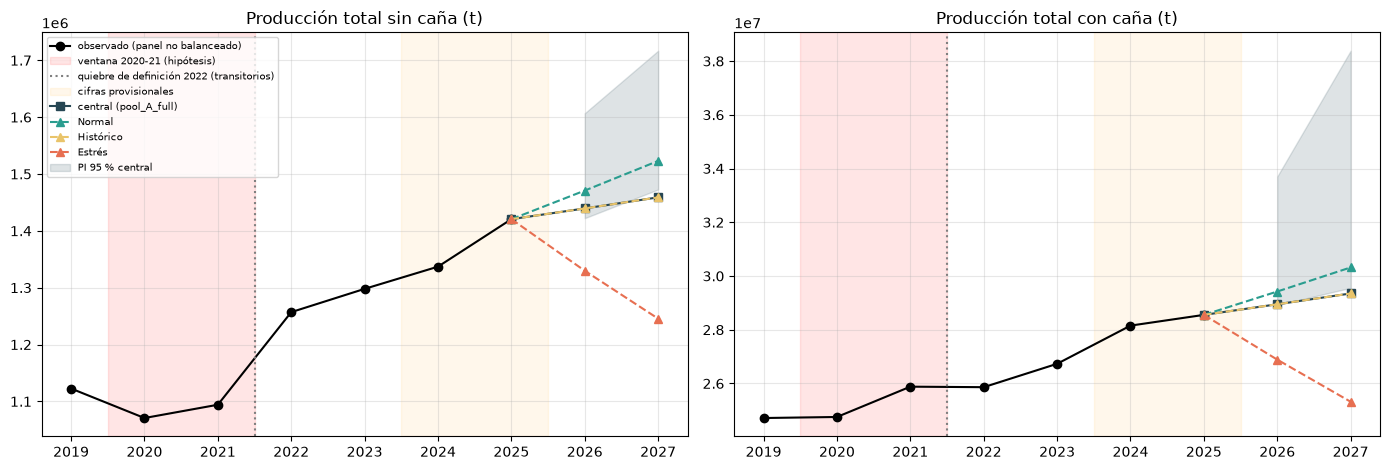

In [20]:
# Módulo 13d — Gráficos de escenarios
hist_tot = GP.sum(axis=0)
hist_nc = GP[META["crop"].to_numpy() != "Caña"].sum(axis=0)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, lvl, hist, ttl in [(axes[0], "SIN_CAÑA", hist_nc, "Producción total sin caña (t)"), (axes[1], "TOTAL", hist_tot, "Producción total con caña (t)")]:
    ax.plot(hist.index, hist.values, "-o", color="k", label="observado (panel no balanceado)")
    ax.axvspan(min(CFG.shock_years) - .5, max(CFG.shock_years) + .5, color="red", alpha=.10, label="ventana 2020-21 (hipótesis)")
    ax.axvline(CFG.definition_break_year - .5, color="gray", ls=":", label="quiebre de definición 2022 (transitorios)")
    ax.axvspan(min(CFG.provisional_years) - .5, ORIGIN + .5, color="orange", alpha=.08, label="cifras provisionales")
    d = FC_AGG[FC_AGG["nivel"] == lvl].sort_values("h")
    xs = [ORIGIN] + list(d["target_year"])
    ax.plot(xs, [d["observado_origen_t"].iloc[0]] + list(d["pron_central_t"]), "-s", color="#264653", label="central (campeón)" if CFG.central_model == "auto" else f"central ({CFG.central_model})")
    for col, colr, lab in [("esc_normal_t", "#2a9d8f", "Normal"), ("esc_historico_t", "#e9c46a", "Histórico"), ("esc_estres_t", "#e76f51", "Estrés")]:
        ax.plot(xs, [d["observado_origen_t"].iloc[0]] + list(d[col]), "--^", color=colr, label=lab)
    if "lo95" in d:
        ax.fill_between(d["target_year"], d["lo95"], d["hi95"], color="#264653", alpha=.15, label="PI 95 % central")
    ax.set_title(ttl); ax.grid(alpha=.3)
axes[0].legend(fontsize=7, loc="best")
plt.tight_layout(); plt.savefig(OUT["scenarios"] / "scenarios_forecast.png", dpi=130); plt.show()

## Módulo 14 — Análisis de sensibilidad
¿Cuánto depende el pronóstico de **cómo se trate 2020-21**? Tres ejes:
1. **Modelos A / B / C / D** (historia completa · intervención · prioridad post-shock · robusto/regularizado) frente a *naive*, a distintos niveles de agregación (total, sin caña, ciclo, grupo, cultivo).
2. **Parámetros del tratamiento** (con/sin exclusión del quiebre de definición, winsorización, pesos por fase).
3. **Desempeño en el backtest** de A-D por vista (¿cambia el ranking según se mire la historia completa, el post-shock o el shock?).
Métrica de dispersión: `spread_pct` = (máx − mín) / media entre modelos A-D — cuánto se mueve el pronóstico por decisiones de modelado y no por datos nuevos.

Sensibilidad A/B/C/D — diferencia % del pronóstico h=1 frente a naive (fila = nivel de agregación):
modelo                                                             naive  pool_A_full  pool_B_interv  pool_C_post  pool_D_eb
nivel                                                                                                                       
SIN_CAÑA                                                          0.0000       1.3300         4.0700       3.5400     5.5400
TOTAL                                                             0.0000       1.3900         2.2300       3.0500     2.4400
ciclo=Permanente                                                  0.0000       1.4200         2.2100       3.0500     2.3900
ciclo=Transitorio                                                 0.0000      -1.2000         4.1300       2.5500     6.4900
cultivo=Aguacate                                                  0.0000       2.1600         4.1500       3.9000     8.0000
cultivo=Banano           

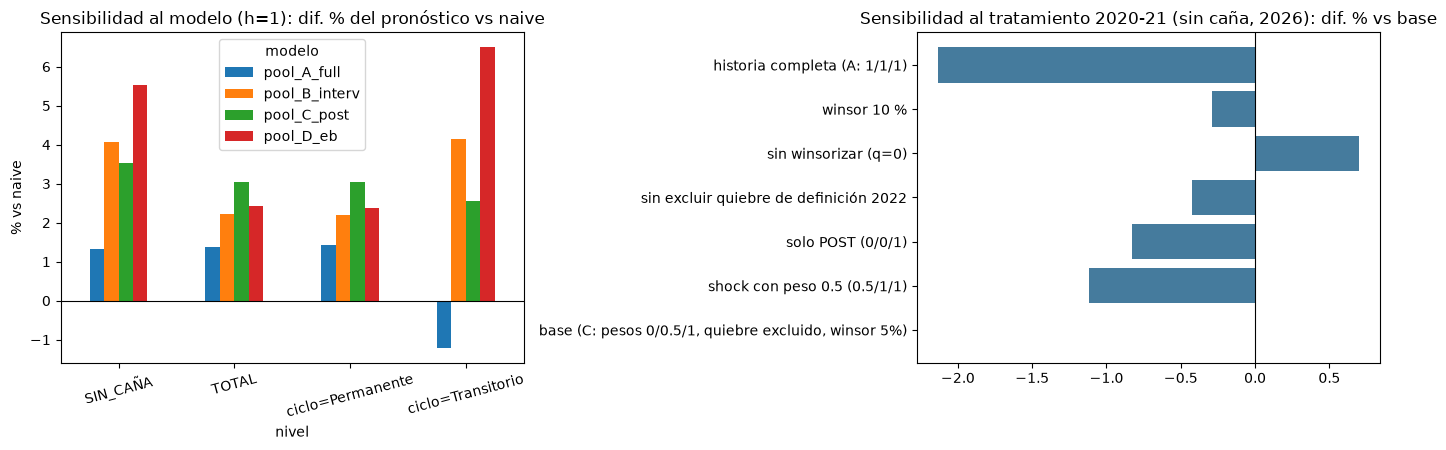

In [21]:
# Módulo 14 — Sensibilidad
SENS_MODELS = ["naive", "pool_A_full", "pool_B_interv", "pool_C_post", "pool_D_eb"]
crop_arr = META["crop"].to_numpy()
top_crops = GP.loc[:, ORIGIN].groupby(crop_arr).sum().drop("Caña", errors="ignore").nlargest(8).index.tolist()
levels = {"TOTAL": elig_f, "SIN_CAÑA": elig_f & (crop_arr != "Caña")}
for cyc in ["Permanente", "Transitorio"]:
    levels[f"ciclo={cyc}"] = elig_f & (META["cycle"].to_numpy() == cyc)
for g in sorted(META["group"].dropna().unique()):
    m = elig_f & (META["group"].to_numpy() == g)
    if GP.loc[m, ORIGIN].sum() > 0 and m.sum() >= 10:
        levels[f"grupo={g}"] = m
for cr in top_crops:
    levels[f"cultivo={cr}"] = elig_f & (crop_arr == cr)

rows = []
for h in CFG.horizons:
    P = {m: predict_named(m, CTX_F, h)[0] for m in SENS_MODELS}
    for lvl, mask in levels.items():
        tot = {m: float(np.nansum(np.where(mask, P[m], np.nan))) for m in SENS_MODELS}
        obs = float(np.nansum(np.where(mask, CTX_F.last, np.nan)))
        abcd = np.array([tot[m] for m in ["pool_A_full", "pool_B_interv", "pool_C_post", "pool_D_eb"]])
        for m in SENS_MODELS:
            rows.append({"nivel": lvl, "h": h, "target_year": FC_YEARS[h], "modelo": m, "pron_t": tot[m], "obs_origen_t": obs,
                         "cambio_vs_obs_%": 100 * (tot[m] / obs - 1) if obs > 0 else np.nan, "dif_vs_naive_%": 100 * (tot[m] / tot["naive"] - 1) if tot["naive"] > 0 else np.nan,
                         "dif_vs_A_%": 100 * (tot[m] / tot["pool_A_full"] - 1) if tot["pool_A_full"] > 0 else np.nan,
                         "spread_ABCD_%": 100 * (abcd.max() - abcd.min()) / abcd.mean() if abcd.mean() > 0 else np.nan})
SENS_MODEL = pd.DataFrame(rows)
save_table(SENS_MODEL, "scenarios", "sensitivity_models_ABCD_by_level.csv")
print("Sensibilidad A/B/C/D — diferencia % del pronóstico h=1 frente a naive (fila = nivel de agregación):")
print(SENS_MODEL[SENS_MODEL["h"] == 1].pivot(index="nivel", columns="modelo", values="dif_vs_naive_%").round(2).to_string())
print("\nDispersión A-D (spread_pct) por nivel, h=1 y h=2:")
print(SENS_MODEL.drop_duplicates(["nivel", "h"]).pivot(index="nivel", columns="h", values="spread_ABCD_%").round(2).to_string())

# --- sensibilidad a parámetros de tratamiento (modelo C como eje) ---
def pool_forecast_with(cfg_v: Config, weights, h: int = 1):
    c = ctx_for(ORIGIN, cfg_v)
    mu, _, _ = pooled_core(c, weights, cfg_v.phase_weights_full)
    return _growth_predict(c, h, mu, np.zeros(len(mu), bool))[0]


PARAM_VARIANTS = {
    "base (C: pesos 0/0.5/1, quiebre excluido, winsor 5%)": (CFG, CFG.phase_weights_post),
    "shock con peso 0.5 (0.5/1/1)": (CFG, (0.5, 1.0, 1.0)),
    "solo POST (0/0/1)": (CFG, (0.0, 0.0, 1.0)),
    "sin excluir quiebre de definición 2022": (dc_replace(CFG, exclude_definition_break=False), CFG.phase_weights_post),
    "sin winsorizar (q=0)": (dc_replace(CFG, winsor_q=0.0), CFG.phase_weights_post),
    "winsor 10 %": (dc_replace(CFG, winsor_q=0.10), CFG.phase_weights_post),
    "historia completa (A: 1/1/1)": (CFG, CFG.phase_weights_full),
}
prow = []
for name, (cfg_v, w) in PARAM_VARIANTS.items():
    p = pool_forecast_with(cfg_v, w, 1)
    for lvl in ["TOTAL", "SIN_CAÑA", "ciclo=Permanente", "ciclo=Transitorio"]:
        prow.append({"variante": name, "nivel": lvl, "pron_2026_t": float(np.nansum(np.where(levels[lvl], p, np.nan))), "obs_2025_t": float(np.nansum(np.where(levels[lvl], CTX_F.last, np.nan)))})
SENS_PARAM = pd.DataFrame(prow)
SENS_PARAM["cambio_vs_obs_%"] = 100 * (SENS_PARAM["pron_2026_t"] / SENS_PARAM["obs_2025_t"] - 1)
base_ref = SENS_PARAM[SENS_PARAM["variante"].str.startswith("base")].set_index("nivel")["pron_2026_t"]
SENS_PARAM["dif_vs_base_%"] = 100 * (SENS_PARAM["pron_2026_t"] / SENS_PARAM["nivel"].map(base_ref) - 1)
save_table(SENS_PARAM, "scenarios", "sensitivity_treatment_parameters.csv")
print("\nSensibilidad a parámetros de tratamiento — pronóstico 2026 (h=1), dif. % vs. base:")
print(SENS_PARAM.pivot(index="variante", columns="nivel", values="dif_vs_base_%").round(2).to_string())

# --- sensibilidad del desempeño (backtest) de A-D por vista ---
BT_SENS = MET_VIEW[MET_VIEW["model"].isin(["naive", "pool_A_full", "pool_B_interv", "pool_C_post", "pool_D_eb"])].copy()
BT_SENS["rank_MALE_en_vista"] = BT_SENS.groupby(["vista", "h"])["MALE"].rank(method="min")
save_table(BT_SENS, "scenarios", "sensitivity_backtest_ABCD_by_view.csv")
print("\nRanking por MALE de A-D + naive según la vista de evaluación (h=1):")
print(BT_SENS[BT_SENS["h"] == 1].pivot(index="model", columns="vista", values="rank_MALE_en_vista").to_string())

# --- gráfico de sensibilidad ---
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
d = SENS_MODEL[(SENS_MODEL["h"] == 1) & SENS_MODEL["nivel"].isin(["TOTAL", "SIN_CAÑA", "ciclo=Permanente", "ciclo=Transitorio"]) & (SENS_MODEL["modelo"] != "naive")]
pv = d.pivot(index="nivel", columns="modelo", values="dif_vs_naive_%")
pv.plot.bar(ax=ax[0]); ax[0].axhline(0, color="k", lw=.8); ax[0].set_ylabel("% vs naive"); ax[0].set_title("Sensibilidad al modelo (h=1): dif. % del pronóstico vs naive"); ax[0].tick_params(axis="x", rotation=15)
pp = SENS_PARAM[SENS_PARAM["nivel"] == "SIN_CAÑA"].set_index("variante")["dif_vs_base_%"]
ax[1].barh(pp.index, pp.values, color="#457b9d"); ax[1].axvline(0, color="k", lw=.8); ax[1].set_title("Sensibilidad al tratamiento 2020-21 (sin caña, 2026): dif. % vs base")
plt.tight_layout(); plt.savefig(OUT["scenarios"] / "sensitivity.png", dpi=130); plt.show()

## Módulo 13e — Gráfica por cultivo: producción observada y pronóstico asociado
Para **cada cultivo** (columna `Cultivo` de la fuente) se dibuja:
* la **producción observada** 2019-2025 (suma de sus series municipio × desagregación);
* el **pronóstico central** 2026-2027 (modelo campeón por ciclo) con bandas de incertidumbre al 80 % y 95 %;
* los tres **escenarios** (Normal, Histórico, Estrés) como supuestos condicionales;
* el **pronóstico a 1 año del backtest** (lo que el modelo habría dicho cada año, comparado con lo observado, sobre las mismas series) para juzgar visualmente qué tan bien ha funcionado;
* sombreado de la ventana 2020-21 (hipótesis) y de las cifras provisionales 2024-25.
Salida: `outputs/fichas_cultivos/` → un PNG por cultivo, un PDF con todos (`pronostico_por_cultivo.pdf`) y la tabla `pronostico_por_cultivo.csv`.
Aviso: en cultivos pequeños (pocas series) las bandas son amplias y el pronóstico es poco informativo; el gráfico lo muestra tal cual, sin suavizar.

In [22]:
# Módulo 13e — Gráficas por cultivo
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.ticker

CROP_DIR = Path(CFG.output_dir) / "fichas_cultivos"
CROP_DIR.mkdir(parents=True, exist_ok=True)


def _slug(s: str) -> str:
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode()
    return re.sub(r"[^a-z0-9]+", "_", s.lower()).strip("_") or "cultivo"


crop_arr_all = META["crop"].to_numpy()
crops = sorted(pd.unique(crop_arr_all))

# --- pronóstico central por serie reconstruido en el orden de GP (para simular bandas por cultivo) ---
BANDS = {}
for h in CFG.horizons:
    f = FC_SERIES[FC_SERIES["h"] == h].set_index("series_id")
    pred_h = f["pron_central_t"].reindex(GP.index).to_numpy()
    bank_h = pd.concat([residual_bank(SC, CHAMPIONS.get((cyc, h), "naive"), h, ORIGIN).query("cycle == @cyc") for cyc in ["Permanente", "Transitorio"]], ignore_index=True)
    groups_c = {c: (crop_arr_all == c) & ~np.isnan(pred_h) for c in crops}
    groups_c = {c: m for c, m in groups_c.items() if m.any()}
    BANDS[h] = simulate_aggregate(pred_h, META["cycle"].to_numpy(dtype=object), bank_h, groups_c, CFG.n_boot, CFG.seed + 100 + h).set_index("nivel")

# --- backtest a 1 año por cultivo: suma del pronóstico campeón y de lo observado sobre las mismas series ---
_sc1 = SC[(SC["h"] == 1)].copy()
_sc1["champ"] = _sc1["cycle"].map(lambda c: CHAMPIONS.get((c, 1), "naive"))
_sc1 = _sc1[_sc1["model"] == _sc1["champ"]]
if "crop" not in _sc1.columns:
    _sc1 = _sc1.join(META["crop"], on="series_id")
BT_CROP = _sc1.groupby(["crop", "target"]).agg(pred_1a=("y_pred", "sum"), obs_mismas_series=("y_true", "sum"), n_series=("series_id", "nunique")).reset_index()

rows_out = []
hist_years = list(YEARS)
for crop in crops:
    m_all = crop_arr_all == crop
    hist = GP[m_all].sum(axis=0)                      # observado (suma de series del cultivo)
    n_series = int(m_all.sum())
    n_fc = int((m_all & elig_f).sum())
    cycles = ", ".join(sorted(META.loc[m_all, "cycle"].dropna().unique()))
    fig, ax = plt.subplots(figsize=(9.5, 5.6))
    ax.axvspan(min(CFG.shock_years) - .5, max(CFG.shock_years) + .5, color="red", alpha=.07, label="ventana 2020-21 (hipótesis)")
    ax.axvspan(min(CFG.provisional_years) - .5, ORIGIN + .5, color="orange", alpha=.07, label="cifras provisionales")
    ax.plot(hist.index, hist.values, "-o", color="black", lw=2, label="producción observada")
    bt = BT_CROP[BT_CROP["crop"] == crop]
    if len(bt):
        ax.plot(bt["target"], bt["pred_1a"], ":s", color="#6c757d", ms=4, lw=1.2, label="pronóstico a 1 año del backtest (mismas series)")
    if n_fc:
        xs = [ORIGIN] + [FC_YEARS[h] for h in CFG.horizons]
        base = float(np.nansum(CTX_F.last[m_all & elig_f]))
        cen, nor, his, est, lo95, hi95, lo80, hi80 = [base], [base], [base], [base], [base], [base], [base], [base]
        for h in CFG.horizons:
            f = FC_SERIES[(FC_SERIES["h"] == h) & (FC_SERIES["crop"] == crop)]
            cen.append(f["pron_central_t"].sum()); nor.append(f["esc_normal_t"].sum()); his.append(f["esc_historico_t"].sum()); est.append(f["esc_estres_t"].sum())
            b = BANDS[h].loc[crop]
            lo95.append(b["lo95"]); hi95.append(b["hi95"]); lo80.append(b["lo80"]); hi80.append(b["hi80"])
            rows_out.append({"cultivo": crop, "ciclo": cycles, "h": h, "anio": FC_YEARS[h], "series_total": n_series, "series_pronosticadas": n_fc, "observado_2025_t": base, "referencia_naive_t": base,
                             "pron_central_t": cen[-1], "pi80_lo": lo80[-1], "pi80_hi": hi80[-1], "pi95_lo": lo95[-1], "pi95_hi": hi95[-1],
                             "esc_normal_t": nor[-1], "esc_historico_t": his[-1], "esc_estres_t": est[-1], "modelo_central": "/".join(sorted({CHAMPIONS.get((c, h), "naive") for c in META.loc[m_all, "cycle"].unique()}))})
        ax.fill_between(xs, lo95, hi95, color="#264653", alpha=.13, label="PI 95 %")
        ax.fill_between(xs, lo80, hi80, color="#264653", alpha=.22, label="PI 80 %")
        _auto = CFG.central_model == "auto"
        _scen = [(nor, "#2a9d8f", "Normal"), (his, "#e9c46a", "Histórico"), (est, "#e76f51", "Estrés")]
        _same = [lab for vals, _, lab in _scen if np.allclose(vals, cen, rtol=1e-9)]      # escenario que coincide con el central: no se dibuja dos veces
        _cen_lab = "pronóstico central" if _auto else f"pronóstico central ({CFG.central_model})"
        if _same and not _auto:
            _cen_lab += " = escenario " + "/".join(_same)
        ax.plot(xs, cen, "--s", color="#264653", lw=2, label=_cen_lab)
        if not _auto:
            ax.plot(xs, [base] * len(xs), ":", color="#6c757d", lw=1.4, label="referencia: persistencia (naive)")
        for vals, colr, lab in _scen:
            if lab in _same and not _auto:
                continue
            ax.plot(xs, vals, "-.^", color=colr, lw=1.2, ms=5, label=f"escenario {lab}")
        subt = f"{n_fc} de {n_series} series con dato en {ORIGIN} · modelo central: {rows_out[-1]['modelo_central']} · 2026: {cen[1]:,.0f} t (PI95 % {lo95[1]:,.0f}–{hi95[1]:,.0f})"
    else:
        subt = f"Sin pronóstico: ninguna de las {n_series} series tiene dato en {ORIGIN}"
        rows_out.append({"cultivo": crop, "ciclo": cycles, "h": np.nan, "anio": np.nan, "series_total": n_series, "series_pronosticadas": 0})
    ax.set_title(f"{crop} — producción observada y pronóstico\n{subt}", fontsize=10.5)
    ax.set_xlabel("año"); ax.set_ylabel("producción (t)"); ax.set_xticks(list(range(YEARS[0], FC_YEARS[max(CFG.horizons)] + 1)))
    ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.grid(alpha=.3); ax.legend(fontsize=7, loc="best"); ax.set_ylim(bottom=0)
    if CFG.central_model == "auto":
        _foot = "Escenarios = supuestos condicionales, no predicciones. Si el central coincide con la última cifra es porque el modelo respaldado por el backtest es la persistencia (naive)."
    else:
        _foot = f"Central = {CFG.central_model} (elección del usuario; en el backtest NO superó a naive, línea gris). Escenarios = supuestos condicionales, no predicciones."
    fig.text(0.01, 0.005, _foot, fontsize=6.5, color="#555")
    fig.tight_layout(rect=(0, 0.02, 1, 1))
    fig.savefig(CROP_DIR / f"pronostico_{_slug(crop)}.png", dpi=110)
    plt.close(fig)

CROP_TABLE = pd.DataFrame(rows_out)
CROP_TABLE["delta_central_vs_naive_pct"] = 100 * (CROP_TABLE["pron_central_t"] / CROP_TABLE["referencia_naive_t"] - 1)
CROP_TABLE.to_csv(CROP_DIR / "pronostico_por_cultivo.csv", index=False, encoding="utf-8-sig")

# PDF único con todas las gráficas (una por página) reutilizando los PNG
from matplotlib.image import imread
with PdfPages(CROP_DIR / "pronostico_por_cultivo.pdf") as pdf:
    for crop in crops:
        img = imread(CROP_DIR / f"pronostico_{_slug(crop)}.png")
        fig = plt.figure(figsize=(9.5, 5.6)); ax_ = fig.add_axes([0, 0, 1, 1]); ax_.imshow(img); ax_.axis("off")
        pdf.savefig(fig); plt.close(fig)
print(f"{len(crops)} cultivos graficados en {CROP_DIR}  ({int((CROP_TABLE['series_pronosticadas'] > 0).groupby(CROP_TABLE['cultivo']).any().sum())} con pronóstico)")
print(CROP_TABLE[CROP_TABLE["h"] == 1].sort_values("pron_central_t", ascending=False).head(10)[["cultivo", "series_pronosticadas", "observado_2025_t", "pron_central_t", "pi95_lo", "pi95_hi"]].round(0).to_string(index=False))

78 cultivos graficados en outputs_v5\fichas_cultivos  (69 con pronóstico)
        cultivo  series_pronosticadas  observado_2025_t  pron_central_t         pi95_lo         pi95_hi
           Caña                    63   27,132,146.0000 27,509,072.0000 27,288,953.0000 31,609,483.0000
        Plátano                    41      346,213.0000    353,705.0000    317,501.0000    400,207.0000
           Piña                    21      189,710.0000    193,815.0000    161,320.0000    242,699.0000
        Naranja                    32      135,280.0000    138,208.0000    123,091.0000    173,401.0000
       Aguacate                    61      117,258.0000    119,795.0000    110,105.0000    148,308.0000
         Banano                    38      100,257.0000    102,427.0000     91,922.0000    126,032.0000
         Tomate                    50      103,958.0000    102,078.0000     94,385.0000    143,186.0000
           Maíz                    99       89,184.0000     88,852.0000     78,969.0000    132

## Módulo 13f — Fichas PDF por cultivo
Una página por cultivo (titular, proyección con persistencia y escenarios «¿Y si…?», histórico de área sembrada/cosechada/producción/rendimiento, geografía y semáforo de confianza), más portada con total **con y sin caña**, índice y anexo metodológico.
Lee `FC_SERIES`, `CROP_TABLE`, `GP/GA/GS`, `META`, `SC` y `CHAMPIONS` desde memoria (no relee el Excel). Requiere `reportlab`. Ámbito: todo el departamento o un municipio (`FICHAS_MUNICIPIO`).

In [23]:
# Módulo 13f — Fichas PDF por cultivo (portada + índice + 1 página por cultivo + anexo metodológico)
# ----------------------------------------------------------------------------------------------------------------------
# Lee lo que el notebook ya calculó en memoria (nada se vuelve a leer del Excel):
#   FC_SERIES  pronóstico por serie (municipio × desagregación)     -> pronóstico del ámbito municipal
#   CROP_TABLE pronóstico por cultivo con bandas 80/95 % y escenarios -> pronóstico del ámbito departamental
#   GP / GA / GS / META   producción, área cosechada, área sembrada y metadatos (ya normalizados: sin cuarentena)
#   SC / CHAMPIONS        backtest puntuado y modelo central por ciclo -> historial de aciertos
#   FC_AGG (opcional)     agregados con banda simulada -> portada (total con y sin caña)
# Requiere: reportlab  (pip install reportlab)
#
# Uso (celda del notebook, después de 13e):
#     FICHAS_MUNICIPIO = None            # None = todo el departamento | "Sevilla" = ámbito municipal
#     FICHAS_CULTIVOS  = None            # None = todos | ["Plátano", "Café"]
#     FICHAS_PDF = build_fichas_pdf(FICHAS_MUNICIPIO, FICHAS_CULTIVOS)
# ----------------------------------------------------------------------------------------------------------------------
import datetime as _dt
import io as _io
import re as _re
import unicodedata as _ud
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter
from reportlab.lib import colors as rl_colors
from reportlab.lib.pagesizes import letter
from reportlab.lib.styles import ParagraphStyle
from reportlab.lib.utils import ImageReader
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont
from reportlab.pdfgen import canvas as rl_canvas
from reportlab.platypus import Paragraph, Table, TableStyle

F13_CANA = "Caña"            # nombre exacto del cultivo dominante (el mismo que usa el notebook)
F13_DPI = 200
F13_WATERMARK = None         # texto opcional en el pie (p. ej. para PDFs de prueba)
PAGE_W, PAGE_H = letter
MG = 36.0
CWD = PAGE_W - 2 * MG

PAL = dict(primary="#1B4332", accent="#2D6A4F", mid="#40916C", light="#95D5B2", pale="#EAF5EE", zebra="#F3F8F5",
           amber="#E9A800", amber_pale="#FFF3D1", red="#B23A2E", ink="#1F2933", muted="#6B7280", line="#D1D5DB",
           sem="#95D5B2", cos="#40916C", prod="#1B4332", rend="#C98A00", teal="#2A9D8F", stress="#E76F51", hist="#E9C46A")
CONF_COLOR = {"ALTA": "#2D6A4F", "MEDIA": "#C98A00", "BAJA": "#B23A2E", "SIN PRONÓSTICO": "#6B7280"}
VARS13 = [("sem", "Área sembrada", "ha", PAL["sem"]), ("cos", "Área cosechada", "ha", PAL["cos"]),
          ("prod", "Producción", "t", PAL["prod"]), ("rend", "Rendimiento", "t/ha", PAL["rend"])]


# ---------------------------------------------------------------------------------------------------- formato es-CO
def es(v, dec=0):
    if v is None or (isinstance(v, (float, np.floating)) and not np.isfinite(v)):
        return "–"
    s = f"{v:,.{dec}f}"
    return s.replace(",", "\0").replace(".", ",").replace("\0", ".")


def es_t(v):
    if v is None or not np.isfinite(v):
        return "–"
    a = abs(v)
    return es(v, 0 if a >= 100 else (1 if a >= 10 else 2))


def pct(v, dec=1, sign=True):
    if v is None or not np.isfinite(v):
        return "–"
    s = es(abs(v), dec) + " %"
    if sign:
        return ("+" if v > 0 else ("−" if v < 0 else "")) + s
    return ("−" if v < 0 else "") + s


def compact(v, dec=1):
    if v is None or not np.isfinite(v):
        return ""
    a = abs(v)
    if a >= 1e6:
        return es(v / 1e6, 2) + " M"
    if a >= 1e3:
        return es(v / 1e3, dec if a < 1e5 else 0) + " mil"
    return es(v, 0 if a >= 100 else 1)


def t_txt(v):
    """346 mil t · 1,23 M t · 845 t"""
    return compact(v) + " t"


def rng_txt(lo, hi):
    if not (np.isfinite(lo) and np.isfinite(hi)):
        return "n.d."
    if hi >= 1e6:
        return f"{es(lo / 1e6, 2)}–{es(hi / 1e6, 2)} M"
    if hi >= 1e5:
        return f"{es(lo / 1e3, 0)}–{es(hi / 1e3, 0)} mil"
    if hi >= 1e3:
        return f"{es(lo / 1e3, 1)}–{es(hi / 1e3, 1)} mil"
    return f"{es(lo, 0)}–{es(hi, 0)}"


def pchg(new, old):
    if new is None or old is None or not np.isfinite(new) or not np.isfinite(old) or old == 0:
        return np.nan
    return (new / old - 1) * 100


def _norm(s):
    return _ud.normalize("NFKD", str(s)).encode("ascii", "ignore").decode().lower().strip()


def sign_color(v):
    ok = v is not None and np.isfinite(v)
    return PAL["accent"] if (ok and v > 0) else (PAL["red"] if (ok and v < 0) else PAL["muted"])


# ---------------------------------------------------------------------------------------------------- dibujo (reportlab)
def _fonts():
    d = Path(matplotlib.__file__).parent / "mpl-data" / "fonts" / "ttf"
    for name, f in (("DV", "DejaVuSans.ttf"), ("DV-B", "DejaVuSans-Bold.ttf"), ("DV-I", "DejaVuSans-Oblique.ttf"), ("DV-BI", "DejaVuSans-BoldOblique.ttf")):
        pdfmetrics.registerFont(TTFont(name, str(d / f)))
    pdfmetrics.registerFontFamily("DV", normal="DV", bold="DV-B", italic="DV-I", boldItalic="DV-BI")


def _sty(size=8, color=PAL["ink"], font="DV", leading=None, align=0):
    return ParagraphStyle("x", fontName=font, fontSize=size, leading=leading or size * 1.3, textColor=rl_colors.HexColor(color), alignment=align)


def _text(c, x, y, s, size=8, font="DV", color=PAL["ink"], align="l"):
    c.setFont(font, size)
    c.setFillColor(rl_colors.HexColor(color))
    {"l": c.drawString, "r": c.drawRightString, "c": c.drawCentredString}[align](x, y, s)


def _para(c, s, x, y_top, w, style):
    p = Paragraph(s, style)
    _, h = p.wrap(w, 10_000)
    p.drawOn(c, x, y_top - h)
    return h


def _table(c, data, x, y_top, colw, rowh=12.0, fs=6.6, hdr_h=None, aligns=None, extra=None, zebra=True):
    t = Table(data, colWidths=colw, rowHeights=[hdr_h or rowh] + [rowh] * (len(data) - 1))
    sty = [("FONT", (0, 0), (-1, -1), "DV", fs), ("VALIGN", (0, 0), (-1, -1), "MIDDLE"), ("LEFTPADDING", (0, 0), (-1, -1), 3),
           ("RIGHTPADDING", (0, 0), (-1, -1), 3), ("TOPPADDING", (0, 0), (-1, -1), 1), ("BOTTOMPADDING", (0, 0), (-1, -1), 1),
           ("LINEBELOW", (0, 0), (-1, -1), 0.3, rl_colors.HexColor(PAL["line"])),
           ("BACKGROUND", (0, 0), (-1, 0), rl_colors.HexColor(PAL["primary"])), ("TEXTCOLOR", (0, 0), (-1, 0), rl_colors.white),
           ("FONT", (0, 0), (-1, 0), "DV-B", fs - 0.2)]
    if zebra:
        sty += [("BACKGROUND", (0, r), (-1, r), rl_colors.HexColor(PAL["zebra"])) for r in range(2, len(data), 2)]
    for ci, a in enumerate(aligns or []):
        sty.append(("ALIGN", (ci, 0), (ci, -1), {"l": "LEFT", "r": "RIGHT", "c": "CENTER"}[a]))
    t.setStyle(TableStyle(sty + (extra or [])))
    _, h = t.wrap(sum(colw), 10_000)
    t.drawOn(c, x, y_top - h)
    return h


def _bar(c, y_top, title, right=None):
    c.setFillColor(rl_colors.HexColor(PAL["pale"]))
    c.rect(MG, y_top - 12.5, CWD, 12.5, stroke=0, fill=1)
    _text(c, MG + 5, y_top - 9.3, title, 8, "DV-B", PAL["primary"])
    if right:
        _text(c, MG + CWD - 5, y_top - 9.3, right, 6.4, "DV-I", PAL["muted"], "r")
    return y_top - 15


def _kpi(c, x, y_top, w, h, label, value, sub, sub_color=PAL["muted"]):
    c.setFillColor(rl_colors.HexColor(PAL["pale"]))
    c.setStrokeColor(rl_colors.HexColor("#CFE8D7"))
    c.roundRect(x, y_top - h, w, h, 5, stroke=1, fill=1)
    _text(c, x + 7, y_top - 12, label, 6.4, "DV", PAL["muted"])
    _text(c, x + 7, y_top - 28, value, 12.5, "DV-B", PAL["primary"])
    _text(c, x + 7, y_top - 40, sub, 6.6, "DV", sub_color)


def _pill(c, x, y, s, color, w=None, h=14, size=7.5):
    w = w or (pdfmetrics.stringWidth(s, "DV-B", size) + 14)
    c.setFillColor(rl_colors.HexColor(color))
    c.roundRect(x, y, w, h, 7, stroke=0, fill=1)
    _text(c, x + w / 2, y + 4, s, size, "DV-B", "#FFFFFF", "c")
    return w


def _footer(c, pn, total, ctx):
    c.setStrokeColor(rl_colors.HexColor(PAL["line"]))
    c.setLineWidth(0.5)
    c.line(MG, 30, PAGE_W - MG, 30)
    _text(c, MG, 20, f"Fuente: EVA-UPRA, Base Agrícola {ctx['YEARS'][0]}-{ctx['ORIGIN']}. Cifras {ctx['PROV'][0]}-{ctx['PROV'][1]} provisionales.", 6.2, "DV", PAL["muted"])
    _text(c, PAGE_W - MG, 20, f"Página {pn} de {total}", 6.6, "DV", PAL["muted"], "r")
    if F13_WATERMARK:
        _text(c, PAGE_W / 2, 8, F13_WATERMARK, 7, "DV-B", PAL["red"], "c")


def _band(c, title, scope_line, line3, right_txt=None, conf=None, band_h=64):
    c.setFillColor(rl_colors.HexColor(PAL["primary"]))
    c.rect(0, PAGE_H - band_h, PAGE_W, band_h, stroke=0, fill=1)
    c.setFillColor(rl_colors.HexColor(PAL["light"]))
    c.rect(0, PAGE_H - band_h, 7, band_h, stroke=0, fill=1)
    fs = min(24.0, 24.0 * (CWD - 175) / max(pdfmetrics.stringWidth(title, "DV-B", 24), 1))
    _text(c, MG, PAGE_H - 32, title, fs, "DV-B", "#FFFFFF")
    _text(c, MG, PAGE_H - 47, scope_line, 10.5, "DV-B", PAL["light"])
    _text(c, MG, PAGE_H - 59, line3, 6.8, "DV", "#D8F3DC")
    if right_txt:
        _text(c, PAGE_W - MG, PAGE_H - 22, right_txt, 8, "DV-B", "#FFFFFF", "r")
    if conf:
        lab = f"Confianza: {conf.capitalize() if conf != 'SIN PRONÓSTICO' else 'sin proyección'}"
        w = pdfmetrics.stringWidth(lab, "DV-B", 8) + 22
        c.setFillColor(rl_colors.white)
        c.roundRect(PAGE_W - MG - w, PAGE_H - 47, w, 16, 8, stroke=0, fill=1)
        c.setFillColor(rl_colors.HexColor(CONF_COLOR[conf]))
        c.circle(PAGE_W - MG - w + 9, PAGE_H - 39, 3.2, stroke=0, fill=1)
        _text(c, PAGE_W - MG - w + 16, PAGE_H - 42, lab, 8, "DV-B", CONF_COLOR[conf])
    return PAGE_H - band_h


# ---------------------------------------------------------------------------------------------------- gráficas (matplotlib)
def _style_ax(ax, fs=6.0):
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color("#9CA3AF")
    ax.tick_params(labelsize=fs, colors="#374151", length=2, pad=1.5)
    ax.grid(axis="y", color="#E5E7EB", lw=0.5)
    ax.set_axisbelow(True)


def _png(fig):
    buf = _io.BytesIO()
    fig.savefig(buf, format="png", dpi=F13_DPI)
    plt.close(fig)
    buf.seek(0)
    return ImageReader(buf)


def _mini(vals, color, w, h, title, kind, X, transit):
    """Mini-gráfica 2019-2025: barras (áreas y producción) o línea (rendimiento). Etiqueta solo el último dato."""
    years, prov, brk = X["YEARS"], X["PROV"], X["BREAK"]
    fig, ax = plt.subplots(figsize=(w / 72, h / 72))
    v = vals.reindex(years).to_numpy(dtype=float)
    ax.set_title(title, fontsize=6.4, loc="left", color=PAL["primary"], fontweight="bold", pad=2)
    if not np.isfinite(v).any():
        ax.text(0.5, 0.5, "Sin datos", ha="center", va="center", color="#6B7280", fontsize=7, transform=ax.transAxes)
        ax.axis("off")
        return _png(fig)
    last = int(np.where(np.isfinite(v))[0].max())
    if kind == "bar":
        top = np.nanmax(v) * 1.25 if np.nanmax(v) > 0 else 1
        for xi, vi in zip(years, v):
            if np.isfinite(vi):
                p = xi in prov
                ax.bar(xi, vi, width=0.66, color=color, alpha=0.55 if p else 1.0, hatch="////" if p else None, edgecolor=color if p else "white", lw=0.3)
        ax.set_ylim(0, top)
        ax.text(years[last], v[last] + top * 0.02, compact(v[last]), ha="center", va="bottom", fontsize=5.6, color="#111827")
        ax.yaxis.set_major_formatter(FuncFormatter(lambda t, _: compact(t, 0)))
    else:
        lo, hi = np.nanmin(v), np.nanmax(v)
        pad = (hi - lo) * 0.4 if hi > lo else max(hi * 0.2, 0.5)
        ymin, ymax = max(0, lo - pad), hi + pad * 1.3
        ax.plot(years, v, "-", color=color, lw=1.6)
        for xi, vi in zip(years, v):
            if np.isfinite(vi):
                ax.plot(xi, vi, "o", ms=3.6, color="white" if xi in prov else color, mec=color, mew=1.2)
        ax.text(years[last], v[last] + (ymax - ymin) * 0.06, es(v[last], 2), ha="center", va="bottom", fontsize=5.6, color="#111827")
        ax.set_ylim(ymin, ymax)
        ax.yaxis.set_major_formatter(FuncFormatter(lambda t, _: es(t, 1)))
    ax.set_xticks(years)
    ax.set_xticklabels([str(y)[2:] for y in years])
    ax.set_xlim(years[0] - 0.6, years[-1] + 0.6)
    _style_ax(ax, 5.6)
    if transit:
        ax.axvline(brk - 0.5, color="#9CA3AF", ls=":", lw=0.9)
    fig.tight_layout(pad=0.3)
    return _png(fig)


def _chart_proj(obs, fc, w, h, transit, X):
    years, prov, shock, brk, origin = X["YEARS"], X["PROV"], X["SHOCK"], X["BREAK"], X["ORIGIN"]
    fig, ax = plt.subplots(figsize=(w / 72, h / 72))
    ov = obs.reindex(years)
    base = fc["base"]
    xs = [origin, origin + 1, origin + 2]
    f1, f2 = fc[1], fc[2]
    cen = [base, f1["pron_central_t"], f2["pron_central_t"]]
    has_pi = bool(fc["has_pi"]) and all(np.isfinite([f1["pi95_lo"], f2["pi95_lo"], f1["pi80_lo"], f2["pi80_lo"]]))
    ax.axvspan(shock[0] - 0.5, shock[1] + 0.5, color="#F8D7D3", alpha=0.45, lw=0)
    ax.axvspan(prov[0] - 0.5, origin + 0.5, color="#FFF0C2", alpha=0.6, lw=0)
    if has_pi:
        ax.fill_between(xs, [base, f1["pi95_lo"], f2["pi95_lo"]], [base, f1["pi95_hi"], f2["pi95_hi"]], color=PAL["primary"], alpha=0.13, lw=0)
        ax.fill_between(xs, [base, f1["pi80_lo"], f2["pi80_lo"]], [base, f1["pi80_hi"], f2["pi80_hi"]], color=PAL["primary"], alpha=0.25, lw=0)
    ax.plot(xs, [base] * 3, ":", color="#6B7280", lw=1.2)
    if transit:
        ax.axvline(brk - 0.5, color="#9CA3AF", ls=":", lw=0.9)
    same_hist = np.allclose([f1["esc_historico_t"], f2["esc_historico_t"]], [f1["pron_central_t"], f2["pron_central_t"]], rtol=1e-9)
    scen = [("esc_normal_t", PAL["teal"], "Normal"), ("esc_estres_t", PAL["stress"], "Estrés")]
    if not same_hist:
        scen.insert(1, ("esc_historico_t", PAL["hist"], "Histórico"))
    for k, col, _ in scen:
        ax.plot(xs, [base, f1[k], f2[k]], "-.^", color=col, lw=1.0, ms=4)
    ax.plot(ov.index, ov.values, "-o", color="#111827", lw=1.8, ms=3.8)
    ax.plot(xs, cen, "--s", color=PAL["primary"], lw=1.8, ms=5)
    vals = list(ov.dropna().values) + cen + [f1["esc_estres_t"], f2["esc_estres_t"], f1["esc_normal_t"], f2["esc_normal_t"]]
    hi_c = max(vals + ([f1["pi80_hi"], f2["pi80_hi"]] if has_pi else []))
    lo_c = min(vals + ([f1["pi80_lo"], f2["pi80_lo"]] if has_pi else []))
    top = hi_c * 1.2 if hi_c > 0 else 1
    bottom = max(0, lo_c - (hi_c - lo_c) * 0.35)
    if bottom < 0.15 * top:
        bottom = 0
    ax.set_ylim(bottom, top)
    if has_pi and max(f1["pi95_hi"], f2["pi95_hi"]) > top:
        ax.text(origin + 2.4, top * 0.985, f"▲ rango 95 % llega a {compact(max(f1['pi95_hi'], f2['pi95_hi']))}", fontsize=5.6, color=PAL["primary"], va="top", ha="right")
    if transit:
        ax.text(brk - 0.42, top * 0.985, "cambio de definición", fontsize=5.2, color="#6B7280", va="top")
    for xv, val in ((origin + 1, f1["pron_central_t"]), (origin + 2, f2["pron_central_t"])):
        ax.annotate(compact(val), (xv, val), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=6.4, color=PAL["primary"], weight="bold")
    ax.set_xticks(list(years) + [origin + 1, origin + 2])
    ax.set_xlim(years[0] - 0.5, origin + 2.5)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda t, _: compact(t, 0)))
    ax.set_ylabel("producción (t)" + ("" if bottom == 0 else " · el eje no parte de cero"), fontsize=5.8)
    _style_ax(ax, 5.8)
    hd = [Line2D([], [], color="#111827", marker="o", lw=1.8, ms=3.5, label="Observado"),
          Line2D([], [], color=PAL["primary"], marker="s", ls="--", lw=1.8, ms=4.5, label="Proyección central")]
    if has_pi:
        hd += [Patch(color=PAL["primary"], alpha=0.25, label="Rango 80 %"), Patch(color=PAL["primary"], alpha=0.13, label="Rango 95 %")]
    hd += [Line2D([], [], color="#6B7280", ls=":", lw=1.2, label=f"Persistencia (se repite {origin})")]
    hd += [Line2D([], [], color=col, marker="^", ls="-.", lw=1.0, ms=3.5, label=f"¿Y si…? {lab}") for _, col, lab in scen]
    hd += [Patch(color="#FFF0C2", label="Cifras provisionales"), Patch(color="#F8D7D3", label=f"{shock[0]}-{str(shock[1])[2:]} (hipótesis)")]
    ax.legend(handles=hd, loc="upper center", bbox_to_anchor=(0.5, -0.10), ncol=4, fontsize=5.3, frameon=False, columnspacing=0.9, handlelength=1.6, handletextpad=0.4)
    fig.tight_layout(pad=0.4)
    return _png(fig), same_hist


def _chart_geo(t, highlight, w, h, top_n):
    top = t.head(top_n)
    if highlight and highlight not in set(top["muni"]) and (t["muni"] == highlight).any():
        top = pd.concat([top, t[t["muni"] == highlight]])
    top = top.iloc[::-1]
    fig, ax = plt.subplots(figsize=(w / 72, h / 72))
    cols = [PAL["amber"] if (highlight and m == highlight) else PAL["mid"] for m in top["muni"]]
    ax.barh(top["muni"], top["p25"], color=cols, height=0.62)
    mx = top["p25"].max()
    for yi, (v, s) in enumerate(zip(top["p25"], top["share"])):
        ax.text(v + mx * 0.012, yi, f"{compact(v)} t · {es(s, 1)} %", va="center", fontsize=6, color="#111827")
    ax.set_xlim(0, mx * 1.42)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda t_, _: compact(t_, 1)))
    ax.tick_params(axis="y", labelsize=6.4)
    _style_ax(ax, 5.8)
    ax.grid(axis="x", color="#E5E7EB", lw=0.5)
    ax.grid(axis="y", visible=False)
    fig.tight_layout(pad=0.3)
    return _png(fig)


def _chart_totals(sin, con, fc_sin, fc_con, w, h, X):
    """Portada: total SIN caña y total CON caña, observado 2019-2025 y proyección con banda 95 % si existe."""
    years, prov, origin = X["YEARS"], X["PROV"], X["ORIGIN"]
    fig, axes = plt.subplots(1, 2, figsize=(w / 72, h / 72))
    for ax, s, f, ttl, col in ((axes[0], sin, fc_sin, f"Total sin {F13_CANA.lower()} (t)", PAL["accent"]), (axes[1], con, fc_con, f"Total con {F13_CANA.lower()} (t)", "#111827")):
        ax.set_title(ttl, fontsize=7, loc="left", fontweight="bold", color=PAL["primary"], pad=3)
        ax.axvspan(prov[0] - 0.5, origin + 0.5, color="#FFF0C2", alpha=0.6, lw=0)
        v = s.reindex(years)
        ax.plot(v.index, v.values, "-o", color=col, lw=1.8, ms=3.6)
        vals = list(v.dropna().values)
        if f:
            xs = [origin, origin + 1, origin + 2]
            ax.plot(xs, [f["base"], f["y1"], f["y2"]], "--s", color=PAL["primary"], lw=1.5, ms=4)
            vals += [f["y1"], f["y2"]]
            if f.get("lo95") is not None:
                ax.fill_between(xs[1:], f["lo95"], f["hi95"], color=PAL["primary"], alpha=0.14, lw=0)
                vals += list(f["lo95"]) + list(f["hi95"])
            ax.annotate(compact(f["y1"]), (origin + 1, f["y1"]), textcoords="offset points", xytext=(0, 6), ha="center", fontsize=6, color=PAL["primary"], weight="bold")
        ax.annotate(compact(v.dropna().iloc[-1]), (v.dropna().index[-1], v.dropna().iloc[-1]), textcoords="offset points", xytext=(0, -11), ha="center", fontsize=6, color="#111827")
        lo, hi = min(vals), max(vals)
        pad = (hi - lo) * 0.25 if hi > lo else hi * 0.2
        ax.set_ylim(max(0, lo - pad), hi + pad * 1.3)
        ax.set_xticks(list(years) + [origin + 1, origin + 2])
        ax.set_xticklabels([str(y)[2:] for y in list(years) + [origin + 1, origin + 2]])
        ax.yaxis.set_major_formatter(FuncFormatter(lambda t, _: compact(t, 0)))
        _style_ax(ax, 6)
    fig.tight_layout(pad=0.4, w_pad=1.6)
    return _png(fig)


# ---------------------------------------------------------------------------------------------------- lectura de datos del notebook
def _get_inputs():
    g = globals()
    need = ["GP", "GA", "GS", "META", "FC_SERIES", "CROP_TABLE", "SC", "CHAMPIONS", "CFG", "ORIGIN", "YEARS"]
    miss = [k for k in need if k not in g]
    if miss:
        raise NameError(f"Módulo 13f: faltan {miss}. Ejecute antes los módulos 5 (panel), 12 (campeones), 13 (SC/FC_SERIES) y 13e (CROP_TABLE).")
    X = {k: g[k] for k in need}
    X["FC_AGG"] = g.get("FC_AGG")
    X["YEARS"] = list(X["YEARS"])
    X["PROV"] = tuple(X["CFG"].provisional_years)
    X["SHOCK"] = tuple(X["CFG"].shock_years)
    X["BREAK"] = int(X["CFG"].definition_break_year)
    X["OUTDIR"] = Path(X["CFG"].output_dir) / "fichas_cultivos"
    return X


def _model_txt(name, X):
    o = X["ORIGIN"]
    d = {"naive": f"persistencia: se repite la cifra de {o}",
         "pool_A_full": f"continuación del crecimiento promedio {X['YEARS'][0]}-{o} de series similares del departamento",
         "pool_B_interv": f"crecimiento de series similares con ajuste por el shock {X['SHOCK'][0]}-{str(X['SHOCK'][1])[2:]}",
         "pool_C_post": "crecimiento posterior al shock de series similares",
         "pool_D_eb": "crecimiento de series similares con suavizado bayesiano",
         "ens_mean": "promedio de varios modelos"}
    return "/".join(d.get(p, p) for p in str(name).split("/"))


def _forecast(scope, crop, X, n_series_scope):
    ct, fs = X["CROP_TABLE"], X["FC_SERIES"]
    if not scope["muni"]:
        t = ct[(ct["cultivo"] == crop) & ct["h"].notna()]
        if t.empty or not {1, 2} <= set(t["h"].astype(int)):
            return None
        out = {"model": str(t["modelo_central"].iloc[0]), "n_fc": int(t["series_pronosticadas"].iloc[0]), "n_total": int(t["series_total"].iloc[0]),
               "base": float(t["observado_2025_t"].iloc[0]), "has_pi": True}
        for _, r in t.iterrows():
            out[int(r["h"])] = {k: float(r[k]) for k in ("pron_central_t", "pi80_lo", "pi80_hi", "pi95_lo", "pi95_hi", "esc_normal_t", "esc_historico_t", "esc_estres_t")}
            out[int(r["h"])]["year"] = int(r["anio"])
        return out
    s = fs[(fs["crop"] == crop) & (fs["muni_code"] == scope["code"])]
    if s.empty or not {1, 2} <= set(s["h"].astype(int)):
        return None
    s1 = s[s["h"] == 1]
    out = {"model": str(s["modelo_central"].iloc[0]), "n_fc": int(s1["series_id"].nunique()), "n_total": n_series_scope,
           "base": float(s1["last_obs_t"].sum()), "has_pi": len(s1) == 1}
    for h, g in s.groupby("h"):
        one = len(g) == 1
        out[int(h)] = {"pron_central_t": float(g["pron_central_t"].sum()), "esc_normal_t": float(g["esc_normal_t"].sum()),
                       "esc_historico_t": float(g["esc_historico_t"].sum()), "esc_estres_t": float(g["esc_estres_t"].sum()), "year": int(g["target_year"].iloc[0]),
                       **{k: (float(g[k].iloc[0]) if one else np.nan) for k in ("pi80_lo", "pi80_hi", "pi95_lo", "pi95_hi")}}
    return out


def _prep_backtest(X):
    sc = X["SC"]
    keep = [c for c in ("model", "h", "target", "series_id", "y_true", "y_pred", "cycle", "is_break_target", "crop", "muni_code") if c in sc.columns]
    b = sc[keep]
    b = b[(b["h"] == 1) & b["target"].isin([X["ORIGIN"] - 2, X["ORIGIN"] - 1, X["ORIGIN"]]) & (~b["is_break_target"].astype(bool)) & b["y_pred"].notna()].copy()
    m = X["META"]
    for col in ("cycle", "crop", "muni_code"):
        if col not in b.columns:
            b = b.join(m[col], on="series_id")
    ch = X["CHAMPIONS"]
    b["champ"] = b["cycle"].map(lambda cy: ch.get((cy, 1), "naive"))
    return b[b["model"] == b["champ"]], b[b["model"] == "naive"]


def _track(bm, bn, crop, scope):
    m0 = bm[bm["crop"] == crop]
    n0 = bn[bn["crop"] == crop]
    if scope["muni"]:
        m0, n0 = m0[m0["muni_code"] == scope["code"]], n0[n0["muni_code"] == scope["code"]]
    rows = []
    for y in sorted(m0["target"].unique()):
        m, n = m0[m0["target"] == y], n0[n0["target"] == y]
        n = n[n["series_id"].isin(m["series_id"])]
        rows.append({"year": int(y), "obs": m["y_true"].sum(), "pred": m["y_pred"].sum(), "err": pchg(m["y_pred"].sum(), m["y_true"].sum()),
                     "err_naive": pchg(n["y_pred"].sum(), n["y_true"].sum()) if len(n) else np.nan})
    return pd.DataFrame(rows, columns=["year", "obs", "pred", "err", "err_naive"])


def _load_d1_map():
    """AUD-FICHAS-001: sensibilidad D1 por cultivo desde sensitivity_D1_exclude_quiebre.csv."""
    p = Path(CFG.output_dir) / "scenarios" / "sensitivity_D1_exclude_quiebre.csv"
    if not p.exists():
        return {}
    t = pd.read_csv(p, encoding="utf-8-sig")
    if "afectado" in t.columns:
        t = t[t["afectado"].astype(bool)]
    out = {}
    for _, r in t.iterrows():
        out[r["cultivo"]] = {"pct_excluidas": float(r.get("pct_excluidas", 0.0) or 0.0),
                             "delta": float(r.get("delta_2026_pct", 0.0) or 0.0),
                             "n_excl": int(r.get("series_excluidas", 0) or 0),
                             "n_tot": int(r.get("series_total", 0) or 0),
                             "base": float(r.get("baseline_2026_t", np.nan)),
                             "clean": float(r.get("clean_2026_t", np.nan))}
    return out


def _d1_nota(crop, X):
    d = _load_d1_map().get(crop)
    if not d or abs(d["delta"]) <= 10.0:
        return ""
    return (f" <b>Sensibilidad D1</b>: {d['n_excl']} de {d['n_tot']} series de este cultivo "
            f"presentan quiebre de definicion 2021→2022 no validado con la fuente; al excluirlas, "
            f"la proyeccion {X['ORIGIN'] + 1} cae {abs(d['delta']):.0f} % "
            f"(de {es_t(d['base'])} a {es_t(d['clean'])} t). Lea el central como cota superior.")


def _conf_con_d1(fc, tr, n_munis, frozen, cycle, scope, X, crop):
    """Wrapper AUD-FICHAS-001: semaforo original + penalizacion D1 (+2 si >5% de series flaggeadas)."""
    lab, items = _confidence(fc, tr, n_munis, frozen, cycle, scope, X)
    d = _load_d1_map().get(crop)
    if d is not None and d.get("pct_excluidas", 0.0) > 5.0 and lab != "SIN PRONÓSTICO":
        items = list(items) + [(f"Sensibilidad D1: {d['n_excl']} de {d['n_tot']} series con quiebre "
                                f"de definicion 2021→2022 no validado; sin ellas la proyeccion cae "
                                f"{abs(d['delta']):.0f}%. Lea el central como cota superior.", 2)]
        score = sum(s for _, s in items)
        lab = "ALTA" if score == 0 else ("MEDIA" if score <= 2 else "BAJA")
    return lab, items


def _confidence(fc, tr, n_munis, frozen, cycle, scope, X):
    """Semáforo operativo (criterio de las fichas, no una medida estadística). Devuelve (etiqueta, [(texto, 0/1/2)])."""
    if fc is None:
        return "SIN PRONÓSTICO", []
    o, items, score = X["ORIGIN"], [], 0
    mape = float(tr["err"].abs().mean()) if len(tr) else np.nan
    if not np.isfinite(mape):
        items.append(("Sin historial de aciertos (backtest) para este cultivo.", 2)); score += 2
    else:
        s_ = 0 if mape <= 5 else (1 if mape <= 10 else 2)
        items.append((f"Error medio del pronóstico a 1 año ({o - 2}-{str(o)[2:]}): {pct(mape, 1, False)}.", s_)); score += s_
    if scope["muni"]:
        items.append(("Ámbito municipal: la proyección usa una tasa común a series similares, sin señal propia del municipio.", 1)); score += 1
    else:
        s_ = 0 if n_munis >= 8 else (1 if n_munis >= 4 else 2)
        items.append((f"Municipios productores en {o}: {n_munis}." if not s_ else f"Pocos municipios productores en {o}: {n_munis}; un cambio en uno mueve el total.", s_)); score += s_
    if frozen is not None:
        if scope["muni"]:
            s_ = 1 if frozen["k"] else 0
            items.append((f"La cifra del municipio {'es idéntica' if s_ else 'cambió'} respecto del año previo ({o - 1} o {o}).", s_)); score += s_
        else:
            s_ = 1 if frozen["pct"] > 50 else 0
            items.append((f"Municipios que repiten la cifra del año previo ({o - 1} o {o}): {frozen['k']} de {frozen['n']}" + (" (posible cifra no actualizada)." if s_ else "."), s_)); score += s_
    s_ = 1 if "Transitorio" in cycle else 0
    items.append((f"Ciclo transitorio: solo {X['BREAK']}-{o} es comparable (cambio de definición)." if s_ else f"Ciclo permanente: serie comparable {X['YEARS'][0]}-{o}.", s_)); score += s_
    cov = fc["n_fc"] / fc["n_total"] if fc["n_total"] else 0
    s_ = 1 if cov < 0.7 else 0
    items.append((f"Series con dato en {o} y pronóstico: {fc['n_fc']} de {fc['n_total']}.", s_)); score += s_
    return ("ALTA" if score == 0 else ("MEDIA" if score <= 2 else "BAJA")), items


def _headline(ctx, X):
    crop, ann, fc, o, ref = ctx["crop"], ctx["ann"], ctx["fc"], X["ORIGIN"], X["BREAK"]
    p1 = ann.loc[o, "prod"]
    if not np.isfinite(p1):
        ly = ann["prod"].dropna().index.max() if ann["prod"].notna().any() else None
        return f"{crop}: sin registro de producción en {o}" + (f" (último dato {ly}: {t_txt(ann.loc[ly, 'prod'])})" if ly else "") + "; no se proyecta."
    d = pchg(p1, ann.loc[ref, "prod"])
    if not np.isfinite(d):
        trend = f"sin dato comparable en {ref}"
    elif abs(d) < 5:
        trend = f"estable desde {ref} ({pct(d)})"
    else:
        trend = f"{'en alza' if d > 0 else 'a la baja'} desde {ref} ({pct(d, 0)})"
    s = f"{crop}: {t_txt(p1)} en {o}, {trend}"
    if fc:
        s += f"; se espera {t_txt(fc[1]['pron_central_t'])} en {fc[1]['year']}"
        if fc["has_pi"] and np.isfinite(fc[1]["pi95_lo"]):
            s += f" (rango 95 %: {rng_txt(fc[1]['pi95_lo'], fc[1]['pi95_hi'])} t)"
    else:
        s += "; sin proyección"
    return s + "."


def _explain(ann, X):
    o, ref = X["ORIGIN"], X["BREAK"]
    p0, p1, a0, a1, r0, r1 = (ann.loc[ref, "prod"], ann.loc[o, "prod"], ann.loc[ref, "cos"], ann.loc[o, "cos"], ann.loc[ref, "rend"], ann.loc[o, "rend"])
    if not all(np.isfinite([p0, p1, a0, a1, r0, r1])) or min(p0, p1, a0, a1, r0, r1) <= 0:
        return f"No hay datos comparables de producción, área cosechada y rendimiento en {ref} y {o} para explicar el cambio."
    dp, da, dr = np.log(p1 / p0), np.log(a1 / a0), np.log(r1 / r0)          # dp = da + dr exactamente (rendimiento = producción ÷ área)
    base = f"<b>Qué explica el cambio {ref}-{o}.</b> Producción {pct(pchg(p1, p0))} = área cosechada {pct(pchg(a1, a0))} y rendimiento {pct(pchg(r1, r0))} (de {es(r0, 2)} a {es(r1, 2)} t/ha)."
    if abs(dp) < 0.03:
        return base + " La producción casi no cambió."
    return base + f" El cambio se explica sobre todo por {'el rendimiento' if abs(dr) > abs(da) else 'el área cosechada'}."


# ---------------------------------------------------------------------------------------------------- página de cultivo
def _page_crop(c, ctx, pn, total, X):
    o, years, prov = X["ORIGIN"], X["YEARS"], X["PROV"]
    scope, crop, ann, cycle, fc, tr = ctx["scope"], ctx["crop"], ctx["ann"], ctx["cycle"], ctx["fc"], ctx["tr"]
    conf, items = ctx["conf"]
    transit = "Transitorio" in cycle
    y = _band(c, crop, scope["title"], ctx["ambito"], f"Ficha de cultivo · {cycle}", conf)
    # 1) titular
    hh = _para(c, _headline(ctx, X), MG, y - 8, CWD, _sty(10, PAL["primary"], "DV-B", 12.6))
    y = y - 8 - hh - 5
    # 2) proyección
    y = _bar(c, y, f"Proyección {o + 1}-{o + 2}", "escenarios «¿Y si…?» = supuestos, no predicciones")
    ch_h, cw_ = (178 if fc is not None else 44), 362
    xr, wr = MG + cw_ + 8, CWD - cw_ - 8
    if fc is None:
        c.setFillColor(rl_colors.HexColor("#F3F4F6"))
        c.roundRect(MG, y - ch_h, CWD, ch_h, 5, stroke=0, fill=1)
        _para(c, f"<b>Sin proyección.</b> {crop} no tiene registro de producción en {o} en este ámbito. El modelo solo proyecta series con dato en el último año; no se inventa un pronóstico para series que salieron de la base.",
              MG + 14, y - 14, CWD - 28, _sty(8.5, PAL["muted"], leading=11.5))
    else:
        img, same_hist = _chart_proj(ann["prod"], fc, cw_, ch_h, transit, X)
        c.drawImage(img, MG, y - ch_h, width=cw_, height=ch_h)
        f1, f2 = fc[1], fc[2]
        pi = fc["has_pi"] and np.isfinite(f1["pi95_lo"]) and np.isfinite(f2["pi95_lo"])
        rows = [["Toneladas (t)", str(f1["year"]), str(f2["year"] if True else "")],
                ["Central", compact(f1["pron_central_t"]), compact(f2["pron_central_t"])],
                [f"Var. vs {o}", pct(pchg(f1["pron_central_t"], fc["base"])), pct(pchg(f2["pron_central_t"], fc["base"]))],
                ["Rango 80 %", rng_txt(f1["pi80_lo"], f1["pi80_hi"]) if pi else "n.d.", rng_txt(f2["pi80_lo"], f2["pi80_hi"]) if pi else "n.d."],
                ["Rango 95 %", rng_txt(f1["pi95_lo"], f1["pi95_hi"]) if pi else "n.d.", rng_txt(f2["pi95_lo"], f2["pi95_hi"]) if pi else "n.d."],
                [f"Persistencia", compact(fc["base"]), compact(fc["base"])]]
        ex = [("TEXTCOLOR", (1, 2), (1, 2), rl_colors.HexColor(sign_color(pchg(f1["pron_central_t"], fc["base"])))),
              ("TEXTCOLOR", (2, 2), (2, 2), rl_colors.HexColor(sign_color(pchg(f2["pron_central_t"], fc["base"])))), ("FONT", (0, 1), (-1, 1), "DV-B", 6.6)]
        h1 = _table(c, rows, xr, y - 1, [56, 59, 59], rowh=11.6, fs=6.5, aligns=["l", "r", "r"], extra=ex)
        yy = y - 1 - h1 - 7
        _text(c, xr, yy - 6, "¿Y si…?  (supuestos condicionales)", 6.8, "DV-B", PAL["primary"])
        rows2 = [["Toneladas (t)", str(f1["year"]), str(f2["year"])],
                 ["Normal", compact(f1["esc_normal_t"]), compact(f2["esc_normal_t"])], ["Estrés", compact(f1["esc_estres_t"]), compact(f2["esc_estres_t"])]]
        if not same_hist:
            rows2.append(["Histórico", compact(f1["esc_historico_t"]), compact(f2["esc_historico_t"])])
        h2 = _table(c, rows2, xr, yy - 9, [56, 59, 59], rowh=11.6, fs=6.5, aligns=["l", "r", "r"])
        yy = yy - 9 - h2 - 4
        expl = (f"<b>Normal</b>: sigue el ritmo posterior al shock {X['SHOCK'][0]}-{str(X['SHOCK'][1])[2:]}. <b>Estrés</b>: se repite una caída como la de {X['SHOCK'][0]}-{str(X['SHOCK'][1])[2:]}. "
                + ("<b>Histórico</b> coincide con la proyección central. " if same_hist else "<b>Histórico</b>: sigue el ritmo completo. ")
                + f"<b>Persistencia</b>: la cifra de {o} se repite. El rango es donde se espera la cifra según los errores pasados del modelo.")
        _para(c, expl, xr, yy, wr, _sty(5.8, PAL["muted"], leading=7.1))
    y -= ch_h + 5
    # 3) histórico
    y = _bar(c, y, f"Histórico {years[0]}-{o}", "sombreado/rayado = cifras provisionales")
    n = len(VARS13)
    gap = 6
    mw, mh = (CWD - gap * (n - 1)) / n, 76
    for i, (k, name, unit, color) in enumerate(VARS13):
        img = _mini(ann[k], color, mw, mh, f"{name} ({unit})", "line" if k == "rend" else "bar", X, transit and k != "sem")
        c.drawImage(img, MG + i * (mw + gap), y - mh, width=mw, height=mh)
    y -= mh + 3
    hdr = ["Variable"] + [f"{yr}" + ("*" if yr in prov else "") for yr in years] + [f"Var. {years[0]}-{str(o)[2:]}", f"Var. {X['BREAK']}-{str(o)[2:]}"]
    rows, extra = [hdr], []
    for r_i, (k, name, unit, color) in enumerate(VARS13, start=1):
        s = ann[k]
        fmt = (lambda v: es(v, 2)) if k == "rend" else (es_t if k == "prod" else (lambda v: es(v, 0)))
        v0 = pchg(s.loc[o], s.loc[years[0]]) if not (transit and k != "sem") else np.nan
        v1 = pchg(s.loc[o], s.loc[X["BREAK"]])
        rows.append([f"{name} ({unit})"] + [fmt(s.loc[yr]) for yr in years] + ["n.c." if (transit and k != "sem") else pct(v0), pct(v1)])
        for ci, v in ((len(years) + 1, v0), (len(years) + 2, v1)):
            if np.isfinite(v):
                extra.append(("TEXTCOLOR", (ci, r_i), (ci, r_i), rl_colors.HexColor(sign_color(v))))
    for yi, yr in enumerate(years, start=1):
        if yr in prov:
            extra.append(("BACKGROUND", (yi, 1), (yi, len(VARS13)), rl_colors.HexColor(PAL["amber_pale"])))
    h = _table(c, rows, MG, y, [88] + [46] * len(years) + [65, 65], rowh=11.2, fs=6.3, hdr_h=12, aligns=["l"] + ["r"] * (len(years) + 2), extra=extra, zebra=False)
    y -= h + 3
    hh = _para(c, _explain(ann, X) + (" n.c. = variación no comparable (cambio de definición de 2022 en transitorios)." if transit else ""), MG, y, CWD, _sty(6.7, leading=8.3))
    y -= hh + 4
    # 4) geografía
    scope_muni = scope["muni"]
    tg = ctx["t_geo"]
    y = _bar(c, y, "Geografía: ¿dónde se produce?" + (f" (resaltado: {scope_muni})" if scope_muni else ""), f"{X['DEPTO']} · producción {o}")
    gh = 96
    if tg is None or tg.empty:
        _para(c, f"No hay municipios con producción de {crop} en {o}.", MG, y - 4, CWD, _sty(8, PAL["muted"]))
    else:
        c.drawImage(_chart_geo(tg, scope_muni, 262, gh, 5), MG, y - gh, width=262, height=gh)
        xg, wg = MG + 272, CWD - 272
        top1, top5 = tg["share"].iloc[0], tg["share"].head(5).sum()
        bl = [f"<b>Concentración:</b> los 5 primeros municipios aportan {pct(top5, 0, False)}; {tg['muni'].iloc[0]} sola, {pct(top1, 0, False)}.",
              f"<b>Cobertura:</b> {len(tg)} municipios con producción en {o} frente a {ctx['n_start']} en {ctx['start']} (entraron {ctx['entradas']}, salieron {ctx['salidas']})."]
        if scope_muni and (tg["muni"] == scope_muni).any():
            pos = int(np.where(tg["muni"].to_numpy() == scope_muni)[0][0])
            bl.insert(0, f"<b>Posición de {scope_muni}:</b> puesto {pos + 1} de {len(tg)}, con {pct(tg['share'].iloc[pos], 1, False)} de la producción departamental.")
        yb = y - 1
        for b_ in bl:
            hb = _para(c, "• " + b_, xg, yb, wg, _sty(6.6, leading=8.2))
            yb -= hb + 1.5
        dl = ctx["delta"]
        up, dn = dl[dl["delta"] > 0].head(3), dl[dl["delta"] < 0].sort_values("delta").head(3)
        for j, (ttl, sub_, colr) in enumerate((("Mayores alzas (t)", up, PAL["accent"]), ("Mayores caídas (t)", dn, PAL["red"]))):
            rws = [[f"{ttl} {ctx['start']}-{str(o)[2:]}", ""]] + ([[r["muni"], ("+" if r["delta"] > 0 else "−") + compact(abs(r["delta"]))] for _, r in sub_.iterrows()] or [["—", ""]])
            _table(c, rws, xg + j * (wg / 2 + 2), yb - 2, [wg / 2 - 34, 32], rowh=10.6, fs=6.1, aligns=["l", "r"],
                   extra=[("SPAN", (0, 0), (1, 0)), ("TEXTCOLOR", (1, 1), (1, -1), rl_colors.HexColor(colr))], zebra=False)
    y -= gh + 4
    # 5) confianza
    y = _bar(c, y, "Confianza del pronóstico", "criterio operativo de estas fichas (ver anexo)")
    xl_w = 268
    if fc is None:
        _para(c, "Sin proyección: no hay serie con dato en el último año.", MG, y - 2, CWD, _sty(7, PAL["muted"]))
    else:
        yy = y
        _pill(c, MG, yy - 13, conf, CONF_COLOR[conf], w=54, h=12.5, size=7)
        yy -= 17
        for txt, s_ in items:
            c.setFillColor(rl_colors.HexColor([PAL["accent"], PAL["amber"], PAL["red"]][s_]))
            c.circle(MG + 3.5, yy - 4.2, 2.4, stroke=0, fill=1)
            hh = _para(c, txt, MG + 11, yy, xl_w - 11, _sty(6.5, leading=7.9))
            yy -= max(hh, 8) + 1.6
        xt = MG + xl_w + 12
        _text(c, xt, y - 7, "Historial de aciertos: qué habría dicho el modelo un año antes", 6.6, "DV-B", PAL["primary"])
        if len(tr):
            rws = [["Año", "Observado", "Pron. 1 año", "Error modelo", "Error persist."]]
            for _, r in tr.iterrows():
                rws.append([str(int(r["year"])), compact(r["obs"]), compact(r["pred"]), pct(r["err"]), pct(r["err_naive"])])
            ex = [("TEXTCOLOR", (3, i), (3, i), rl_colors.HexColor(PAL["red"] if abs(rws_v) > 10 else PAL["ink"])) for i, rws_v in enumerate(tr["err"].fillna(0), start=1)]
            ht = _table(c, rws, xt, y - 11, [28, 50, 50, 52, 52], rowh=11, fs=6.2, aligns=["l", "r", "r", "r", "r"], extra=ex)
            _para(c, f"Error medio absoluto: <b>{pct(tr['err'].abs().mean(), 1, False)}</b> el modelo vs {pct(tr['err_naive'].abs().mean(), 1, False)} la persistencia. Cada pronóstico usa solo datos anteriores al año que predice.",
                  xt, y - 11 - ht - 2, CWD - xl_w - 12, _sty(5.8, PAL["muted"], leading=7))
        else:
            _para(c, "Sin historial de aciertos para este cultivo en este ámbito.", xt, y - 12, CWD - xl_w - 12, _sty(6.8, PAL["muted"]))
    # 6) nota fija
    _d1_txt = _d1_nota(crop, X)
    nh, ny = 52 + (16 if _d1_txt else 0), 30 + 8 + 52
    c.setFillColor(rl_colors.HexColor(PAL["pale"]))
    c.roundRect(MG, 38, CWD, nh, 4, stroke=0, fill=1)
    _text(c, MG + 6, 38 + nh - 9, "Notas metodológicas", 6.8, "DV-B", PAL["primary"])
    shock = f"{X['SHOCK'][0]}-{str(X['SHOCK'][1])[2:]}"
    nota = (f"<b>Cifras {prov[0]}-{prov[1]} provisionales</b>: la fuente puede ajustarlas. <b>Ventana {shock}</b>: cambio coincidente con una posible perturbación; los datos no permiten atribuir su causa. "
            f"<b>Quiebre de definición {X['BREAK']}</b> en transitorios: antes la fuente registra siembras y desde entonces cosechas efectivas, por eso solo {X['BREAK']}-{o} es comparable. "
            + (f"<b>Proyección central</b>: {_model_txt(fc['model'], X)}; no incorpora clima, precios ni área nueva. " if fc else "")
            + "«Estable» = variación entre −5 % y +5 %. Rendimiento = producción ÷ área cosechada."
            + _d1_txt)
    _para(c, nota, MG + 6, 38 + nh - 13, CWD - 12, _sty(6, PAL["ink"], leading=7.3))
    _footer(c, pn, total, X)


# ---------------------------------------------------------------------------------------------------- portada, índice y anexo
def _page_cover(c, S, pn, total, X):
    o = X["ORIGIN"]
    c.setFillColor(rl_colors.HexColor(PAL["primary"]))
    c.rect(0, PAGE_H - 150, PAGE_W, 150, stroke=0, fill=1)
    c.setFillColor(rl_colors.HexColor(PAL["light"]))
    c.rect(0, PAGE_H - 150, 10, 150, stroke=0, fill=1)
    _text(c, MG + 6, PAGE_H - 62, "Fichas de cultivos", 32, "DV-B", "#FFFFFF")
    _text(c, MG + 6, PAGE_H - 88, S["title"], 15, "DV-B", PAL["light"])
    _text(c, MG + 6, PAGE_H - 108, f"Producción agrícola {X['YEARS'][0]}-{o} y proyección {o + 1}-{o + 2}", 10, "DV", "#FFFFFF")
    _text(c, MG + 6, PAGE_H - 126, "Ámbito de análisis: " + (f"municipal ({S['muni']})" if S["muni"] else f"departamental — suma de los municipios del {X['DEPTO']}"), 8.5, "DV", "#D8F3DC")
    _text(c, MG + 6, PAGE_H - 138, f"Fuente: EVA-UPRA, Base Agrícola {X['YEARS'][0]}-{o} · Generado el {_dt.date.today().strftime('%d/%m/%Y')}", 7.4, "DV", "#D8F3DC")
    y = PAGE_H - 166
    _text(c, MG, y - 4, f"Panorama {o}: el total con caña es, en esencia, caña; por eso se muestra siempre junto al total sin caña", 9, "DV-B", PAL["primary"])
    y -= 10
    cards = [(f"Total sin {F13_CANA.lower()}", es(S["sin"][o] / 1e6, 2) + " M t", pct(pchg(S["sin"][o], S["sin"][o - 1])) + f" vs {o - 1}", sign_color(pchg(S["sin"][o], S["sin"][o - 1]))),
             (f"Total con {F13_CANA.lower()}", es(S["con"][o] / 1e6, 2) + " M t", pct(pchg(S["con"][o], S["con"][o - 1])) + f" vs {o - 1}", sign_color(pchg(S["con"][o], S["con"][o - 1]))),
             (f"{F13_CANA} en el tonelaje", pct(S["cana_share"], 0, False) if S["cana_share"] is not None else "–", f"{es((S['con'][o] - S['sin'][o]) / 1e6, 2)} M t", PAL["muted"]),
             (f"Proyección {o + 1} sin {F13_CANA.lower()}", (es(S["fc_sin"]["y1"] / 1e6, 2) + " M t") if S["fc_sin"] else "–",
              (pct(pchg(S["fc_sin"]["y1"], S["sin"][o])) + f" vs {o}") if S["fc_sin"] else "sin proyección", sign_color(pchg(S["fc_sin"]["y1"], S["sin"][o])) if S["fc_sin"] else PAL["muted"])]
    gap = 8
    cw_ = (CWD - gap * 3) / 4
    for i, (a, b, s_, col) in enumerate(cards):
        _kpi(c, MG + i * (cw_ + gap), y, cw_, 46, a, b, s_, col)
    y -= 46 + 6
    ch = 138
    c.drawImage(_chart_totals(S["sin"], S["con"], S["fc_sin"], S["fc_con"], CWD, ch, X), MG, y - ch, width=CWD, height=ch)
    y -= ch + 3
    sc_txt = (f"<b>Lectura clave.</b> {F13_CANA} concentra {pct(S['cana_share'], 0, False)} del tonelaje: cualquier total con {F13_CANA.lower()} se parece a la {F13_CANA.lower()}. "
              f"Para ver qué ocurre en el resto de la agricultura use el total sin {F13_CANA.lower()}. Zona amarilla: cifras provisionales; banda: rango 95 % de la proyección (si existe)."
              if S["cana_share"] is not None else "<b>Lectura clave.</b> Zona amarilla: cifras provisionales; banda: rango 95 % de la proyección (si existe).")
    y -= _para(c, sc_txt, MG, y, CWD, _sty(7.6, leading=10)) + 6
    _text(c, MG, y - 8, f"Principales cultivos por producción en {o}", 9.5, "DV-B", PAL["primary"])
    y -= 12
    data = [["Cultivo", "Producción (t)", "Part. total", f"Part. sin {F13_CANA.lower()}", f"Var. {o - 1}-{str(o)[2:]}", f"Proy. {o + 1}", "Confianza"]]
    ex = []
    for i, r in enumerate(S["top"], start=1):
        data.append([r["crop"][:30], es_t(r["p25"]), es(r["share"], 1), "–" if r["crop"] == F13_CANA else es(r["share_sin"], 1), pct(r["d"]),
                     pct(r["dfc"]) if np.isfinite(r["dfc"]) else "–", r["conf"].capitalize() if r["conf"] != "SIN PRONÓSTICO" else "Sin proy."])
        ex += [("TEXTCOLOR", (6, i), (6, i), rl_colors.HexColor(CONF_COLOR[r["conf"]])), ("FONT", (6, i), (6, i), "DV-B", 6.6)]
    h_ = _table(c, data, MG, y, [122, 78, 62, 82, 62, 62, 68], rowh=12, fs=6.8, hdr_h=15, aligns=["l", "r", "r", "r", "r", "r", "l"], extra=ex)
    y -= h_ + 8
    _text(c, MG, y - 8, "Cómo leer cada ficha (una página por cultivo)", 9.5, "DV-B", PAL["primary"])
    y -= 13
    for b in [f"<b>Titular</b> con la cifra {o}, su tendencia y lo que se espera para {o + 1}; <b>proyección</b> con rango, persistencia y escenarios «¿Y si…?».",
              "<b>Histórico:</b> área sembrada, área cosechada, producción y rendimiento, en gráfica y tabla, con qué explica el cambio (área o rendimiento).",
              "<b>Geografía</b> (municipios, concentración, mayores alzas y caídas) y <b>confianza</b> con semáforo y historial de aciertos del modelo."]:
        y -= _para(c, "• " + b, MG + 4, y, CWD - 8, _sty(7.4, leading=9.4)) + 1.5
    y -= 4
    for lab, dsc in (("ALTA", "el modelo acertó bien, hay varios municipios y el dato es comparable"), ("MEDIA", "alguna limitación: error moderado, pocos municipios o ciclo transitorio"),
                     ("BAJA", "varias limitaciones a la vez: úsela solo como orden de magnitud")):
        _pill(c, MG + 4, y - 11, lab, CONF_COLOR[lab], w=46, h=12.5, size=6.8)
        _text(c, MG + 58, y - 7.5, dsc, 7.2, "DV", PAL["ink"])
        y -= 16
    cc = S["conf_counts"]
    _para(c, "Cultivos con proyección — " + ", ".join(f"{k.lower()}: {v}" for k, v in cc.items() if k != "SIN PRONÓSTICO") + f"; sin proyección: {cc.get('SIN PRONÓSTICO', 0)}.", MG + 4, y - 2, CWD - 8, _sty(7, PAL["muted"], leading=9))
    _footer(c, pn, total, X)


def _page_index(c, rows, pn, total, S, X):
    o = X["ORIGIN"]
    y = _band(c, "Índice de cultivos", S["title"], "Ordenados alfabéticamente · el número lleva a la ficha del cultivo", "Índice") - 14
    data = [["Cultivo", "Ciclo", f"Producción {o} (t)", f"Var. {o - 1}-{str(o)[2:]}", f"Proyección {o + 1} (t)", "Var. proy.", "Confianza", "Pág."]]
    ex = []
    for i, r in enumerate(rows, start=1):
        data.append([(r["crop"] if len(r["crop"]) <= 32 else r["crop"][:31].rstrip(" ,") + "…"), r["cycle"][:4] + ".", es_t(r["p25"]), pct(r["d"]), es_t(r["fc"]) if np.isfinite(r["fc"]) else "–",
                     pct(r["dfc"]) if np.isfinite(r["dfc"]) else "–", r["conf"].capitalize() if r["conf"] != "SIN PRONÓSTICO" else "Sin proy.", str(r["page"])])
        ex += [("TEXTCOLOR", (6, i), (6, i), rl_colors.HexColor(CONF_COLOR[r["conf"]])), ("FONT", (6, i), (6, i), "DV-B", 6.8)]
    _table(c, data, MG, y, [130, 34, 82, 56, 84, 50, 60, 44], rowh=13.4, fs=6.9, hdr_h=17, aligns=["l", "l", "r", "r", "r", "r", "l", "r"], extra=ex)
    for i, r in enumerate(rows):
        top = y - 17 - i * 13.4
        c.linkRect("", r["key"], (MG, top - 13.4, MG + CWD, top), relative=0, Border="[0 0 0]")
    _footer(c, pn, total, X)


def _page_notes(c, S, pn, total, models, X):
    o, y0 = X["ORIGIN"], X["YEARS"][0]
    shock = f"{X['SHOCK'][0]}-{X['SHOCK'][1]}"
    y = _band(c, "Notas metodológicas", S["title"], "Cómo se construyeron las cifras, la proyección y el semáforo", "Anexo") - 16
    secs = [("Datos", [f"Fuente: EVA-UPRA, Base Agrícola {y0}-{o}. Las cifras salen del panel ya normalizado por el notebook (filas inválidas en cuarentena, formato mixto resuelto): no se re-leen del Excel. "
                       "Cada cultivo suma sus municipios y desagregaciones; el rendimiento es producción ÷ área cosechada, no un promedio de rendimientos.",
                       f"{X['PROV'][0]} y {X['PROV'][1]} son provisionales. Desde {X['BREAK']}, en cultivos transitorios, área cosechada, producción y rendimiento corresponden a cosechas efectivas; antes, a siembras. Por eso las variaciones de transitorios parten de {X['BREAK']} (n.c. = no comparable).",
                       f"{shock} se trata como una ventana con un cambio coincidente con una posible perturbación temporal (hipótesis); el dato no permite atribuir su causa. No se borran ni imputan datos.",
                       "«Estable» en el titular = variación de la producción entre −5 % y +5 % respecto de " + str(X["BREAK"]) + "."]),
            ("Proyección", ["Se proyecta cada serie municipio × desagregación con dato en el último año y se suman las proyecciones por cultivo. Las series sin dato en el último año no se proyectan.",
                            "Modelo central de esta edición: " + "; ".join(sorted({_model_txt(m, X) for m in models})) + ". Si el backtest no lo respalda frente a la persistencia, la ficha lo dice en el historial de aciertos. Es un crecimiento común a series similares, no una tendencia propia de cada cultivo ni de cada municipio.",
                            "Rangos 80 % y 95 %: salen de los errores que el mismo modelo tuvo fuera de muestra en años previos, sin incluir los residuos afectados por el shock. Con un municipio de varias series no se calcula un rango agregado.",
                            "Escenarios «¿Y si…?»: Normal = ritmo posterior al shock; Histórico = dinámica completa; Estrés = repetición de una caída como la del shock. Son supuestos condicionales, no predicciones.",
                            f"La proyección a {o + 2} calibra su rango con pocas pruebas históricas: tómela como indicativa."]),
            ("Historial de aciertos", [f"Para {o - 2}, {o - 1} y {o} se toma lo que el modelo central habría proyectado un año antes usando solo datos anteriores, y se compara con lo observado sobre las mismas series. Se excluyen objetivos afectados por el quiebre de definición."]),
            ("Semáforo", ["Puntos: error medio del backtest (≤5 % = 0; ≤10 % = 1; mayor = 2); municipios productores (≥8 = 0; 4-7 = 1; ≤3 = 2); municipios que repiten la cifra del año previo (>50 % = 1); ciclo transitorio (1); "
                          "menos del 70 % de las series con dato en el último año (1). En ámbito municipal el punto de municipios es fijo (1). Total 0 = alta; 1-2 = media; 3 o más = baja. Es un criterio operativo de estas fichas, ajustable, no una medida estadística."])]
    for ttl, bl in secs:
        _text(c, MG, y - 9, ttl, 10, "DV-B", PAL["primary"])
        y -= 16
        for b in bl:
            y -= _para(c, "• " + b, MG + 4, y, CWD - 8, _sty(7.9, leading=10.4)) + 3
        y -= 6
    _footer(c, pn, total, X)


# ---------------------------------------------------------------------------------------------------- construcción
def build_fichas_pdf(municipio=None, cultivos=None, out=None):
    X = _get_inputs()
    _fonts()
    GP, GA, GS, META, o, years = X["GP"], X["GA"], X["GS"], X["META"], X["ORIGIN"], X["YEARS"]
    X["DEPTO"] = X["CFG"].department or "Colombia"
    scope = {"muni": None, "code": None, "title": f"Departamento del {X['DEPTO']}"}
    if municipio:
        hit = META[META["muni"].map(_norm) == _norm(municipio)]
        if hit.empty:
            raise ValueError(f"Municipio '{municipio}' no encontrado. Opciones: {', '.join(sorted(META['muni'].unique()))}")
        scope.update(muni=hit["muni"].iloc[0], code=hit["muni_code"].iloc[0], title=f"Municipio de {hit['muni'].iloc[0]}, {X['DEPTO']}")
    scope_mask = (META["muni_code"] == scope["code"]).to_numpy() if scope["muni"] else np.ones(len(META), bool)
    crop_arr, cyc_arr = META["crop"].to_numpy(), META["cycle"].to_numpy()
    muni_names = META.drop_duplicates("muni_code").set_index("muni_code")["muni"]
    bm, bn = _prep_backtest(X)

    crops_all = sorted({cr for cr in crop_arr[scope_mask]}, key=_norm)
    crops = crops_all
    if cultivos:
        wanted = {_norm(x) for x in cultivos}
        crops = [cr for cr in crops_all if _norm(cr) in wanted]
        if not crops:
            raise ValueError(f"Ningún cultivo coincide con {cultivos}. Opciones: {', '.join(crops_all)}")

    ctxs, srows, fails = [], [], []
    for crop in crops:
        try:
            m_dep = crop_arr == crop
            m_sc = m_dep & scope_mask
            ann = pd.DataFrame({"sem": GS.loc[m_sc].sum(axis=0, min_count=1), "cos": GA.loc[m_sc].sum(axis=0, min_count=1), "prod": GP.loc[m_sc].sum(axis=0, min_count=1)}).reindex(years)
            ann["rend"] = ann["prod"] / ann["cos"].where(ann["cos"] > 0)
            cycle = ", ".join(sorted(pd.Series(cyc_arr[m_sc]).dropna().unique())) or "Permanente"
            start = X["BREAK"] if "Transitorio" in cycle else years[0]
            pm = GP.loc[m_dep].groupby(META.loc[m_dep, "muni_code"].to_numpy()).sum(min_count=1)      # municipio × año (todo el departamento)
            tg = pd.DataFrame({"mcode": pm.index, "p25": pm[o].to_numpy(), "p24": pm[o - 1].to_numpy(), "p0": pm[start].to_numpy()})
            ca = GA.loc[m_dep].groupby(META.loc[m_dep, "muni_code"].to_numpy()).sum(min_count=1)
            tg["c25"] = ca[o].reindex(tg["mcode"]).to_numpy()
            tg = tg[tg["p25"].fillna(0) > 0].copy()
            tg["muni"] = tg["mcode"].map(muni_names)
            tg["share"] = tg["p25"] / tg["p25"].sum() * 100
            tg = tg.sort_values("p25", ascending=False).reset_index(drop=True)
            pstart = set(pm.index[(pm[start].fillna(0) > 0).to_numpy()])
            delta = pd.DataFrame({"muni": pm.index.map(muni_names), "delta": (pm[o].fillna(0) - pm[start].fillna(0)).to_numpy()}).sort_values("delta", ascending=False)
            # municipios que repiten la cifra del año previo (2024 o 2025)
            rep = ((pm[o] == pm[o - 1]) & (pm[o] > 0)) | ((pm[o - 1] == pm[o - 2]) & (pm[o - 1] > 0))
            live = pm[o].fillna(0) > 0
            if scope["muni"]:
                frozen = {"k": int(bool(rep.get(scope["code"], False))), "n": 1, "pct": 100.0 * bool(rep.get(scope["code"], False))} if bool(live.get(scope["code"], False)) else None
                n_munis = int(bool(live.get(scope["code"], False)))
            else:
                k, n = int((rep & live).sum()), int(live.sum())
                frozen = {"k": k, "n": n, "pct": 100.0 * k / n} if n else None
                n_munis = n
            n_series_scope = int(m_sc.sum())
            fc = _forecast(scope, crop, X, n_series_scope)
            tr = _track(bm, bn, crop, scope) if fc else pd.DataFrame(columns=["year", "obs", "pred", "err", "err_naive"])
            conf = _conf_con_d1(fc, tr, n_munis, frozen, cycle, scope, X, crop)
            n_reg = int(pd.Series(META.loc[m_dep, "muni_code"].to_numpy())[GP.loc[m_dep].notna().any(axis=1).to_numpy()].nunique())
            ambito = (f"Ámbito de análisis: municipal — solo {scope['muni']} · {crop} · {years[0]}-{o}; el contexto departamental está en la sección Geografía"
                      if scope["muni"] else f"Ámbito de análisis: departamental — suma de {n_reg} municipios con registro de {crop} en {years[0]}-{o}")
            ctxs.append(dict(scope=scope, crop=crop, ann=ann, cycle=cycle, t_geo=tg, delta=delta, start=start, n_start=len(pstart), entradas=len(set(tg["mcode"]) - pstart),
                             salidas=len(pstart - set(tg["mcode"])), fc=fc, tr=tr, conf=conf, ambito=ambito))
            p25, p24 = ann.loc[o, "prod"], ann.loc[o - 1, "prod"]
            srows.append(dict(crop=crop, cycle=cycle, p25=p25, d=pchg(p25, p24), fc=fc[1]["pron_central_t"] if fc else np.nan,
                              dfc=pchg(fc[1]["pron_central_t"], fc["base"]) if fc else np.nan, conf=conf[0]))
        except Exception as e:                                             # una ficha defectuosa no debe tumbar las demás
            fails.append((crop, repr(e)))
    if fails:
        print(f"⚠ {len(fails)} cultivos no se pudieron preparar: {fails[:5]}")
        keep = {c_["crop"] for c_ in ctxs}
        crops = [c_ for c_ in crops if c_ in keep]

    # ---- resumen de portada (con y sin caña)
    is_cana = crop_arr == F13_CANA
    con = GP.loc[scope_mask].sum(axis=0, min_count=1)
    sin = GP.loc[scope_mask & ~is_cana].sum(axis=0, min_count=1)
    fs_ = X["FC_SERIES"]
    fs_ = fs_[fs_["muni_code"] == scope["code"]] if scope["muni"] else fs_

    def _agg(level, sel):
        r = fs_[sel] if sel is not None else fs_
        a, b = r[r["h"] == 1], r[r["h"] == 2]
        if a.empty:
            return None
        d = {"base": float(a["last_obs_t"].sum()), "y1": float(a["pron_central_t"].sum()), "y2": float(b["pron_central_t"].sum())}
        fa = X["FC_AGG"]
        if fa is not None and not scope["muni"] and "lo95" in fa.columns:
            q = fa[fa["nivel"] == level].sort_values("h")
            if len(q) == 2:
                d["lo95"], d["hi95"] = q["lo95"].to_numpy(), q["hi95"].to_numpy()
        return d
    S = dict(scope, sin=sin, con=con, fc_sin=_agg("SIN_CAÑA", fs_["crop"] != F13_CANA), fc_con=_agg("TOTAL", None))
    S["cana_share"] = float(100 * (con[o] - sin[o]) / con[o]) if con[o] and con[o] > (sin[o] or 0) else None
    tt = pd.DataFrame(srows)
    tt = tt[tt["p25"] > 0].sort_values("p25", ascending=False).head(10)
    S["top"] = [dict(r, share=r["p25"] / con[o] * 100, share_sin=r["p25"] / sin[o] * 100 if sin[o] else np.nan) for _, r in tt.iterrows()]
    cc = pd.Series([r["conf"] for r in srows]).value_counts().to_dict()
    S["conf_counts"] = {k: cc.get(k, 0) for k in ("ALTA", "MEDIA", "BAJA", "SIN PRONÓSTICO")}

    # ---- paginación y escritura
    per_page = 42
    n_idx = int(np.ceil(len(crops) / per_page))
    total = 1 + n_idx + len(crops) + 1
    for i, r in enumerate(srows):
        r["page"], r["key"] = 2 + n_idx + i, f"c{i}"
    out = Path(out) if out else X["OUTDIR"] / ("fichas_" + (_re.sub(r"[^a-z0-9]+", "_", _norm(scope["muni"])) if scope["muni"] else _re.sub(r"[^a-z0-9]+", "_", _norm(X["DEPTO"]))) + ".pdf")
    out.parent.mkdir(parents=True, exist_ok=True)
    c = rl_canvas.Canvas(str(out), pagesize=letter)
    c.setTitle(f"Fichas de cultivos — {scope['title']}")
    c.setSubject(f"Producción agrícola {years[0]}-{o} y proyección {o + 1}-{o + 2}")
    c.setAuthor("EVA-UPRA · análisis de la Base Agrícola")
    pn = 1
    c.bookmarkPage("portada"); c.addOutlineEntry("Portada", "portada", 0)
    _page_cover(c, S, pn, total, X); c.showPage(); pn += 1
    for k in range(n_idx):
        c.bookmarkPage(f"indice{k}")
        if k == 0:
            c.addOutlineEntry("Índice de cultivos", "indice0", 0)
        _page_index(c, srows[k * per_page:(k + 1) * per_page], pn, total, S, X); c.showPage(); pn += 1
    for i, ctx in enumerate(ctxs):
        c.bookmarkPage(f"c{i}"); c.addOutlineEntry(ctx["crop"], f"c{i}", 0)
        _page_crop(c, ctx, pn, total, X); c.showPage(); pn += 1
        if (i + 1) % 20 == 0:
            print(f"  {i + 1}/{len(ctxs)} fichas", flush=True)
    c.bookmarkPage("notas"); c.addOutlineEntry("Notas metodológicas", "notas", 0)
    _page_notes(c, S, pn, total, {ctx["fc"]["model"] for ctx in ctxs if ctx["fc"]} or {"naive"}, X); c.showPage()
    c.save()
    assert pn == total, (pn, total)
    print(f"OK → {out}  ({total} páginas, {len(crops)} cultivos)")
    return out


# ---- ejecución (celda del notebook) ----
FICHAS_MUNICIPIO = None        # None = todo el departamento | "Sevilla" = ámbito municipal
FICHAS_CULTIVOS = None         # None = todos | ["Plátano", "Café"]
FICHAS_PDF = build_fichas_pdf(FICHAS_MUNICIPIO, FICHAS_CULTIVOS)


  20/78 fichas
  40/78 fichas
  60/78 fichas
OK → outputs_v5\fichas_cultivos\fichas_valle_del_cauca.pdf  (82 páginas, 78 cultivos)


## Módulo 16 — QA final y suite de pruebas
La suite es **ejecutable y bloqueante**: cada prueba devuelve PASS / FAIL / ERROR, se guarda en `reports/test_results.csv` y, si alguna falla, el notebook termina con error (no se «declara» calidad, se demuestra).
Categorías: **ingesta y columnas · temporalidad y rezagos · ausencia de fuga (leakage) · backtesting · métricas · modelos y casos borde · salidas · reproducibilidad**.
* **Prueba de fuga (perturbación).** Se corrompen con ruido todos los datos posteriores al origen y se exige que *toda* predicción (baselines, pooled, ridge, ensemble, escenarios) sea **idéntica bit a bit**. Se incluye una prueba de *potencia*: corromper el pasado SÍ debe cambiar la predicción (así se sabe que la prueba puede fallar).
* **Casos borde** (series de 1 y 2 puntos, planas, todo-cero, con huecos; producción negativa, área cero, municipio/cultivo faltante, periodo inválido, origen inválido, departamento inexistente): el pipeline debe **fallar de forma controlada y explicable** (`DataValidationError` con código) o degradar con *fallback marcado*, nunca con excepciones crípticas ni NaN/inf silenciosos.

In [24]:
# Módulo 16 — Infraestructura de pruebas
import traceback, json, hashlib, platform, sys, datetime as _dt
import sklearn, scipy

TEST_REGISTRY: list[tuple[str, str, str, Callable]] = []


def qa_test(cat: str, desc: str):
    def deco(fn):
        TEST_REGISTRY.append((cat, fn.__name__, desc, fn))
        return fn
    return deco


def run_test_suite() -> pd.DataFrame:
    rows = []
    for i, (cat, name, desc, fn) in enumerate(TEST_REGISTRY, 1):
        try:
            detail = fn()
            rows.append({"id": f"T{i:02d}", "categoria": cat, "prueba": desc, "resultado": "PASS", "detalle": str(detail or "")[:300]})
        except AssertionError as e:
            rows.append({"id": f"T{i:02d}", "categoria": cat, "prueba": desc, "resultado": "FAIL", "detalle": str(e)[:300]})
        except Exception as e:                                        # noqa: BLE001 — se registra, no se oculta
            rows.append({"id": f"T{i:02d}", "categoria": cat, "prueba": desc, "resultado": "ERROR", "detalle": f"{type(e).__name__}: {e}"[:300]})
    return pd.DataFrame(rows)


def expect_error(code: str, fn: Callable, *a, **k):
    try:
        fn(*a, **k)
    except DataValidationError as e:
        assert e.code == code, f"código esperado {code}, obtenido {e.code}"
        return f"DataValidationError[{code}] ✔"
    raise AssertionError(f"no lanzó DataValidationError[{code}]")


def synth_ctx(series: dict, years=None, origin=None, cycle="Permanente") -> Ctx:
    """Contexto sintético (series × años) para casos borde. NaN = año sin dato."""
    years = list(years or range(2019, 2026))
    gp = pd.DataFrame({k: v for k, v in series.items()}, index=years).T.astype(float)
    ga = gp.where(gp.isna(), 10.0)
    gy = gp / ga.where(ga > 0)
    gpart = gp.where(gp.isna(), 0.0)
    meta = pd.DataFrame({"cycle": cycle, "group": "G", "crop": "X", "muni": "M", "muni_code": "00000"}, index=gp.index)
    return make_ctx(origin or years[-1], gp, ga, gy, gpart, meta, CFG)


ALL_FN = {**ALL_MODELS}
NAN7 = [np.nan] * 7

In [25]:
# Módulo 16a — Pruebas: ingesta y detección de columnas
@qa_test("ingesta", "resolve_columns distingue 'Código Dane municipio' de 'Municipio' por coincidencia exacta (sin respaldo silencioso por subcadena, como en v3)")
def t_cols_exact():
    m = resolve_columns(list(RAW_ALL_NATIVE.columns))
    assert normalize_text(m["muni_code"]) == "codigo dane municipio" and normalize_text(m["muni"]) == "municipio", m
    return f"muni_code→'{m['muni_code']}', muni→'{m['muni']}'"


@qa_test("ingesta", "columna requerida ausente → MISSING_COLUMNS controlado")
def t_cols_missing():
    return expect_error("MISSING_COLUMNS", resolve_columns, [c for c in RAW_ALL_NATIVE.columns if normalize_text(c) != "municipio"])


@qa_test("ingesta", "columna ambigua (duplicada) → AMBIGUOUS_COLUMN controlado")
def t_cols_ambiguous():
    return expect_error("AMBIGUOUS_COLUMN", resolve_columns, list(RAW_ALL_NATIVE.columns) + ["MUNICIPIO"])


@qa_test("ingesta", "find_header_row localiza el encabezado sin asumir la fila 8")
def t_header_row():
    raw = pd.DataFrame([["nota 1", None, None], ["nota 2", None, None], [None, None, None], ["Departamento", "Municipio", "Año"], ["Valle", "Cali", 2020]])
    assert find_header_row(raw) == 3
    return expect_error("NO_HEADER", find_header_row, pd.DataFrame([["a", "b"], ["c", "d"]]))


@qa_test("ingesta", "los códigos DANE se conservan como texto de 5 dígitos (v3 perdía ceros a la izquierda)")
def t_dane_codes():
    assert RAW["muni_code"].map(lambda s: isinstance(s, str) and len(s) == 5 and s.isdigit()).all()
    return f"{RAW['muni_code'].nunique()} municipios, todos con 5 dígitos"


@qa_test("ingesta", "departamento inexistente → EMPTY_SCOPE controlado")
def t_bad_dept():
    return expect_error("EMPTY_SCOPE", filter_scope, RAW_ALL, dc_replace(CFG, department="Atlantis"))


@qa_test("ingesta", "Excel inexistente → FileNotFoundError explicativo")
def t_no_file():
    try:
        dc_replace(CFG, xlsx_path="/no/existe.xlsx").resolved_xlsx()
    except FileNotFoundError as e:
        assert "No se encontró" in str(e)
        return "FileNotFoundError con mensaje claro ✔"
    raise AssertionError("no falló")


@qa_test("ingesta", "los datos crudos no se mutaron durante todo el pipeline (RAW == copia congelada)")
def t_raw_immutable():
    assert RAW.equals(RAW_FROZEN)
    return f"{len(RAW)} filas idénticas; SHA256 fuente={SRC_SHA256[:12]}…"


@qa_test("ingesta", "conservación: filas crudas = tidy + cuarentena + exclusiones (nada se pierde en silencio)")
def t_row_conservation():
    assert len(RAW) == len(TIDY) + len(QUARANTINE) + len(EXCLUSIONS), (len(RAW), len(TIDY), len(QUARANTINE), len(EXCLUSIONS))
    return f"{len(RAW)} = {len(TIDY)} + {len(QUARANTINE)} + {len(EXCLUSIONS)}"


@qa_test("ingesta", "2020-2021 no se altera: producción cruda por año = panel + exclusiones registradas")
def t_shock_years_untouched():
    for y in CFG.shock_years:
        raw_y = RAW.loc[RAW["year"] == y, "prod"].sum()
        pan = PANEL.loc[PANEL["year"] == y, "P"].sum()
        exc = EXCLUSIONS.loc[EXCLUSIONS["year"] == y, "prod"].sum() if len(EXCLUSIONS) else 0.0
        assert np.isclose(raw_y, pan + exc, rtol=1e-9), (y, raw_y, pan, exc)
    return "Σ producción 2020 y 2021 idéntica a la fuente (sin borrar ni imputar)"


@qa_test("ingesta", "cuarentena: 1 fila con producción negativa (<1 %) se aísla con motivo; TIDY no la contiene")
def t_quarantine_negative():
    d = RAW.head(300).copy()
    d.loc[d.index[0], "prod"] = -5.0
    tidy, q, _ = normalize_records(d, CFG)
    assert len(q) == 1 and "PRODUCCION_NEGATIVA" in q["motivo"].iloc[0] and len(tidy) == 299
    return "PRODUCCION_NEGATIVA aislada"


@qa_test("ingesta", "cuarentena: >1 % de filas inválidas → QUARANTINE_LIMIT (fallo controlado, no se sigue en silencio)")
def t_quarantine_limit():
    d = RAW.head(300).copy()
    d.loc[d.index[:6], "prod"] = -1.0
    return expect_error("QUARANTINE_LIMIT", normalize_records, d, CFG)


@qa_test("ingesta", "cuarentena: área cosechada 0 con producción > 0, municipio/cultivo faltante y periodo inválido")
def t_quarantine_reasons():
    d = RAW.head(400).copy()
    i = list(d.index)
    d.loc[i[0], ["area_harv", "prod"]] = [0.0, 10.0]
    d.loc[i[1], "muni"] = pd.NA
    d.loc[i[2], "crop_disagg"] = pd.NA
    d.loc[i[3], "period"] = "2021C"
    _, q, _ = normalize_records(d, CFG)
    txt = ";".join(q["motivo"])
    for code in ["PROD_POSITIVA_AREA_CERO", "MUNICIPIO_FALTANTE", "CULTIVO_FALTANTE", "PERIODO_INVALIDO"]:
        assert code in txt, (code, txt)
    return f"{len(q)} filas aisladas con motivos {sorted(set(txt.split(';')) - {''})}"


@qa_test("ingesta", "celda no numérica en 'Producción (t)' → se registra en COERCED y la fila va a cuarentena (VALOR_NULO)")
def t_coerce():
    r = RAW_ALL_NATIVE.head(400).copy()
    col = COLMAP["prod"]
    r.loc[r.index[0], col] = "abc"
    df, _, coerced = standardize(r)
    assert coerced["prod"] >= 1
    _, q, _ = normalize_records(df, CFG)
    assert q["motivo"].str.contains("VALOR_NULO").any()
    return f"coerced={coerced['prod']}"

In [26]:
# Módulo 16b — Pruebas: temporalidad y rezagos
@qa_test("temporal", "parse_period: 2021 / 2021A / 2021B válidos; formatos inválidos no lanzan excepción")
def t_parse_period():
    assert parse_period("2021") == (2021, "Y") or parse_period("2021")[0] == 2021
    assert parse_period("2021A")[0] == 2021 and parse_period("2021A")[1] == "A" and parse_period("2021B")[1] == "B"
    for bad in ["21", "2021C", "", "abc", None, "2021-1"]:
        assert parse_period(bad)[1] == "INVALID", bad
    return "6 formatos inválidos → INVALID sin excepción"


@qa_test("temporal", "lag_grid es calendario (gap-safe): un hueco produce NaN, no el valor de dos años atrás")
def t_lag_gap():
    g = pd.DataFrame([[10.0, np.nan, 30.0, 40.0]], columns=[2019, 2020, 2021, 2022], index=["s"])
    L = lag_grid(g, 1)
    assert np.isnan(L.loc["s", 2019]) and L.loc["s", 2020] == 10.0 and np.isnan(L.loc["s", 2021]) and L.loc["s", 2022] == 30.0
    d = dlog_grid(g)
    assert np.isnan(d.loc["s", 2020]) and np.isnan(d.loc["s", 2021]) and np.isclose(d.loc["s", 2022], np.log(40 / 30))
    return "lag y Δlog respetan huecos"


@qa_test("temporal", "phase_of_year mapea PRE/SHOCK/RECOVERY/POST según la config")
def t_phase():
    got = [phase_of_year(y, CFG) for y in range(2019, 2026)]
    assert got == ["PRE", "SHOCK", "SHOCK", "RECOVERY", "RECOVERY", "POST", "POST"], got
    return str(got)


@qa_test("temporal", "grillas: sin duplicados serie×año; ausentes son NaN (no cero); shape coherente")
def t_grid():
    assert not PANEL.duplicated(["series_id", "year"]).any()
    assert GP.shape == GA.shape == GS.shape == GY.shape and GP.index.equals(META.index)
    late = STATUS[STATUS["first_year"] > YEARS[0]].index[:200]
    assert late.size and GP.loc[late, YEARS[0]].isna().all()
    return f"{GP.shape}; {int(GP.isna().sum().sum())} celdas NaN sin imputar"


@qa_test("temporal", "identidad producción = área × rendimiento por construcción (GY recalculado)")
def t_identity():
    m = (GA > 0) & GP.notna()
    assert np.allclose((GY * GA)[m].to_numpy(), GP[m].to_numpy(), rtol=1e-9, equal_nan=True)
    return "P = A × Y exacto donde A>0"


@qa_test("temporal", "clave de serie (municipio, desagregación) sin duplicados; la de v3 (municipio, cultivo) sí los tenía")
def t_key():
    assert not TIDY.duplicated(["series_id", "period"]).any()
    v3 = TIDY.duplicated(["muni_code", "crop", "period"], keep=False).sum()
    assert v3 > 0
    return f"v5: 0 duplicados | clave (municipio, Cultivo) de v3: {v3} filas comparten clave (v3 las sumaba, mezclando desagregaciones)"

In [27]:
# Módulo 16c — Pruebas: ausencia de fuga (leakage)
def _corrupt(g: pd.DataFrame, o: int, seed: int, past: bool = False) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    g2 = g.copy()
    cols = [c for c in g.columns if (c <= o if past else c > o)]
    g2[cols] = rng.uniform(1.0, 1e6, size=(len(g), len(cols)))
    return g2


@qa_test("leakage", "Ctx(origen) jamás contiene años > origen (todos los orígenes)")
def t_ctx_years():
    for o in YEARS[1:]:
        c = ctx_for(o, CFG)
        assert c.years.max() == o and c.P.shape[1] == len([y for y in YEARS if y <= o])
    return f"{len(YEARS) - 1} orígenes verificados"


@qa_test("leakage", "PERTURBACIÓN: corromper el futuro (> origen) NO cambia ninguna predicción de ningún modelo (h=1,2; 3 orígenes)")
def t_perturbation():
    n = 0
    for o in [2021, 2022, 2023]:
        a = ctx_for(o, CFG)
        b = ctx_for(o, CFG, gp=_corrupt(GP, o, 1), ga=_corrupt(GA, o, 2), gy=_corrupt(GY, o, 3), gpart=_corrupt(GPART, o, 4))
        for name in list(ALL_FN) + ["ens_mean"]:
            for h in CFG.horizons:
                if name in MODEL_H_SUPPORT and not MODEL_H_SUPPORT[name](h):
                    continue
                if o + h > YEARS[-1]:
                    continue
                pa, pb = predict_named(name, a, h)[0], predict_named(name, b, h)[0]
                np.testing.assert_array_equal(pa, pb, err_msg=f"{name} o={o} h={h}")
                n += 1
        for s in ["NORMAL", "HISTORICO", "ESTRES"]:
            np.testing.assert_array_equal(scenario_forecast(a, s, 1), scenario_forecast(b, s, 1), err_msg=f"escenario {s}")
    return f"{n} combinaciones modelo×horizonte×origen idénticas + 9 escenarios"


@qa_test("leakage", "POTENCIA de la prueba: corromper el PASADO sí cambia la predicción (la prueba puede fallar)")
def t_perturbation_power():
    o = 2023
    a = ctx_for(o, CFG)
    b = ctx_for(o, CFG, gp=_corrupt(GP, o, 1, past=True), ga=_corrupt(GA, o, 2, past=True), gy=_corrupt(GY, o, 3, past=True), gpart=GPART)
    diff = [n for n in ["naive", "mean", "pool_C_post"] if not np.array_equal(predict_named(n, a, 1)[0], predict_named(n, b, 1)[0], equal_nan=True)]
    assert set(diff) == {"naive", "mean", "pool_C_post"}, diff
    return f"cambian: {diff}"


@qa_test("leakage", "BACKTEST de extremo a extremo: corromper el último año no altera ninguna predicción con origen < último año")
def t_backtest_e2e():
    subset = {k: ALL_FN[k] for k in ["naive", "drift", "theil_sen", "pool_C_post", "pool_D_eb", "ridge_lag"]}
    last = YEARS[-1]
    g = lambda G_, s: G_.assign(**{last: np.random.default_rng(s).uniform(1, 1e6, len(G_))}) if False else _corrupt(G_, last - 1, s)
    ref = run_backtest(subset, CFG, horizons=[1], support=MODEL_H_SUPPORT)
    alt = run_backtest(subset, CFG, horizons=[1], support=MODEL_H_SUPPORT, gp=g(GP, 1), ga=g(GA, 2), gy=g(GY, 3), gpart=g(GPART, 4))
    keys = ["model", "origin", "series_id"]
    r = ref[ref["origin"] < last].set_index(keys)["y_pred"].sort_index()
    a_ = alt[alt["origin"] < last].set_index(keys)["y_pred"]
    a_ = a_.reindex(r.index)
    both = r.notna() & a_.notna()
    assert both.sum() > 0 and np.array_equal(r[both].to_numpy(), a_[both].to_numpy()), "predicciones cambiaron al corromper el futuro"
    return f"{int(both.sum())} predicciones idénticas"


@qa_test("leakage", "backtest: origen + h == objetivo, objetivo > origen y serie observada en el origen")
def t_bt_structure():
    assert ((SC["origin"] + SC["h"]) == SC["target"]).all() and (SC["target"] > SC["origin"]).all()
    naive = SC[SC["model"] == "naive"]
    assert np.allclose(naive["y_pred"], naive["y_last"]) and naive["y_last"].notna().all()
    return f"{len(SC):,} filas; naive == último valor observado"


@qa_test("leakage", "selección anidada: los MALE internos de cada elección se recomputan SOLO con objetivos < T")
def t_nested_no_peek():
    base = SC[(SC["h"] == 1) & ~SC["is_break_target"]]
    n = 0
    for _, r in NESTED_CHOICES.iterrows():
        inner = base[(base["cycle"] == r["ciclo"]) & (base["target"] < r["objetivo_T"])]
        if r["variante"] == "post_shock":
            inner = inner[inner["target_phase"] != "SHOCK"]
        champ, _, male = choose_champion(inner, CFG)
        assert champ == r["campeon"], (r.to_dict(), champ)
        assert inner.empty or inner["target"].max() < r["objetivo_T"], (r.to_dict(), inner["target"].max())
        n += 1
    return f"{n} elecciones anidadas reproducidas sin usar el objetivo T"


@qa_test("leakage", "bandas de incertidumbre: el banco de residuos usa solo objetivos ≤ (objetivo − 1)")
def t_bank_no_peek():
    for t in [2024, 2025]:
        for h in CFG.horizons:
            b = residual_bank(SC, "naive", h, t - 1)
            assert b.empty or b["target"].max() <= t - 1      # PARCHE v5.1: con h=2 y objetivo 2024 el banco queda vacío (todo cruza el shock); vacío no filtra futuro
    return "cobertura evaluada con residuos previos"

In [28]:
# Módulo 16d — Pruebas: métricas
@qa_test("métricas", "MASE: escala = media de |Δ| consecutivos; NaN con <2 diferencias, serie plana o hueco (sin escala global sustituta)")
def t_mase_scale():
    P = np.array([[10, 12, 15, np.nan], [5, 5, 5, 5], [1, 2, np.nan, np.nan], [10, np.nan, 15, 20]], float)
    s = mase_scale(P, np.arange(4))
    assert np.isclose(s[0], 2.5) and np.isnan(s[1]) and np.isnan(s[2]) and np.isnan(s[3]), s
    return f"escalas={np.round(s, 3).tolist()}"


@qa_test("métricas", "MAE, sMAPE (0/0=0), MALE, MASE, RelMAE y WAPE coinciden con valores calculados a mano")
def t_metrics_hand():
    bt = pd.DataFrame({"model": ["naive", "naive", "m1", "m1"], "h": 1, "origin": 2020, "target": 2021, "series_id": ["a", "b", "a", "b"], "y_true": [100.0, 0.0, 100.0, 0.0],
                       "y_pred": [90.0, 0.0, 95.0, 0.0], "fallback": False, "n_obs": 3, "mase_scale": [5.0, np.nan, 5.0, np.nan], "y_last": [90.0, 0.0, 90.0, 0.0],
                       "muni_code": ["1", "2", "1", "2"]})
    sc = score_rows(bt)
    assert np.isclose(sc.loc[0, "smape"], 200 * 10 / 190) and sc.loc[1, "smape"] == 0.0 and sc.loc[1, "le"] == 0.0
    assert np.isclose(sc.loc[0, "mase"], 2.0) and np.isnan(sc.loc[1, "mase"])
    m = agg_metrics(sc, ["model"]).set_index("model")
    assert np.isclose(m.loc["naive", "MAE_t"], 5.0) and np.isclose(m.loc["naive", "WAPE_%"], 10.0) and np.isclose(m.loc["m1", "RelMAE_vs_naive"], 0.5)
    assert m.loc["naive", "MASE_n_validos"] == 1
    return "MAE=5, WAPE=10 %, RelMAE=0.5, MASE=2 ✔"


@qa_test("métricas", "en el backtest real, MASE es NaN exactamente donde la escala no es válida (sin sustitución)")
def t_mase_nan_consistency():
    assert (SC["mase"].isna() == SC["mase_scale"].isna()).all()
    return f"{int(SC['mase'].isna().sum()):,} MASE no definidos, reportados con su n válido"


@qa_test("métricas", "sMAPE acotado en [0,200] y MALE finito incluso con ceros")
def t_metric_bounds():
    assert SC["y_pred"].notna().all(), f"{int(SC['y_pred'].isna().sum())} predicciones NaN en el backtest: {SC[SC['y_pred'].isna()]['model'].unique().tolist()}"
    assert SC["smape"].between(0, 200 + 1e-9).all() and np.isfinite(SC["le"]).all()
    return "cotas respetadas; 0 predicciones vacías en el backtest"

In [29]:
# Módulo 16e — Pruebas: modelos y casos borde
def _all_preds(c: Ctx, h: int = 1):
    out = {}
    for name in list(ALL_FN) + ["ens_mean"]:
        if name in MODEL_H_SUPPORT and not MODEL_H_SUPPORT[name](h):
            continue
        out[name] = predict_named(name, c, h)
    return out


def _check_sane(preds: dict, expect_obs: np.ndarray):
    for name, (p, fb) in preds.items():
        assert p.shape == expect_obs.shape, name
        assert np.isfinite(p[expect_obs]).all(), f"{name} produjo NaN/inf"
        assert (p[expect_obs] >= 0).all(), f"{name} produjo negativos"


@qa_test("casos borde", "serie de 1 punto: todos los modelos responden finitos y ≥0; tendencias caen a fallback MARCADO")
def t_edge_1pt():
    filler = {f"f{i}": [100 + i, 110 + i, 120 + i, 121 + i, 130 + i, 131 + i, 140 + i] for i in range(8)}
    c = synth_ctx({"uno": [np.nan] * 6 + [50.0], **filler})
    p = _all_preds(c)
    _check_sane(p, ~np.isnan(c.last))
    i = list(c.index).index("uno")
    assert p["naive"][0][i] == 50.0 and p["theil_sen"][1][i] and p["ols_trend"][1][i]
    return "fallback marcado en theil_sen/ols_trend"


@qa_test("casos borde", "serie de 2 puntos: OLS/Theil-Sen caen a drift con fallback marcado; drift usa años reales")
def t_edge_2pt():
    c = synth_ctx({"dos": [np.nan] * 5 + [100.0, 110.0]})
    p = _all_preds(c)
    _check_sane(p, ~np.isnan(c.last))
    assert p["ols_trend"][1][0] and np.isclose(p["drift"][0][0], 120.0)
    return "drift = 120 (pendiente 10 t/año)"


@qa_test("casos borde", "serie plana: naive = drift = tendencias = valor constante; escala MASE no definida")
def t_edge_flat():
    c = synth_ctx({"plana": [100.0] * 7})
    p = _all_preds(c)
    for k in ["naive", "mean", "drift", "ols_trend", "theil_sen"]:
        assert np.isclose(p[k][0][0], 100.0), k
    assert np.isnan(mase_scale(c.P, c.years)[0])
    return "pronóstico 100 en todos los baselines"


@qa_test("casos borde", "serie toda cero: predicciones 0 (sin NaN/inf/negativos)")
def t_edge_zero():
    c = synth_ctx({"cero": [0.0] * 7})
    p = _all_preds(c)
    _check_sane(p, ~np.isnan(c.last))
    assert all(np.isclose(v[0][0], 0.0) for v in p.values())
    return "todos los modelos → 0"


@qa_test("casos borde", "serie con hueco (2019, 2021, 2023, 2025): sin excepción; drift usa 6 años reales")
def t_edge_gap():
    c = synth_ctx({"hueco": [10.0, np.nan, 20.0, np.nan, 30.0, np.nan, 40.0]})
    p = _all_preds(c)
    _check_sane(p, ~np.isnan(c.last))
    assert np.isclose(p["drift"][0][0], 45.0), p["drift"][0]
    return "drift = 45 (5 t/año sobre 6 años reales)"


@qa_test("casos borde", "serie que salió (sin dato en el origen): sin pronóstico (NaN), no se inventa un año")
def t_edge_exit():
    c = synth_ctx({"salio": [10.0, 12.0, 14.0, np.nan, np.nan, np.nan, np.nan], "ok": [1.0] * 7})
    p = _all_preds(c)
    assert all(np.isnan(v[0][0]) for v in p.values())
    assert not np.isnan(FC_SERIES["pron_central_t"]).any()
    return f"{len(EXCLUDED)} series reales excluidas y registradas"


@qa_test("casos borde", "origen inválido → BAD_ORIGIN; escenario desconocido → BAD_SCENARIO")
def t_bad_args():
    expect_error("BAD_ORIGIN", ctx_for, 2031, CFG)
    return expect_error("BAD_SCENARIO", scenario_growth, CTX_F, "CATASTROFE")


@qa_test("casos borde", "todos los modelos sobre datos reales: finitos y ≥0 donde hay último valor (origen final, h=1,2)")
def t_all_models_real():
    for h in CFG.horizons:
        _check_sane(_all_preds(CTX_F, h), ~np.isnan(CTX_F.last))
    return "sin NaN/inf/negativos"

In [30]:
# Módulo 16f — Pruebas: salidas y reproducibilidad
@qa_test("salidas", "pronóstico por serie: sin NaN, bandas ordenadas (lo95 ≤ lo80 y hi80 ≤ hi95, lo ≤ hi) y ≥0")
def t_fc_series():
    f = FC_SERIES
    assert f["pron_central_t"].notna().all() and (f["pron_central_t"] >= 0).all()
    assert (f["pi95_lo"] <= f["pi80_lo"] + 1e-9).all() and (f["pi80_hi"] <= f["pi95_hi"] + 1e-9).all() and (f["pi80_lo"] <= f["pi80_hi"]).all()
    return f"{len(f):,} filas serie×horizonte"


@qa_test("salidas", "escenarios: Estrés ≤ Normal en cada serie y horizonte; agregado central = Σ series")
def t_scen_order():
    f = FC_SERIES
    assert (f["esc_estres_t"] <= f["esc_normal_t"] + 1e-6).all()
    for h in CFG.horizons:
        a = FC_AGG[(FC_AGG["nivel"] == "TOTAL") & (FC_AGG["h"] == h)]["pron_central_t"].iloc[0]
        assert np.isclose(a, f.loc[f["h"] == h, "pron_central_t"].sum(), rtol=1e-9)
    return "Estrés ≤ Normal ✔; Σ series = agregado ✔"


@qa_test("salidas", "calibración: cobertura empírica de PI 95 % por serie ≥ 90 % y de PI 80 % ≥ 75 % en el fold final")
def t_calibration():
    c = CALIB[CALIB["objetivo"] == HOLDOUT]
    assert (c[c["nivel_nominal"] == 0.95]["cobertura_empirica"] >= 0.90).all() and (c[c["nivel_nominal"] == 0.80]["cobertura_empirica"] >= 0.75).all(), c.to_string()
    return f"cobertura 95 %: {c[c['nivel_nominal'] == 0.95]['cobertura_empirica'].round(3).tolist()}"


@qa_test("salidas", "existen y no están vacíos los entregables clave de cada carpeta de salida")
def t_expected_files():
    need = ["data_quality/quality_checks.csv", "data_quality/quarantine.csv", "data_quality/exclusions.csv", "temporal/series_status.csv", "diagnostics/phase_contrasts.csv",
            "diagnostics/placebo_windows.csv", "diagnostics/did_transitorio_vs_permanente.csv", "diagnostics/shock_diagnostic.png", "forecasting/backtest_rows.csv.gz",
            "forecasting/metrics_by_view.csv", "forecasting/significance_vs_naive.csv", "forecasting/forecast_series_level.csv", "forecasting/interval_calibration.csv",
            "models/collinearity_evidence.csv", "models/nested_selection_choices.csv", "models/final_holdout_evaluation.csv", "scenarios/scenarios_aggregate.csv",
            "scenarios/sensitivity_models_ABCD_by_level.csv", "scenarios/sensitivity_treatment_parameters.csv", "scenarios/scenarios_forecast.png",
            "fichas_cultivos/pronostico_por_cultivo.csv", "fichas_cultivos/pronostico_por_cultivo.pdf"]
    miss = [f for f in need if not (Path(CFG.output_dir) / f).exists() or (Path(CFG.output_dir) / f).stat().st_size == 0]
    assert not miss, miss
    return f"{len(need)} archivos verificados"


@qa_test("reproducibilidad", "misma semilla → mismos resultados (bootstrap pareado y simulación de agregados)")
def t_repro():
    a = paired_boot_vs(HEADLINE, "pool_B_interv", "naive", "le", 100, CFG.seed)
    b = paired_boot_vs(HEADLINE, "pool_B_interv", "naive", "le", 100, CFG.seed)
    assert a == b
    bank = residual_bank(SC, "naive", 1, ORIGIN)
    s1 = simulate_aggregate(np.where(elig_f, CTX_F.last, np.nan), META["cycle"].to_numpy(dtype=object), bank, {"T": elig_f}, 100, 7)
    s2 = simulate_aggregate(np.where(elig_f, CTX_F.last, np.nan), META["cycle"].to_numpy(dtype=object), bank, {"T": elig_f}, 100, 7)
    assert s1.equals(s2)
    return "resultados idénticos con seed fija"


@qa_test("reproducibilidad", "un cambio de semilla mueve las bandas de agregado (la semilla realmente controla el azar)")
def t_seed_power():
    bank = residual_bank(SC, "naive", 1, ORIGIN)
    args = (np.where(elig_f, CTX_F.last, np.nan), META["cycle"].to_numpy(dtype=object), bank, {"T": elig_f}, 100)
    assert not simulate_aggregate(*args, 1).equals(simulate_aggregate(*args, 2))
    return "semillas distintas → bandas distintas"


@qa_test("salidas", "una gráfica PNG por cada cultivo y un PDF único; ninguna vacía")
def t_crop_pngs():
    d = Path(CFG.output_dir) / "fichas_cultivos"
    miss = [c for c in crops if not (d / f"pronostico_{_slug(c)}.png").exists() or (d / f"pronostico_{_slug(c)}.png").stat().st_size < 5000]
    assert not miss, miss
    assert (d / "pronostico_por_cultivo.pdf").stat().st_size > 0
    return f"{len(crops)} cultivos con gráfica"


@qa_test("salidas", "coherencia: Σ pronóstico central de los cultivos = pronóstico total; Σ observado 2025 = total observado")
def t_crop_consistency():
    for h in CFG.horizons:
        t = CROP_TABLE[CROP_TABLE["h"] == h]
        tot = FC_AGG[(FC_AGG["nivel"] == "TOTAL") & (FC_AGG["h"] == h)].iloc[0]
        assert np.isclose(t["pron_central_t"].sum(), tot["pron_central_t"], rtol=1e-9), (h, t["pron_central_t"].sum(), tot["pron_central_t"])
        assert np.isclose(t["observado_2025_t"].sum(), tot["observado_origen_t"], rtol=1e-9)
        assert (t["pi95_lo"] <= t["pi80_lo"] + 1e-9).all() and (t["pi80_hi"] <= t["pi95_hi"] + 1e-9).all()
    return "Σ cultivos = total (h=1 y 2)"

In [31]:
# Módulo 16g — Ejecución de la suite
TEST_RESULTS = run_test_suite()
save_table(TEST_RESULTS, "reports", "test_results.csv")
print(TEST_RESULTS["resultado"].value_counts().to_string())
print(TEST_RESULTS[["id", "categoria", "resultado", "prueba", "detalle"]].to_string(index=False, max_colwidth=90))

C:\Users\Usuario\AppData\Local\Temp\ipykernel_26004\2556242653.py:45: RuntimeWarning: Mean of empty slice
  m = np.nanmean(c.P, axis=1)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_26004\3066973794.py:201: RuntimeWarning: Mean of empty slice
  dev = lY[:, -1] - np.nanmean(lY, axis=1)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_26004\3066973794.py:201: RuntimeWarning: Mean of empty slice
  dev = lY[:, -1] - np.nanmean(lY, axis=1)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_26004\2626541287.py:16: RuntimeWarning: Mean of empty slice
  p = np.expm1(np.nanmean(np.log1p(np.clip(preds, 0, None)), axis=1))
C:\Users\Usuario\AppData\Local\Temp\ipykernel_26004\3066973794.py:201: RuntimeWarning: Mean of empty slice
  dev = lY[:, -1] - np.nanmean(lY, axis=1)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_26004\2626541287.py:16: RuntimeWarning: Mean of empty slice
  p = np.expm1(np.nanmean(np.log1p(np.clip(preds, 0, None)), axis=1))
C:\Users\Usuario\AppData\Local\Temp\ipykernel_26004\2626541287

resultado
PASS    47
 id        categoria resultado                                                                                     prueba                                                                                    detalle
T01          ingesta      PASS resolve_columns distingue 'Código Dane municipio' de 'Municipio' por coincidencia exact...                                        muni_code→'Código Dane municipio', muni→'Municipio'
T02          ingesta      PASS                                     columna requerida ausente → MISSING_COLUMNS controlado                                                     DataValidationError[MISSING_COLUMNS] ✔
T03          ingesta      PASS                                  columna ambigua (duplicada) → AMBIGUOUS_COLUMN controlado                                                    DataValidationError[AMBIGUOUS_COLUMN] ✔
T04          ingesta      PASS                                find_header_row localiza el encabezado sin asumir la fila 8      

## Módulo 15 — Exportación, trazabilidad y manifiesto
Cada corrida deja: metadatos (versiones, semilla, configuración, SHA-256 de la fuente), resultados clave (`key_results.json`, base de todas las cifras del informe) y un **manifiesto** con SHA-256 de cada archivo producido.

In [32]:
# Módulo 15 — Exportación
def _j(o):
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating,)):
        return None if np.isnan(o) else float(o)
    if isinstance(o, (Path,)):
        return str(o)
    return str(o)


from dataclasses import asdict
RUN_META = {"generado_utc": _dt.datetime.now(_dt.timezone.utc).isoformat(timespec="seconds"), "python": sys.version.split()[0], "pandas": pd.__version__, "numpy": np.__version__,
            "scipy": scipy.__version__, "sklearn": sklearn.__version__, "plataforma": platform.platform(), "fuente_xlsx": str(XLSX), "fuente_sha256": SRC_SHA256,
            "hoja_principal": CFG.sheet_name, "fila_encabezado_detectada": int(HEADER_ROW), "nota_cambio_definicion_2022_presente": bool(NOTE_DEF_BREAK),
            "nota_cifras_provisionales_presente": bool(NOTE_PROVISIONAL), "config": asdict(CFG)}
(OUT["reports"] / "run_metadata.json").write_text(json.dumps(RUN_META, indent=2, default=_j, ensure_ascii=False), encoding="utf-8")

_h1 = MET_VIEW[(MET_VIEW["h"] == 1)]
KEY = {
    "alcance": {"departamento": CFG.department, "series": int(GP.shape[0]), "años": [int(YEARS[0]), int(YEARS[-1])], "filas_tidy": int(len(TIDY)), "filas_crudas": int(len(RAW)),
                "en_cuarentena": int(len(QUARANTINE)), "exclusiones_formato_mixto": int(len(EXCLUSIONS)), "series_pronosticadas": int(FC_SERIES["series_id"].nunique()), "series_excluidas_sin_dato_origen": int(len(EXCLUDED))},
    "campeones_produccion": {f"{c}|h={h}": m for (c, h), m in CHAMPIONS.items()},
    "campeones_backtest": {f"{c}|h={h}": m for (c, h), m in CHAMPIONS_BACKTEST.items()},
    "central_model": CFG.central_model,
    "mejor_por_vista_h1": {v: str(d.sort_values("MALE").iloc[0]["model"]) for v, d in _h1.groupby("vista")},
    "supera_a_naive_h1": SIGNIF[(SIGNIF["h"] == 1) & (SIGNIF["supera_a_naive"])][["vista", "modelo"]].to_dict("records"),
    "pruebas": {"total": int(len(TEST_RESULTS)), "pass": int((TEST_RESULTS["resultado"] == "PASS").sum()), "fail": int((TEST_RESULTS["resultado"] == "FAIL").sum()), "error": int((TEST_RESULTS["resultado"] == "ERROR").sum())},
    "agregados": FC_AGG.to_dict("records"), "spread_ABCD_total_sin_cana_h1": float(SENS_MODEL[(SENS_MODEL["nivel"] == "SIN_CAÑA") & (SENS_MODEL["h"] == 1)]["spread_ABCD_%"].iloc[0]),
    "spread_ABCD_total_h1": float(SENS_MODEL[(SENS_MODEL["nivel"] == "TOTAL") & (SENS_MODEL["h"] == 1)]["spread_ABCD_%"].iloc[0]),
}
(OUT["reports"] / "key_results.json").write_text(json.dumps(KEY, indent=2, default=_j, ensure_ascii=False), encoding="utf-8")

MANIFEST = []
for p in sorted(Path(CFG.output_dir).rglob("*")):
    if p.is_file() and p.name != "manifest.csv":
        MANIFEST.append({"archivo": str(p.relative_to(CFG.output_dir)), "bytes": p.stat().st_size, "sha256": hashlib.sha256(p.read_bytes()).hexdigest()})
MANIFEST = pd.DataFrame(MANIFEST)
MANIFEST.to_csv(OUT["reports"] / "manifest.csv", index=False)
print(f"\nManifiesto: {len(MANIFEST)} archivos en {CFG.output_dir}/")
print(MANIFEST.groupby(MANIFEST["archivo"].str.split("/").str[0]).size().rename("archivos").to_string())


Manifiesto: 140 archivos en outputs_v5/
archivo
data_quality\column_profile.csv                                      1
data_quality\exclusions.csv                                          1
data_quality\quality_checks.csv                                      1
data_quality\quarantine.csv                                          1
data_quality\sheet_crosscheck.csv                                    1
data_quality\sheet_inventory.csv                                     1
data_quality\source_notes.txt                                        1
diagnostics\composition_effect.csv                                   1
diagnostics\did_transitorio_vs_permanente.csv                        1
diagnostics\direction_shares_by_year.csv                             1
diagnostics\entry_exit_by_crop_shock_window.csv                      1
diagnostics\extensive_margin.csv                                     1
diagnostics\heterogeneity_r2adj.csv                                  1
diagnostics\matched_producti

In [33]:
# Módulo 16h — Compuerta final de calidad
_bad = TEST_RESULTS[TEST_RESULTS["resultado"] != "PASS"]
assert _bad.empty, f"QA FALLÓ:\n{_bad[['id', 'prueba', 'resultado', 'detalle']].to_string(index=False)}"
print(f"\n✔ QA final: {len(TEST_RESULTS)}/{len(TEST_RESULTS)} pruebas PASS — el notebook puede darse por válido.")


✔ QA final: 47/47 pruebas PASS — el notebook puede darse por válido.


## Resumen automático de resultados (todas las cifras salen de las variables del pipeline, no están escritas a mano)

In [34]:
# Resumen automático
def _pct(x):
    return f"{x:+.1f} %"

_tot = FC_AGG[(FC_AGG["nivel"] == "TOTAL") & (FC_AGG["h"] == 1)].iloc[0]
_nc = FC_AGG[(FC_AGG["nivel"] == "SIN_CAÑA") & (FC_AGG["h"] == 1)].iloc[0]
_win = SIGNIF[(SIGNIF["h"] == 1) & SIGNIF["supera_a_naive"]]
_hold = FINAL_HOLD_EVAL[(FINAL_HOLD_EVAL["variante_sel"] == "post_shock") & FINAL_HOLD_EVAL["model"].str.startswith("selected")].iloc[0]
lines = [
    "# Resumen automático — pipeline v5 shock-aware",
    f"* Alcance: {CFG.department or 'país'}; {GP.shape[0]} series (municipio × desagregación de cultivo), {YEARS[0]}–{YEARS[-1]}; {len(TIDY)} filas tidy de {len(RAW)} crudas; {len(QUARANTINE)} en cuarentena; {len(EXCLUSIONS)} exclusiones documentadas.",
    f"* Campeones de producción (evidencia fuera de muestra): {', '.join(f'{c}/h={h}: {m}' for (c, h), m in CHAMPIONS.items())}.",
    f"* Modelos que superan a naive con IC95 % (h=1, cualquier vista): {len(_win)} de {int(SIGNIF[SIGNIF['h'] == 1].shape[0])} comparaciones." + (f" ({', '.join(sorted(set(_win['modelo'])))})" if len(_win) else " Ninguno: la persistencia anual es el mejor pronóstico defendible con esta evidencia."),
    f"* Fold final reservado ({HOLDOUT}, selección post-shock): MALE={_hold['MALE']:.4f}, RelMAE vs naive={_hold['RelMAE_vs_naive']:.3f}, WAPE={_hold['WAPE_%']:.2f} %.",
    f"* Pronóstico {FC_YEARS[1]} (h=1) total: central {_tot['pron_central_t']:,.0f} t (PI95 % {_tot['lo95']:,.0f}–{_tot['hi95']:,.0f}); Normal {_pct(100 * (_tot['esc_normal_t'] / _tot['observado_origen_t'] - 1))}, Histórico {_pct(100 * (_tot['esc_historico_t'] / _tot['observado_origen_t'] - 1))}, Estrés {_pct(100 * (_tot['esc_estres_t'] / _tot['observado_origen_t'] - 1))} vs {ORIGIN}.",
    f"* Sin caña {FC_YEARS[1]}: central {_nc['pron_central_t']:,.0f} t; Normal {_pct(100 * (_nc['esc_normal_t'] / _nc['observado_origen_t'] - 1))}, Estrés {_pct(100 * (_nc['esc_estres_t'] / _nc['observado_origen_t'] - 1))}.",
    f"* Sensibilidad al tratamiento de 2020-21: dispersión entre modelos A-D (h=1) = {KEY['spread_ABCD_total_h1']:.1f} % en el total y {KEY['spread_ABCD_total_sin_cana_h1']:.1f} % sin caña.",
    f"* Pruebas: {KEY['pruebas']['pass']}/{KEY['pruebas']['total']} PASS.",
    "* Recordatorio epistémico: 2020-2021 es un cambio coincidente compatible con una perturbación temporal; el dataset NO permite atribuir causa (COVID u otra).",
]
if CFG.central_model != "auto":
    lines.insert(2, f"* ⚠ Pronóstico central FORZADO a `{CFG.central_model}` (Config.central_model). El backtest respaldaba: {', '.join(f'{c}/h={h}: {m}' for (c, h), m in CHAMPIONS_BACKTEST.items())}. "
                    "Las cifras centrales son una decisión del usuario, no del backtest; la referencia de persistencia va en `referencia_naive_t`.")
SUMMARY_MD = "\n".join(lines)
(OUT["reports"] / "resumen_automatico.md").write_text(SUMMARY_MD, encoding="utf-8")
print(SUMMARY_MD)

# Resumen automático — pipeline v5 shock-aware
* Alcance: Valle del Cauca; 1412 series (municipio × desagregación de cultivo), 2019–2025; 10587 filas tidy de 10589 crudas; 0 en cuarentena; 2 exclusiones documentadas.
* ⚠ Pronóstico central FORZADO a `pool_A_full` (Config.central_model). El backtest respaldaba: Permanente/h=1: naive, Transitorio/h=1: naive, Permanente/h=2: naive, Transitorio/h=2: naive. Las cifras centrales son una decisión del usuario, no del backtest; la referencia de persistencia va en `referencia_naive_t`.
* Campeones de producción (evidencia fuera de muestra): Permanente/h=1: pool_A_full, Transitorio/h=1: pool_A_full, Permanente/h=2: pool_A_full, Transitorio/h=2: pool_A_full.
* Modelos que superan a naive con IC95 % (h=1, cualquier vista): 0 de 40 comparaciones. Ninguno: la persistencia anual es el mejor pronóstico defendible con esta evidencia.
* Fold final reservado (2025, selección post-shock): MALE=0.2371, RelMAE vs naive=1.000, WAPE=2.31 %.
* Pronóstico 2026 (

In [35]:
print(Path(CFG.output_dir).resolve())

C:\Users\Usuario\Documentos\eva-valle-v3.0\outputs_v5


In [36]:
print(Path.cwd())

C:\Users\Usuario\Documentos\eva-valle-v3.0
